# Exploratory Data Analysis: Preprocessed Readiness Data

This notebook explores the preprocessed OHL player readiness data, focusing on:
1. **Temporal Wellbeing Trends**: Daily moving averages of Physical, Mental, and Overall Wellbeing
2. **Activity & Status Distributions**: Activity Type Yesterday, Status, Activity Type Today
3. **Activity-Status Relationships**: Cross-tabulation and heatmaps
4. **Status Decrease Analysis**: Temporal patterns of status deterioration
5. **ACWR Danger Zone**: Distribution and patterns
6. **Correlation Analysis**: Relationships between numeric variables
7. **Comprehensive Correlation Matrix**: Full and focused correlation heatmaps
8. **Summary**: Dataset overview statistics
9. **Weekly Pattern Analysis**: Activity types, GPS workload, wellbeing, and status decrease by day of the week
10. **Training Load & Treatment Analysis**: GPS load by activity type, intensity heatmaps, ACWR danger by weekday
11. **Status Transition & Readiness Decline**: Transition matrices, position-based analysis, wellbeing/workload on decrease days
12. **Player-Level Profiles**: Individual availability timelines, risk profiles, inter-player variability
13. **Workload-Wellbeing Interaction**: ACWR vs wellbeing, sweet spot analysis, covariate shift (selection bias)
14. **Match Day Proximity Analysis**: Wellbeing, load, and ACWR trajectories across the match cycle
15. **Comment Category Analysis**: Comment patterns and their relationship with status decreases

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Enhanced plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.8'
})

# =============================================================================
# CENTRALIZED COLOR PALETTES
# All plots in this notebook should reference these dicts for consistency.
# =============================================================================

# General-purpose colors
COLORS = {
    'primary': '#3498db',
    'secondary': '#e74c3c',
    'success': '#2ecc71',
    'warning': '#f39c12',
    'info': '#9b59b6',
    'dark': '#34495e',
    'light': '#ecf0f1'
}

# Medical status colors
STATUS_COLORS = {
    'Available': '#2ecc71',
    'Attention': '#f39c12', 
    'Injured': '#e74c3c',
    'Sick': '#9b59b6',
    'Absent': '#95a5a6'
}

# Activity Type colors (used for Activity Type Today & Yesterday)
ACTIVITY_COLORS = {
    'Training': '#3498db',
    'Game': '#e74c3c',
    'Rehab': '#f39c12',
    'Individual': '#9b59b6',
    'Partial training': '#1abc9c',
    'Private': '#95a5a6',
    'Medical': '#e67e22',
    'Not selected': '#7f8c8d',
    'Youth training or game': '#2c3e50',
    'Sickness': '#d35400',
    'Suspension': '#c0392b',
    'National team training/game': '#16a085',
    'Day off': '#bdc3c7',
    'Empty': '#d5dbdb',
}

# GPS metric colors (5 GPS % metrics)
GPS_COLORS = {
    'Total Distance % Yesterday': '#3498db',
    'High Speed Distance % Yesterday': '#e74c3c',
    'High Decelerations % Yesterday': '#f39c12',
    'Sprints % Yesterday': '#9b59b6',
    'Max Velocity % Yesterday': '#2ecc71',
}

# Wellbeing z-score colors (6 individual metrics)
WELLBEING_COLORS = {
    'Fatigue (z)': '#e74c3c',
    'Readiness (z)': '#2ecc71',
    'Soreness (z)': '#e67e22',
    'Sleep Quality (z)': '#3498db',
    'Stress (z)': '#9b59b6',
    'Mood (z)': '#f1c40f',
}

# Composite wellbeing colors
COMPOSITE_COLORS = {
    'Physical State': '#2ecc71',
    'Mental State': '#3498db',
    'Overall Wellbeing': '#f39c12',
}

# ACWR metric colors (4 ACWR metrics)
ACWR_COLORS = {
    'Total Distance (ACWR) Yesterday': '#3498db',
    'High Speed Distance (ACWR) Yesterday': '#e74c3c',
    'Very High Speed Distance (ACWR) Yesterday': '#f39c12',
    'Accelerations/Decelerations (ACWR) Yesterday': '#9b59b6',
}

# Selection comparison colors (match day selected vs not-selected)
SELECTION_COLORS = {
    'selected': '#3498db',
    'not_selected': '#e74c3c',
}

print("Libraries loaded successfully!")
print(f"Color palettes defined: COLORS, STATUS_COLORS, ACTIVITY_COLORS, GPS_COLORS,")
print(f"  WELLBEING_COLORS, COMPOSITE_COLORS, ACWR_COLORS, SELECTION_COLORS")

Libraries loaded successfully!
Color palettes defined: COLORS, STATUS_COLORS, ACTIVITY_COLORS, GPS_COLORS,
  WELLBEING_COLORS, COMPOSITE_COLORS, ACWR_COLORS, SELECTION_COLORS


---
## 1. Load Preprocessed Data

In [2]:
# Load the preprocessed data
df = pd.read_csv('../data/processed/Readiness_Data.csv', parse_dates=['Date'])

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Unique Players: {df['Player ID'].nunique()}")
print(f"Unique Dates: {df['Date'].nunique()}")
# Fill empty Activity Type values so they appear as a category in visualizations
df['Activity Type Yesterday'] = df['Activity Type Yesterday'].fillna('Empty')
df['Activity Type Today'] = df['Activity Type Today'].fillna('Empty')


Dataset Shape: 4,239 rows × 36 columns
Date Range: 2025-06-24 to 2025-11-27
Unique Players: 27
Unique Dates: 157


In [3]:
# Quick overview
df.head()

,Date,Playerkey,Player ID,Position,Medical Availability Last 14 Days,Club Attendance Last 14 Days,Total Distance (ACWR) Yesterday,High Speed Distance (ACWR) Yesterday,High Decelerations (ACWR) Yesterday,Sprints (ACWR) Yesterday,...,Sleep Quality (z),Stress (z),Mood (z),Mental State,Overall Wellbeing,Days Since Game,Days Until Match,Activity Type Today,Match Day,Selected
0,2025-06-24,54ddb27abee64a6da4c7564e641a0b5a,12,CD,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,72.0,Empty,0,NaN
1,2025-06-24,4f35959082b941638176b8812f0eff91,11,CD,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,61.0,Empty,0,NaN
2,2025-06-24,95f79931addc45c490bd4abc5adc4835,20,CD,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,142.0,Empty,0,NaN
3,2025-06-24,9a553052203d46ada38780de98f68906,21,CD,100,100.0,0.42,0.05,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,4.0,Training,0,NaN
4,2025-06-24,8ffb6d425b8d489ebb5d6b933e821b3d,19,CD,100,100.0,0.50,0.33,0.57,0.0,...,1.0,1.0,-0.7,0.433333,0.616667,NaN,4.0,Training,0,NaN


In [4]:
# Data types and missing values
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(1)
})
print("Columns with Missing Data:")
display(info_df[info_df['null_count'] > 0].sort_values('null_pct', ascending=False))

Columns with Missing Data:


,dtype,non_null,null_count,null_pct
Comment Yesterday,object,350,3889,91.7
Selected,float64,524,3715,87.6
Perceived Exertion Yesterday,float64,772,3467,81.8
Sleep Quality (z),float64,2201,2038,48.1
Soreness (z),float64,2201,2038,48.1
Readiness (z),float64,2201,2038,48.1
Mood (z),float64,2201,2038,48.1
Physical State,float64,2201,2038,48.1
Mental State,float64,2201,2038,48.1
Overall Wellbeing,float64,2201,2038,48.1


---
## 2. Temporal Wellbeing Trends

Daily moving averages (across all players) for Physical, Mental, and Overall Wellbeing.

In [5]:
# Calculate daily average wellbeing across all players
wellbeing_cols = ['Physical State', 'Mental State', 'Overall Wellbeing']

daily_wellbeing = df.groupby('Date')[wellbeing_cols].mean().reset_index()
daily_wellbeing = daily_wellbeing.sort_values('Date')

# Calculate 7-day rolling average for smoother trends
for col in wellbeing_cols:
    daily_wellbeing[f'{col} (7d MA)'] = daily_wellbeing[col].rolling(window=7, min_periods=1).mean()

print(f"Daily wellbeing data: {len(daily_wellbeing)} days")
daily_wellbeing.head()

Daily wellbeing data: 157 days


,Date,Physical State,Mental State,Overall Wellbeing,Physical State (7d MA),Mental State (7d MA),Overall Wellbeing (7d MA)
0,2025-06-24,0.600000,0.612821,0.606410,0.600000,0.612821,0.606410
1,2025-06-25,0.208889,0.466667,0.337778,0.404444,0.539744,0.472094
2,2025-06-26,-0.073333,0.244444,0.085556,0.245185,0.441311,0.343248
3,2025-06-27,0.086667,0.415556,0.251111,0.205556,0.434872,0.320214
4,2025-06-28,0.254545,0.406061,0.330303,0.215354,0.429110,0.322232


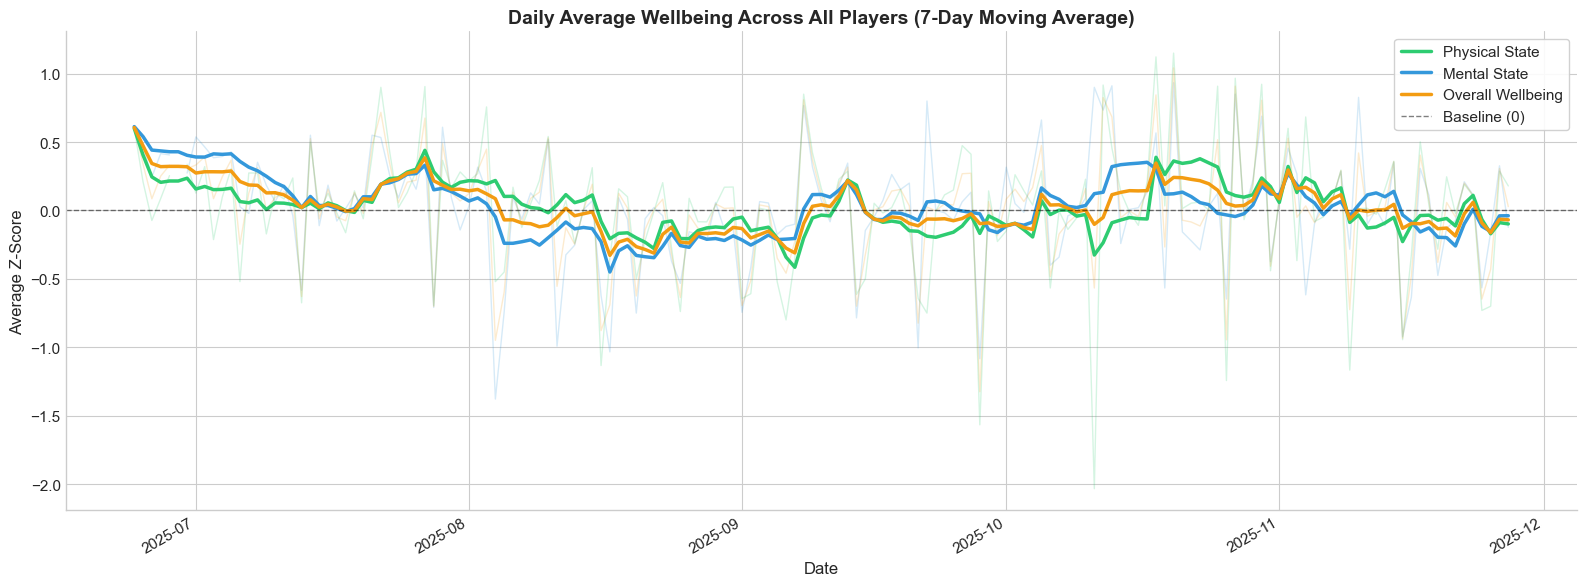

In [6]:
# Temporal Wellbeing Plot - All three metrics
fig, ax = plt.subplots(figsize=(16, 6))

# Plot raw daily values with low alpha
ax.plot(daily_wellbeing['Date'], daily_wellbeing['Physical State'], 
        color=COMPOSITE_COLORS['Physical State'], alpha=0.2, linewidth=1)
ax.plot(daily_wellbeing['Date'], daily_wellbeing['Mental State'], 
        color=COMPOSITE_COLORS['Mental State'], alpha=0.2, linewidth=1)
ax.plot(daily_wellbeing['Date'], daily_wellbeing['Overall Wellbeing'], 
        color=COMPOSITE_COLORS['Overall Wellbeing'], alpha=0.2, linewidth=1)

# Plot 7-day moving averages
ax.plot(daily_wellbeing['Date'], daily_wellbeing['Physical State (7d MA)'], 
        color=COMPOSITE_COLORS['Physical State'], linewidth=2.5, label='Physical State')
ax.plot(daily_wellbeing['Date'], daily_wellbeing['Mental State (7d MA)'], 
        color=COMPOSITE_COLORS['Mental State'], linewidth=2.5, label='Mental State')
ax.plot(daily_wellbeing['Date'], daily_wellbeing['Overall Wellbeing (7d MA)'], 
        color=COMPOSITE_COLORS['Overall Wellbeing'], linewidth=2.5, label='Overall Wellbeing')

# Reference line at 0
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Baseline (0)')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Z-Score', fontsize=12)
ax.set_title('Daily Average Wellbeing Across All Players (7-Day Moving Average)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', frameon=True)

# Format x-axis dates
ax.tick_params(axis='x', rotation=45)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

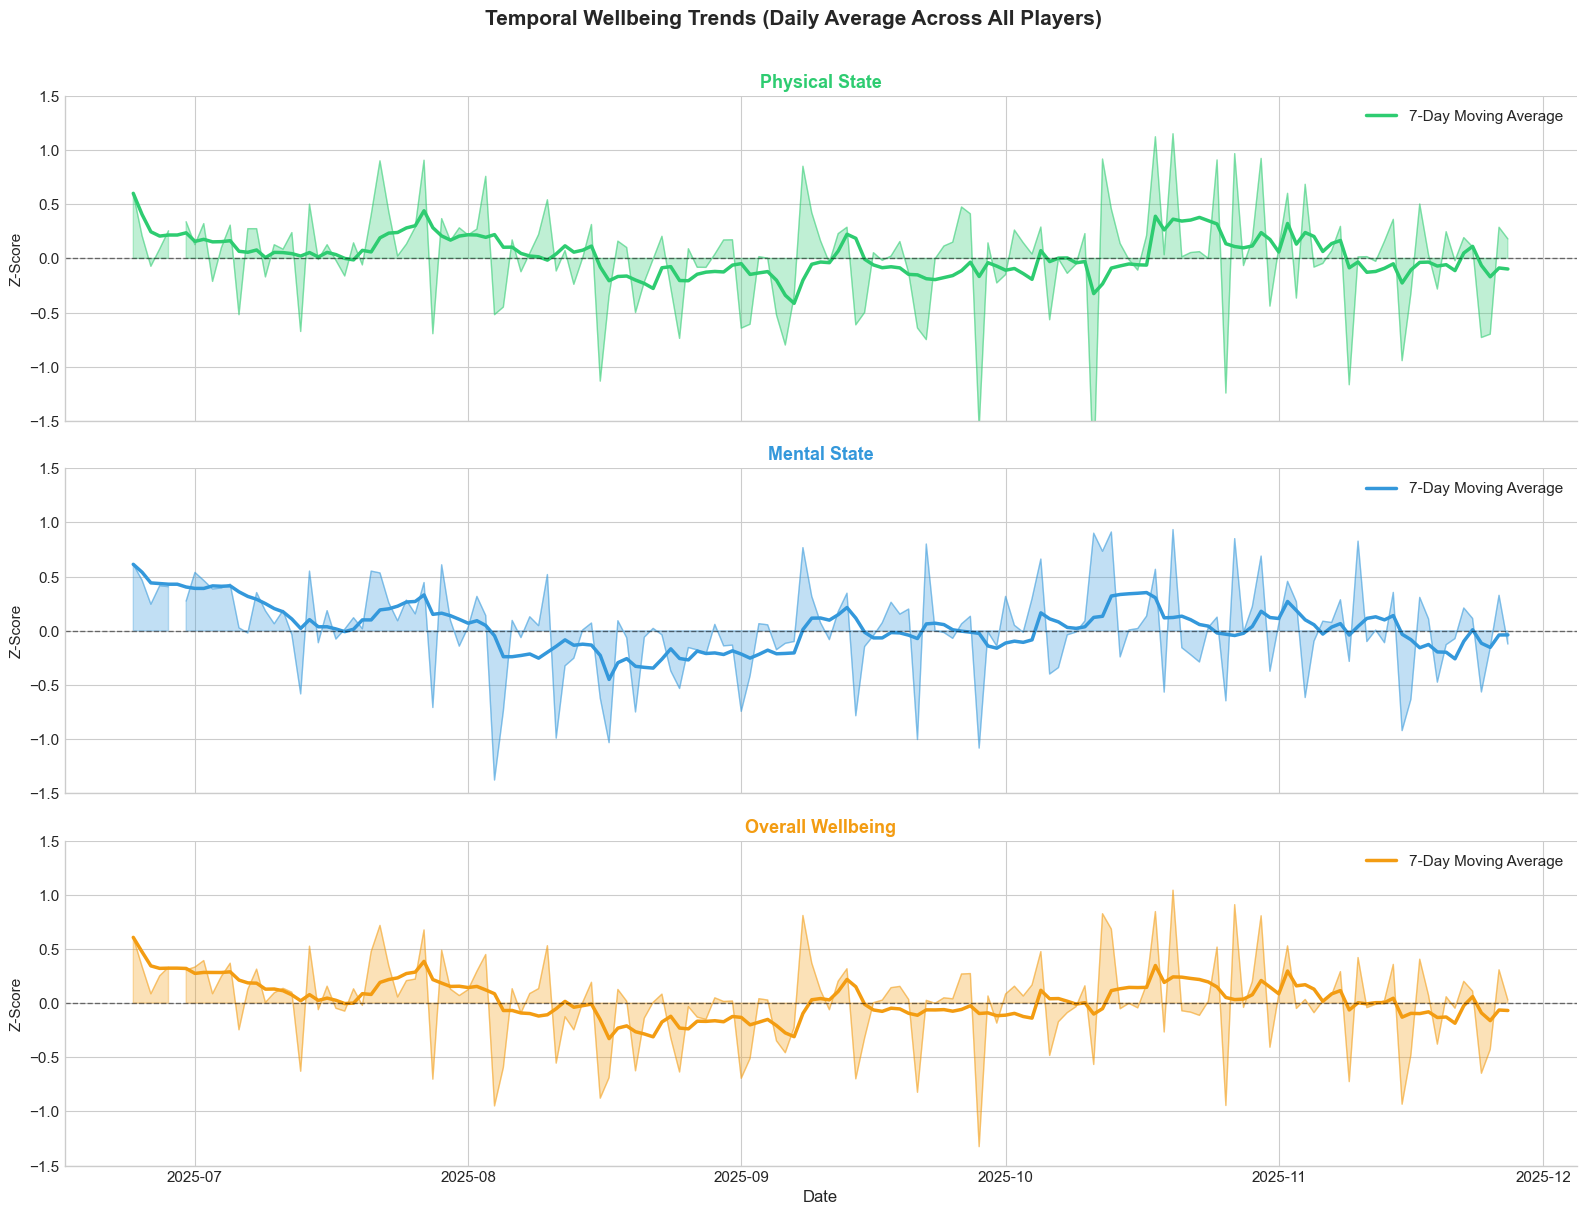

In [7]:
# Individual subplots for each wellbeing metric
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

metrics = [
    ('Physical State', COLORS['success']),
    ('Mental State', COLORS['primary']),
    ('Overall Wellbeing', COLORS['warning'])
]

for ax, (col, color) in zip(axes, metrics):
    # Raw values
    ax.fill_between(daily_wellbeing['Date'], daily_wellbeing[col], 
                    alpha=0.3, color=color)
    ax.plot(daily_wellbeing['Date'], daily_wellbeing[col], 
            color=color, alpha=0.4, linewidth=1)
    
    # 7-day MA
    ax.plot(daily_wellbeing['Date'], daily_wellbeing[f'{col} (7d MA)'], 
            color=color, linewidth=2.5, label='7-Day Moving Average')
    
    # Reference line
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_ylabel('Z-Score', fontsize=11)
    ax.set_title(f'{col}', fontsize=13, fontweight='bold', color=color)
    ax.legend(loc='upper right')
    ax.set_ylim(-1.5, 1.5)

axes[-1].set_xlabel('Date', fontsize=12)
fig.suptitle('Temporal Wellbeing Trends (Daily Average Across All Players)', 
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

In [8]:
# Wellbeing statistics summary
print("Wellbeing Statistics (Daily Averages):")
print("="*50)
for col in wellbeing_cols:
    mean_val = daily_wellbeing[col].mean()
    std_val = daily_wellbeing[col].std()
    min_val = daily_wellbeing[col].min()
    max_val = daily_wellbeing[col].max()
    print(f"\n{col}:")
    print(f"  Mean: {mean_val:+.3f}  |  Std: {std_val:.3f}")
    print(f"  Min:  {min_val:+.3f}  |  Max: {max_val:+.3f}")

Wellbeing Statistics (Daily Averages):

Physical State:
  Mean: +0.017  |  Std: 0.472
  Min:  -2.033  |  Max: +1.150

Mental State:
  Mean: +0.020  |  Std: 0.419
  Min:  -1.378  |  Max: +0.933

Overall Wellbeing:
  Mean: +0.018  |  Std: 0.396
  Min:  -1.325  |  Max: +1.042


---
## 3. Activity Type & Status Distributions

In [9]:
# Get distributions
activity_yesterday = df['Activity Type Yesterday'].value_counts()
status_dist = df['Status'].value_counts()
activity_today = df['Activity Type Today'].value_counts()

print("Activity Type Yesterday:")
for act, count in activity_yesterday.items():
    print(f"  {act:20} {count:5,} ({count/len(df)*100:5.1f}%)")

print(f"\nStatus Distribution:")
for status, count in status_dist.items():
    print(f"  {status:20} {count:5,} ({count/len(df)*100:5.1f}%)")

print(f"\nActivity Type Today:")
for act, count in activity_today.items():
    print(f"  {act:20} {count:5,} ({count/len(df)*100:5.1f}%)")

Activity Type Yesterday:
  Empty                1,627 ( 38.4%)
  Training             1,621 ( 38.2%)
  Game                   376 (  8.9%)
  Rehab                  354 (  8.4%)
  Partial training       108 (  2.5%)
  National team training/game    56 (  1.3%)
  Not selected            37 (  0.9%)
  Youth training or game    24 (  0.6%)
  Individual              17 (  0.4%)
  Private                  8 (  0.2%)
  Sickness                 8 (  0.2%)
  Suspension               2 (  0.0%)
  Medical                  1 (  0.0%)

Status Distribution:
  Available            3,129 ( 73.8%)
  Injured                590 ( 13.9%)
  Attention              498 ( 11.7%)
  Sick                    15 (  0.4%)
  Absent                   7 (  0.2%)

Activity Type Today:
  Empty                1,645 ( 38.8%)
  Training             1,605 ( 37.9%)
  Game                   376 (  8.9%)
  Rehab                  353 (  8.3%)
  Partial training       108 (  2.5%)
  National team training/game    56 (  1.3%)
  N

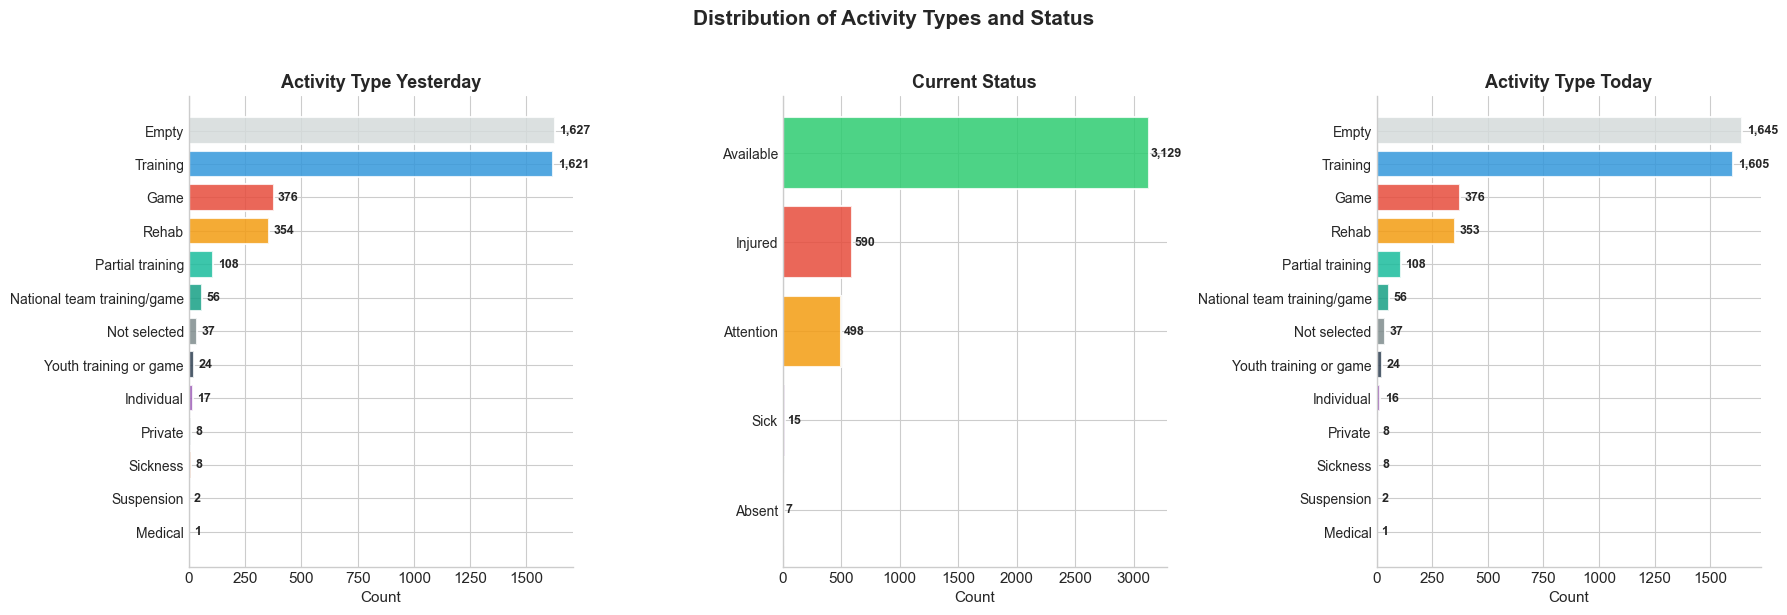

In [10]:
# Visualize all three distributions with horizontal bar charts (no overlapping labels)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Activity Type Yesterday
ax = axes[0]
bars = ax.barh(range(len(activity_yesterday)), activity_yesterday.values, 
               color=[ACTIVITY_COLORS.get(a, '#bdc3c7') for a in activity_yesterday.index], alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(activity_yesterday)))
ax.set_yticklabels(activity_yesterday.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Count', fontsize=11)
ax.set_title('Activity Type Yesterday', fontsize=13, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, activity_yesterday.values)):
    ax.text(val + 20, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

# Status
ax = axes[1]
status_colors_list = [STATUS_COLORS.get(s, '#95a5a6') for s in status_dist.index]
bars = ax.barh(range(len(status_dist)), status_dist.values, 
               color=status_colors_list, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(status_dist)))
ax.set_yticklabels(status_dist.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Count', fontsize=11)
ax.set_title('Current Status', fontsize=13, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, status_dist.values)):
    ax.text(val + 20, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

# Activity Type Today
ax = axes[2]
bars = ax.barh(range(len(activity_today)), activity_today.values, 
               color=[ACTIVITY_COLORS.get(a, '#bdc3c7') for a in activity_today.index], alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(activity_today)))
ax.set_yticklabels(activity_today.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Count', fontsize=11)
ax.set_title('Activity Type Today', fontsize=13, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, activity_today.values)):
    ax.text(val + 20, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Distribution of Activity Types and Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Activity-Status Relationships

In [11]:
# Cross-tabulation: Activity Type Today vs Status
crosstab_today_status = pd.crosstab(
    df['Activity Type Today'], 
    df['Status'],
    margins=True
)
print("Cross-tabulation: Activity Type Today × Status")
print("="*70)
display(crosstab_today_status)

Cross-tabulation: Activity Type Today × Status


Status,Absent,Attention,Available,Injured,Sick,All
Activity Type Today,,,,,,
Empty,1,139,1288,211,6,1645
Game,0,49,325,2,0,376
Individual,0,1,10,5,0,16
Medical,0,0,1,0,0,1
National team training/game,0,0,55,0,1,56
Not selected,0,3,34,0,0,37
Partial training,0,27,68,13,0,108
Private,4,0,3,1,0,8
Rehab,0,11,2,340,0,353


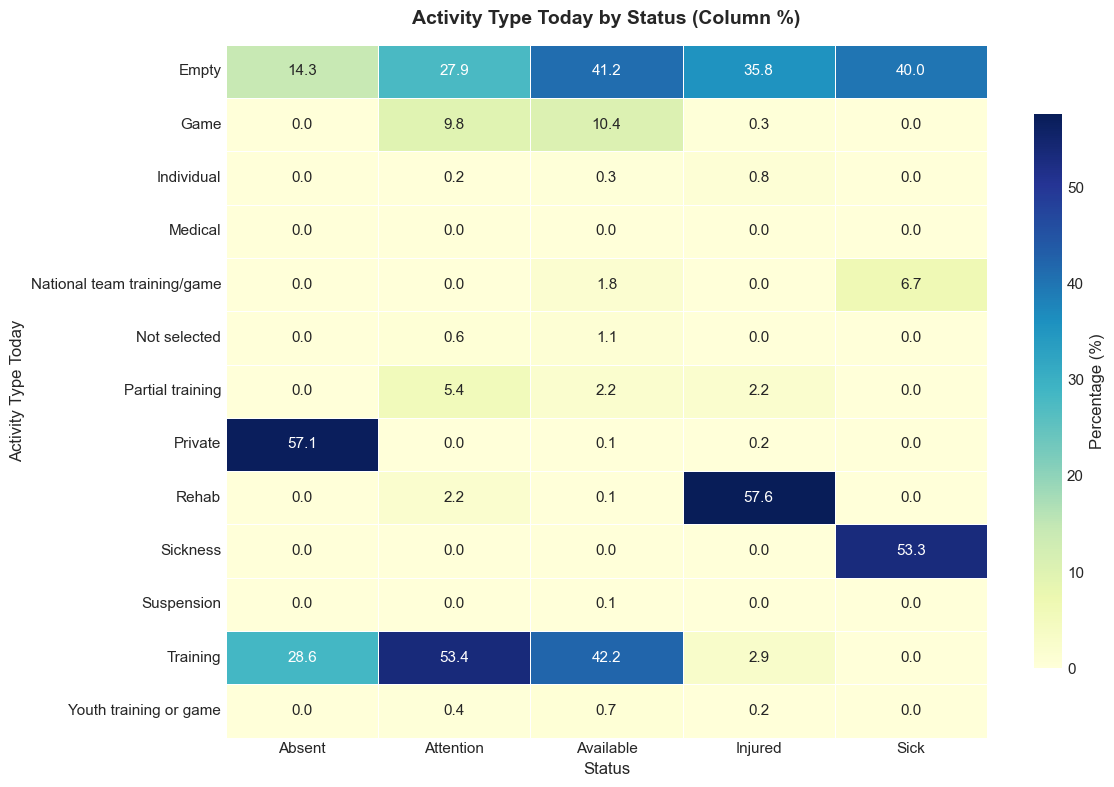

In [12]:
# Heatmap: Activity Type Today by Status (Column %)
activity_today_status_pct = pd.crosstab(
    df['Activity Type Today'], 
    df['Status'],
    normalize='columns'
) * 100

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    activity_today_status_pct, 
    annot=True, 
    fmt='.1f', 
    cmap='YlGnBu',
    cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
    ax=ax,
    linewidths=0.5,
    linecolor='white'
)
ax.set_title('Activity Type Today by Status (Column %)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Status', fontsize=12)
ax.set_ylabel('Activity Type Today', fontsize=12)
plt.tight_layout()
plt.show()

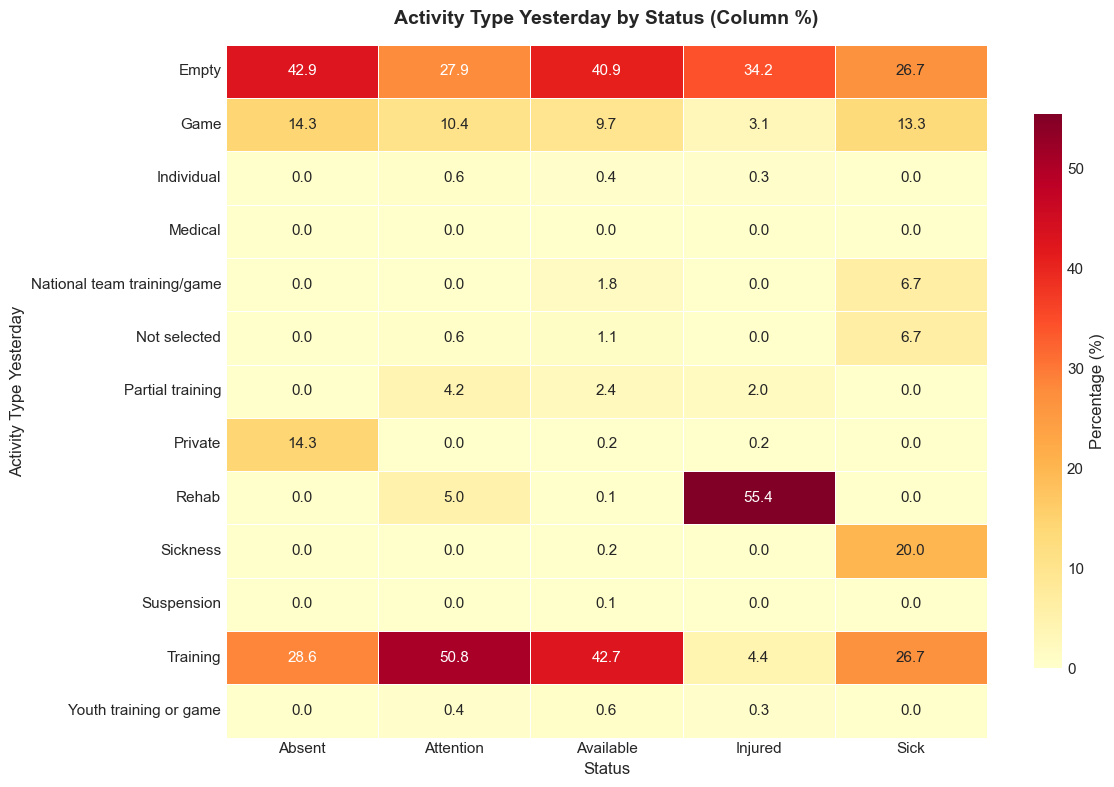

In [13]:
# Heatmap: Activity Type Yesterday by Status (Column %)
activity_yesterday_status_pct = pd.crosstab(
    df['Activity Type Yesterday'], 
    df['Status'],
    normalize='columns'
) * 100

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    activity_yesterday_status_pct, 
    annot=True, 
    fmt='.1f', 
    cmap='YlOrRd',
    cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
    ax=ax,
    linewidths=0.5,
    linecolor='white'
)
ax.set_title('Activity Type Yesterday by Status (Column %)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Status', fontsize=12)
ax.set_ylabel('Activity Type Yesterday', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Status Decrease Analysis

Temporal patterns of when player status worsens (Available→Attention/Injured or Attention→Injured).

In [14]:
# Status Decrease overview
status_decrease_dist = df['Status Decrease'].value_counts()
print("Status Decrease Distribution:")
print(f"  No decrease (0): {status_decrease_dist.get(0, 0):,} ({status_decrease_dist.get(0, 0)/len(df)*100:.2f}%)")
print(f"  Decrease (1):    {status_decrease_dist.get(1, 0):,} ({status_decrease_dist.get(1, 0)/len(df)*100:.2f}%)")

Status Decrease Distribution:
  No decrease (0): 4,133 (97.50%)
  Decrease (1):    106 (2.50%)


In [15]:
# Daily status decrease rate
daily_decrease = df.groupby('Date').agg({
    'Status Decrease': ['sum', 'count']
}).reset_index()
daily_decrease.columns = ['Date', 'Decreases', 'Total']
daily_decrease['Decrease Rate (%)'] = (daily_decrease['Decreases'] / daily_decrease['Total']) * 100
daily_decrease['Decrease Rate 7d MA'] = daily_decrease['Decrease Rate (%)'].rolling(window=7, min_periods=1).mean()

daily_decrease = daily_decrease.sort_values('Date')

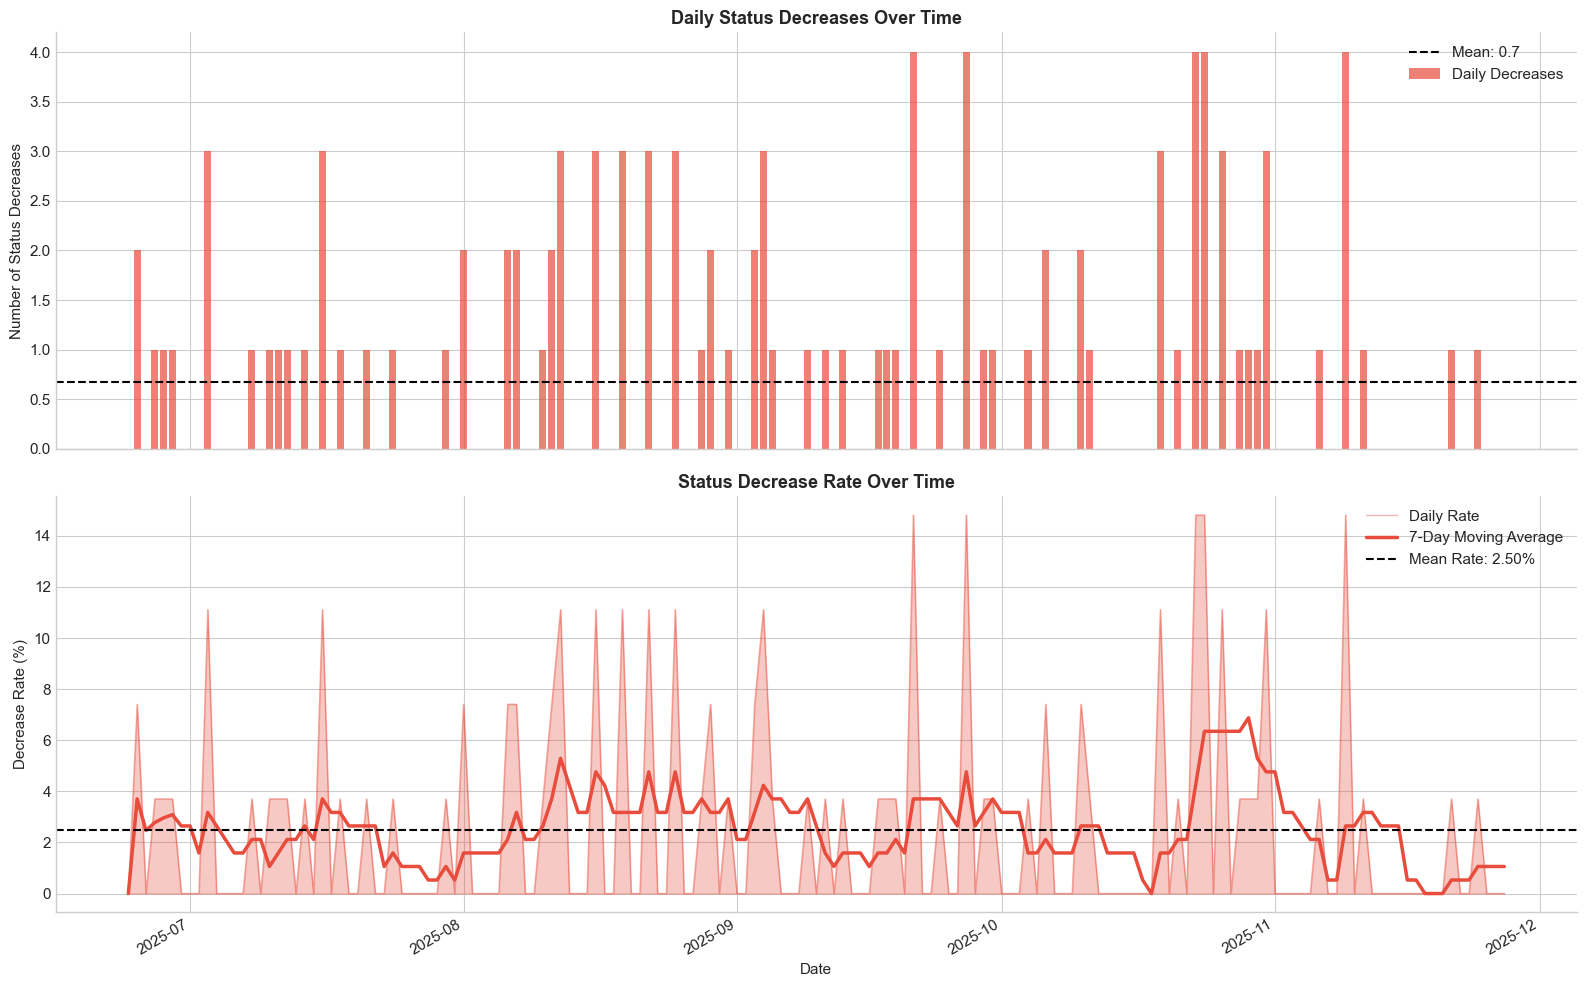

In [16]:
# Temporal pattern of Status Decrease
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot 1: Daily count of status decreases
ax = axes[0]
ax.bar(daily_decrease['Date'], daily_decrease['Decreases'], 
       color=COLORS['secondary'], alpha=0.7, width=0.8, label='Daily Decreases')
ax.set_ylabel('Number of Status Decreases', fontsize=11)
ax.set_title('Daily Status Decreases Over Time', fontsize=13, fontweight='bold')

# Add mean line
mean_decreases = daily_decrease['Decreases'].mean()
ax.axhline(y=mean_decreases, color='black', linestyle='--', linewidth=1.5, 
           label=f'Mean: {mean_decreases:.1f}')
ax.legend(loc='upper right')

# Plot 2: Decrease rate with 7-day MA
ax = axes[1]
ax.fill_between(daily_decrease['Date'], daily_decrease['Decrease Rate (%)'], 
                alpha=0.3, color=COLORS['secondary'])
ax.plot(daily_decrease['Date'], daily_decrease['Decrease Rate (%)'], 
        color=COLORS['secondary'], alpha=0.4, linewidth=1, label='Daily Rate')
ax.plot(daily_decrease['Date'], daily_decrease['Decrease Rate 7d MA'], 
        color=COLORS['secondary'], linewidth=2.5, label='7-Day Moving Average')

mean_rate = daily_decrease['Decrease Rate (%)'].mean()
ax.axhline(y=mean_rate, color='black', linestyle='--', linewidth=1.5, 
           label=f'Mean Rate: {mean_rate:.2f}%')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Decrease Rate (%)', fontsize=11)
ax.set_title('Status Decrease Rate Over Time', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

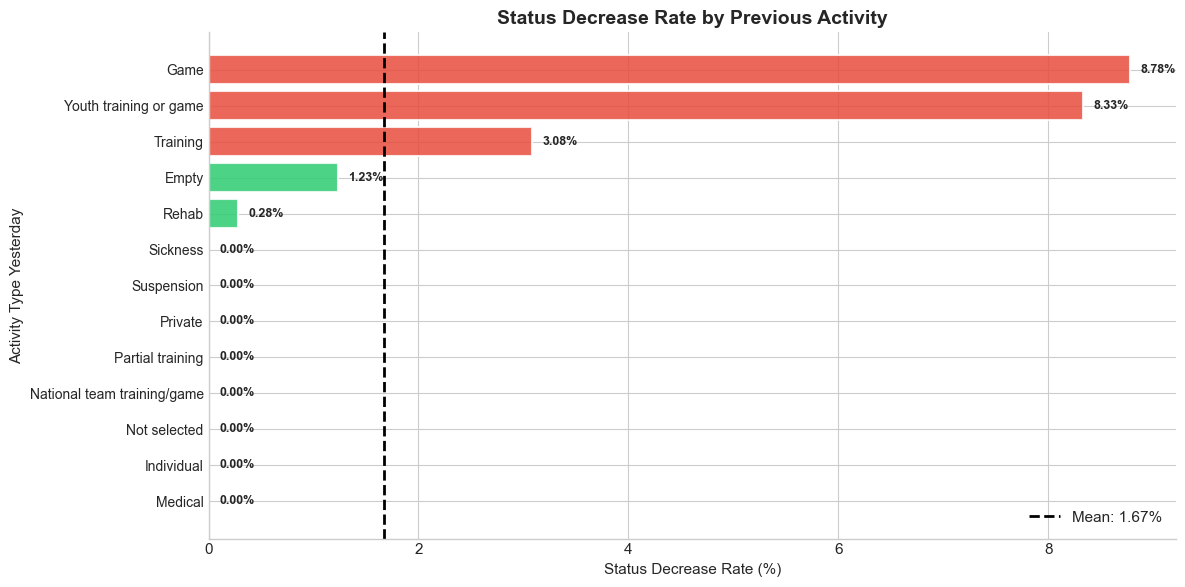

In [17]:
# Status Decrease by Activity Type Yesterday
decrease_by_activity = df.groupby('Activity Type Yesterday')['Status Decrease'].agg(['sum', 'count', 'mean'])
decrease_by_activity['Decrease Rate (%)'] = decrease_by_activity['mean'] * 100
decrease_by_activity = decrease_by_activity.sort_values('Decrease Rate (%)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

colors_list = [COLORS['secondary'] if rate > decrease_by_activity['Decrease Rate (%)'].mean() 
               else COLORS['success'] for rate in decrease_by_activity['Decrease Rate (%)'].values]

bars = ax.barh(range(len(decrease_by_activity)), decrease_by_activity['Decrease Rate (%)'].values, 
               color=colors_list, alpha=0.85, edgecolor='white', linewidth=1.5)

ax.set_yticks(range(len(decrease_by_activity)))
ax.set_yticklabels(decrease_by_activity.index, fontsize=10)

mean_rate = decrease_by_activity['Decrease Rate (%)'].mean()
ax.axvline(x=mean_rate, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_rate:.2f}%')

ax.set_xlabel('Status Decrease Rate (%)', fontsize=11)
ax.set_ylabel('Activity Type Yesterday', fontsize=11)
ax.set_title('Status Decrease Rate by Previous Activity', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, decrease_by_activity['Decrease Rate (%)'].values)):
    ax.text(val + 0.1, i, f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
# Status Decrease by ACWR Danger
decrease_by_danger = df.groupby('Any ACWR Danger')['Status Decrease'].agg(['sum', 'count', 'mean'])
decrease_by_danger['Decrease Rate (%)'] = decrease_by_danger['mean'] * 100

print("Status Decrease Rate by ACWR Danger Zone:")
print("="*50)
for idx, row in decrease_by_danger.iterrows():
    label = 'In Danger Zone' if idx == 1 else 'Not in Danger Zone'
    print(f"  {label:20} {row['Decrease Rate (%)']:.2f}% ({int(row['sum']):,}/{int(row['count']):,})")

Status Decrease Rate by ACWR Danger Zone:
  Not in Danger Zone   2.52% (87/3,447)
  In Danger Zone       2.40% (19/792)


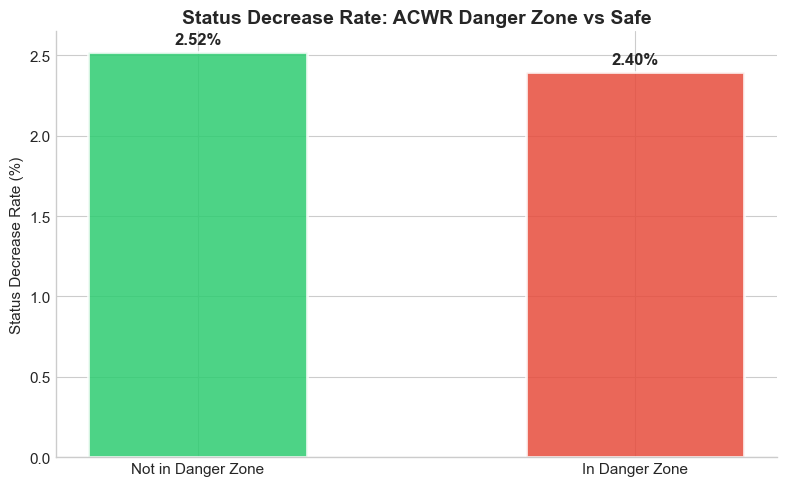

In [19]:
# Visualize Status Decrease by ACWR Danger
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['Not in Danger Zone', 'In Danger Zone']
values = [decrease_by_danger.loc[0, 'Decrease Rate (%)'], decrease_by_danger.loc[1, 'Decrease Rate (%)']]
colors_list = [COLORS['success'], COLORS['secondary']]

bars = ax.bar(labels, values, color=colors_list, alpha=0.85, edgecolor='white', linewidth=2, width=0.5)

ax.set_ylabel('Status Decrease Rate (%)', fontsize=11)
ax.set_title('Status Decrease Rate: ACWR Danger Zone vs Safe', fontsize=14, fontweight='bold')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
            f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. ACWR Danger Zone Analysis

In [20]:
# ACWR Danger distribution
acwr_danger_dist = df['Any ACWR Danger'].value_counts()
print("Any ACWR Danger Distribution:")
print(f"  Not in danger (0): {acwr_danger_dist.get(0, 0):,} ({acwr_danger_dist.get(0, 0)/len(df)*100:.1f}%)")
print(f"  In danger zone (1): {acwr_danger_dist.get(1, 0):,} ({acwr_danger_dist.get(1, 0)/len(df)*100:.1f}%)")

Any ACWR Danger Distribution:
  Not in danger (0): 3,447 (81.3%)
  In danger zone (1): 792 (18.7%)


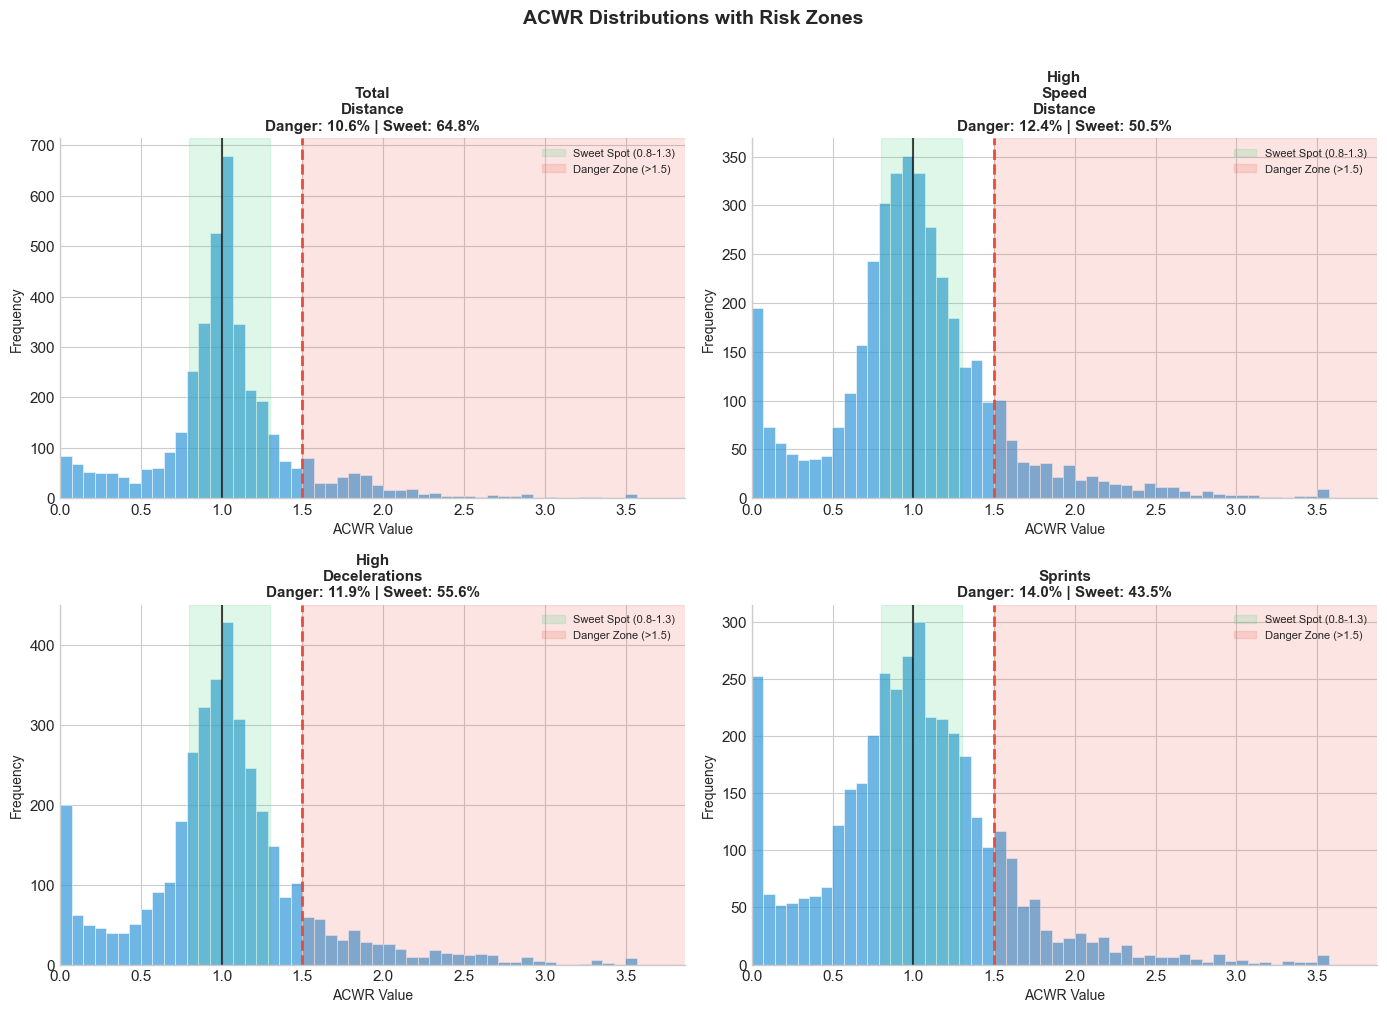

In [21]:
# ACWR values distribution with zones
acwr_cols = [
    'Total Distance (ACWR) Yesterday',
    'High Speed Distance (ACWR) Yesterday',
    'High Decelerations (ACWR) Yesterday',
    'Sprints (ACWR) Yesterday'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, acwr_cols):
    data = df[col].dropna()
    
    # Histogram
    ax.hist(data, bins=50, color=COLORS['primary'], alpha=0.7, edgecolor='white', linewidth=0.5)
    
    # Zone shading
    ymax = ax.get_ylim()[1]
    ax.axvspan(0.8, 1.3, alpha=0.15, color=COLORS['success'], label='Sweet Spot (0.8-1.3)')
    ax.axvspan(1.5, min(data.max() + 0.5, 4), alpha=0.15, color=COLORS['secondary'], label='Danger Zone (>1.5)')
    
    # Reference lines
    ax.axvline(x=1.0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.axvline(x=1.5, color=COLORS['secondary'], linestyle='--', linewidth=2)
    
    # Stats
    danger_pct = (data > 1.5).mean() * 100
    sweet_pct = ((data >= 0.8) & (data <= 1.3)).mean() * 100
    
    short_name = col.replace(' (ACWR) Yesterday', '').replace(' ', '\n')
    ax.set_title(f"{short_name}\nDanger: {danger_pct:.1f}% | Sweet: {sweet_pct:.1f}%", 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('ACWR Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_xlim(0, min(data.max() + 0.3, 4))
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('ACWR Distributions with Risk Zones', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

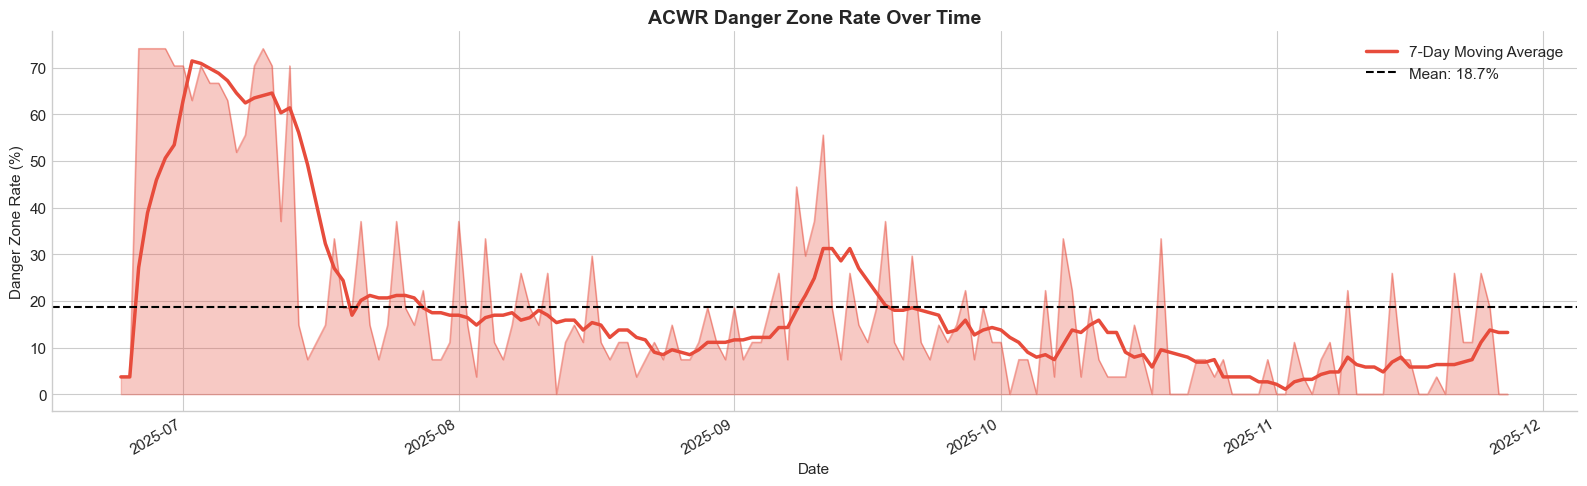

In [22]:
# ACWR Danger over time
daily_danger = df.groupby('Date')['Any ACWR Danger'].agg(['sum', 'count', 'mean']).reset_index()
daily_danger.columns = ['Date', 'Danger Count', 'Total', 'Danger Rate']
daily_danger['Danger Rate (%)'] = daily_danger['Danger Rate'] * 100
daily_danger['Danger Rate 7d MA'] = daily_danger['Danger Rate (%)'].rolling(window=7, min_periods=1).mean()
daily_danger = daily_danger.sort_values('Date')

fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(daily_danger['Date'], daily_danger['Danger Rate (%)'], 
                alpha=0.3, color=COLORS['secondary'])
ax.plot(daily_danger['Date'], daily_danger['Danger Rate (%)'], 
        color=COLORS['secondary'], alpha=0.4, linewidth=1)
ax.plot(daily_danger['Date'], daily_danger['Danger Rate 7d MA'], 
        color=COLORS['secondary'], linewidth=2.5, label='7-Day Moving Average')

mean_rate = daily_danger['Danger Rate (%)'].mean()
ax.axhline(y=mean_rate, color='black', linestyle='--', linewidth=1.5, 
           label=f'Mean: {mean_rate:.1f}%')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Danger Zone Rate (%)', fontsize=11)
ax.set_title('ACWR Danger Zone Rate Over Time', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 7. Comprehensive Correlation Matrix

In [23]:
# Select numeric columns for correlation
numeric_cols = [
    'Medical Availability Last 14 Days',
    'Club Attendance Last 14 Days',
    'Total Distance (ACWR) Yesterday',
    'High Speed Distance (ACWR) Yesterday',
    'High Decelerations (ACWR) Yesterday',
    'Sprints (ACWR) Yesterday',
    'Any ACWR Danger',
    'Total Distance % Yesterday',
    'High Speed Distance % Yesterday',
    'High Decelerations % Yesterday',
    'Sprints % Yesterday',
    'Max Velocity % Yesterday',
    'Perceived Exertion Yesterday',
    'Status Decrease',
    'Fatigue (z)',
    'Readiness (z)',
    'Soreness (z)',
    'Physical State',
    'Sleep Quality (z)',
    'Stress (z)',
    'Mood (z)',
    'Mental State',
    'Overall Wellbeing',
    'Days Since Game'
]

# Filter to existing columns
numeric_cols = [c for c in numeric_cols if c in df.columns]

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

print(f"Correlation matrix: {corr_matrix.shape[0]} variables")

Correlation matrix: 24 variables


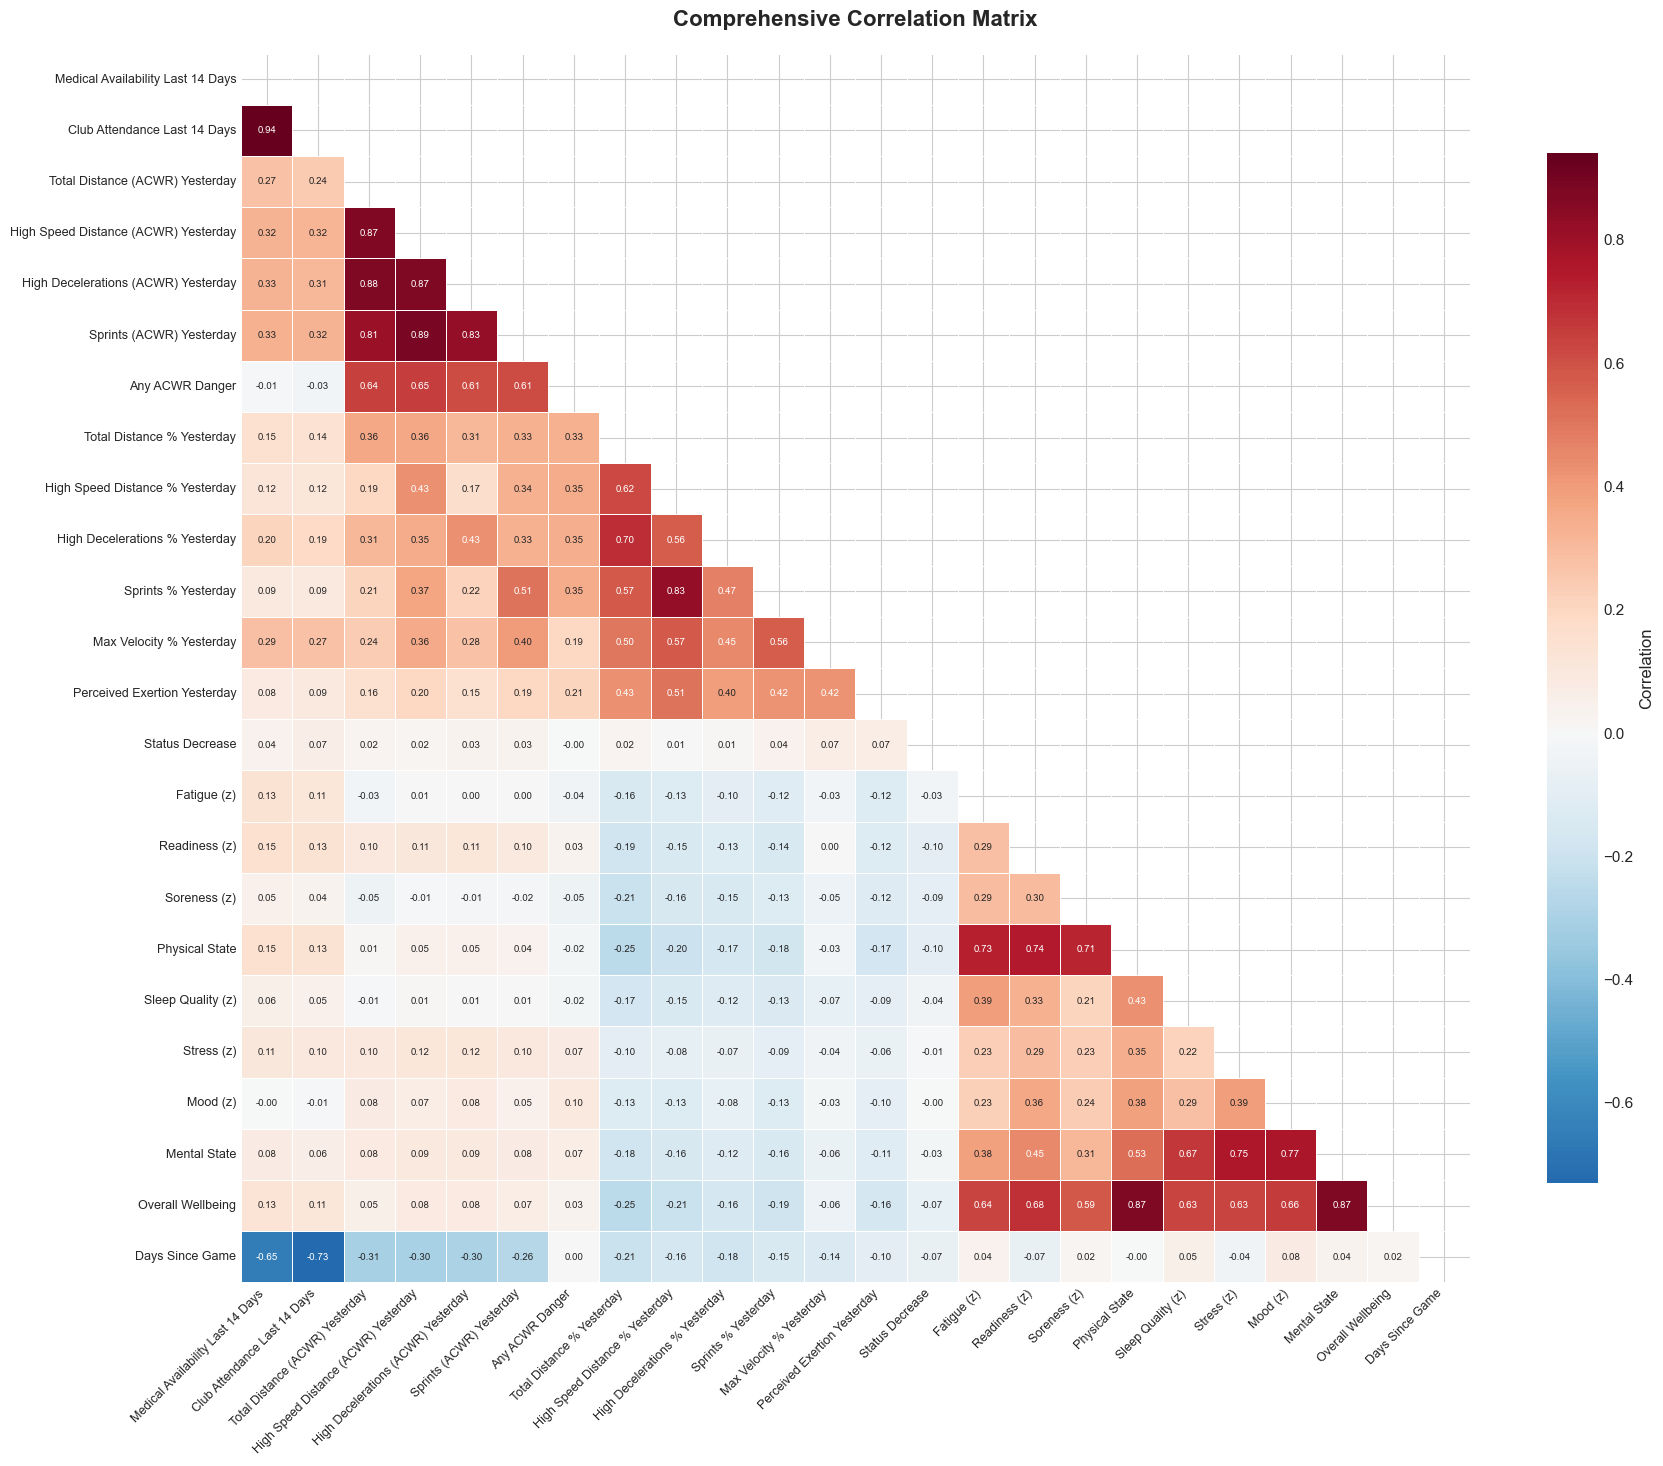

In [24]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(18, 15))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask,
    cmap='RdBu_r', 
    center=0,
    annot=True, 
    fmt='.2f',
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Correlation', 'shrink': 0.8},
    ax=ax,
    annot_kws={'size': 7}
)

ax.set_title('Comprehensive Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
# Top correlations with Status Decrease
if 'Status Decrease' in corr_matrix.columns:
    status_decrease_corr = corr_matrix['Status Decrease'].drop('Status Decrease').sort_values(key=abs, ascending=False)
    
    print("Correlations with Status Decrease:")
    print("="*50)
    for var, corr in status_decrease_corr.head(15).items():
        sign = '+' if corr > 0 else '-'
        print(f"  {var:40} {sign}{abs(corr):.3f}")

Correlations with Status Decrease:
  Readiness (z)                            -0.102
  Physical State                           -0.100
  Soreness (z)                             -0.089
  Overall Wellbeing                        -0.072
  Max Velocity % Yesterday                 +0.068
  Perceived Exertion Yesterday             +0.067
  Days Since Game                          -0.066
  Club Attendance Last 14 Days             +0.065
  Sleep Quality (z)                        -0.043
  Medical Availability Last 14 Days        +0.042
  Sprints % Yesterday                      +0.040
  Sprints (ACWR) Yesterday                 +0.034
  High Decelerations (ACWR) Yesterday      +0.030
  Fatigue (z)                              -0.027
  Mental State                             -0.025


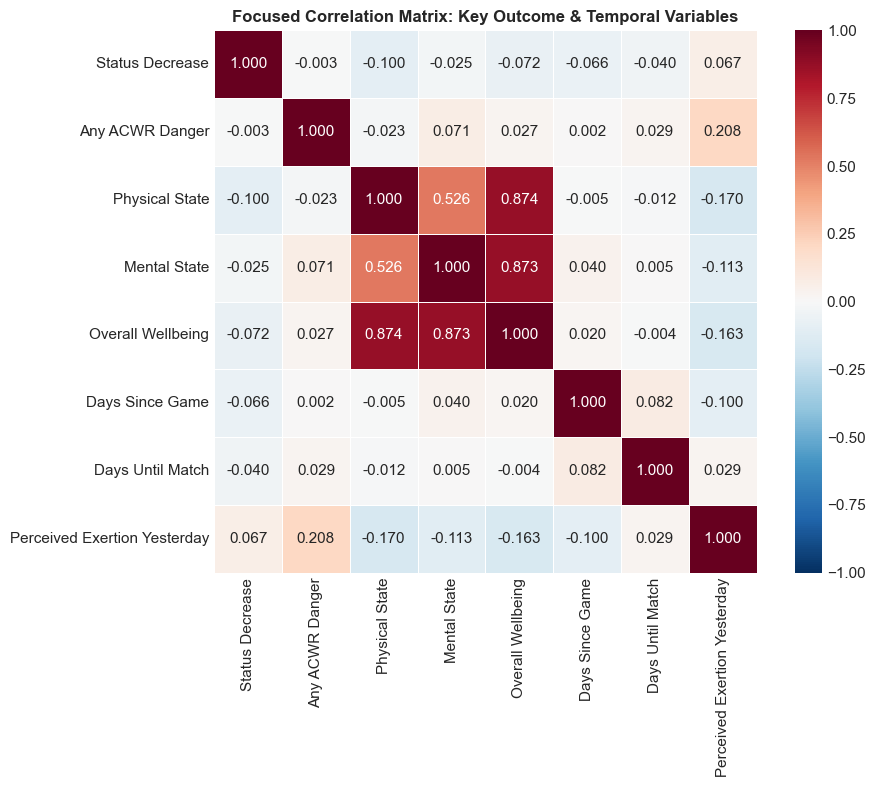

In [26]:
# Focused correlation: Key outcome/treatment variables
key_vars = [
    'Status Decrease',
    'Any ACWR Danger',
    'Physical State',
    'Mental State',
    'Overall Wellbeing',
    'Days Since Game',
    'Days Until Match',
    'Perceived Exertion Yesterday'
]

key_vars = [v for v in key_vars if v in df.columns]
focused_corr = df[key_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    focused_corr,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.3f',
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1
)
ax.set_title('Focused Correlation Matrix: Key Outcome & Temporal Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Summary

In [27]:
# Comprehensive summary
print("="*80)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 DATASET OVERVIEW")
print(f"   Total observations: {len(df):,}")
print(f"   Unique players: {df['Player ID'].nunique()}")
print(f"   Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"   Total features: {len(df.columns)}")

print(f"\n🏥 STATUS DISTRIBUTION")
for status, count in df['Status'].value_counts().items():
    pct = count / len(df) * 100
    print(f"   {status:15} {count:5,} ({pct:5.1f}%)")

print(f"\n📉 STATUS DECREASE")
decrease_count = int(df['Status Decrease'].sum())
decrease_pct = decrease_count / len(df) * 100
print(f"   Total decreases: {decrease_count:,} ({decrease_pct:.2f}%)")

print(f"\n⚠️ ACWR DANGER ZONE")
danger_count = int(df['Any ACWR Danger'].sum())
danger_pct = danger_count / len(df) * 100
print(f"   Observations in danger zone: {danger_count:,} ({danger_pct:.1f}%)")

print(f"\n💪 WELLBEING AVERAGES (Daily Means)")
for col in ['Physical State', 'Mental State', 'Overall Wellbeing']:
    daily_mean = df.groupby('Date')[col].mean().mean()
    daily_std = df.groupby('Date')[col].mean().std()
    print(f"   {col:20} Mean: {daily_mean:+.3f} (SD: {daily_std:.3f})")

print("\n" + "="*80)

EXPLORATORY DATA ANALYSIS SUMMARY

📊 DATASET OVERVIEW
   Total observations: 4,239
   Unique players: 27
   Date range: 2025-06-24 to 2025-11-27
   Total features: 36

🏥 STATUS DISTRIBUTION
   Available       3,129 ( 73.8%)
   Injured           590 ( 13.9%)
   Attention         498 ( 11.7%)
   Sick               15 (  0.4%)
   Absent              7 (  0.2%)

📉 STATUS DECREASE
   Total decreases: 106 (2.50%)

⚠️ ACWR DANGER ZONE
   Observations in danger zone: 792 (18.7%)

💪 WELLBEING AVERAGES (Daily Means)
   Physical State       Mean: +0.017 (SD: 0.472)
   Mental State         Mean: +0.020 (SD: 0.419)
   Overall Wellbeing    Mean: +0.018 (SD: 0.396)



---
## 9. Weekly Pattern Analysis

The training week in professional football typically follows a structured pattern: ~6 training days followed by a match day. Understanding how activity types, workload, and wellbeing vary across the week is critical for the causal modeling of readiness.

In [28]:
# Add day of week (ordered Monday-Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'] = pd.Categorical(df['Date'].dt.day_name(), categories=day_order, ordered=True)

print("Observations per day of the week:")
print(df['DayOfWeek'].value_counts().sort_index())

Observations per day of the week:
DayOfWeek
Monday       594
Tuesday      621
Wednesday    621
Thursday     621
Friday       594
Saturday     594
Sunday       594
Name: count, dtype: int64


### 9.1 Activity Type Distribution by Day of the Week

Which activities dominate on each weekday? This reveals the weekly microcycle structure (e.g., match days, recovery days, heavy training days).

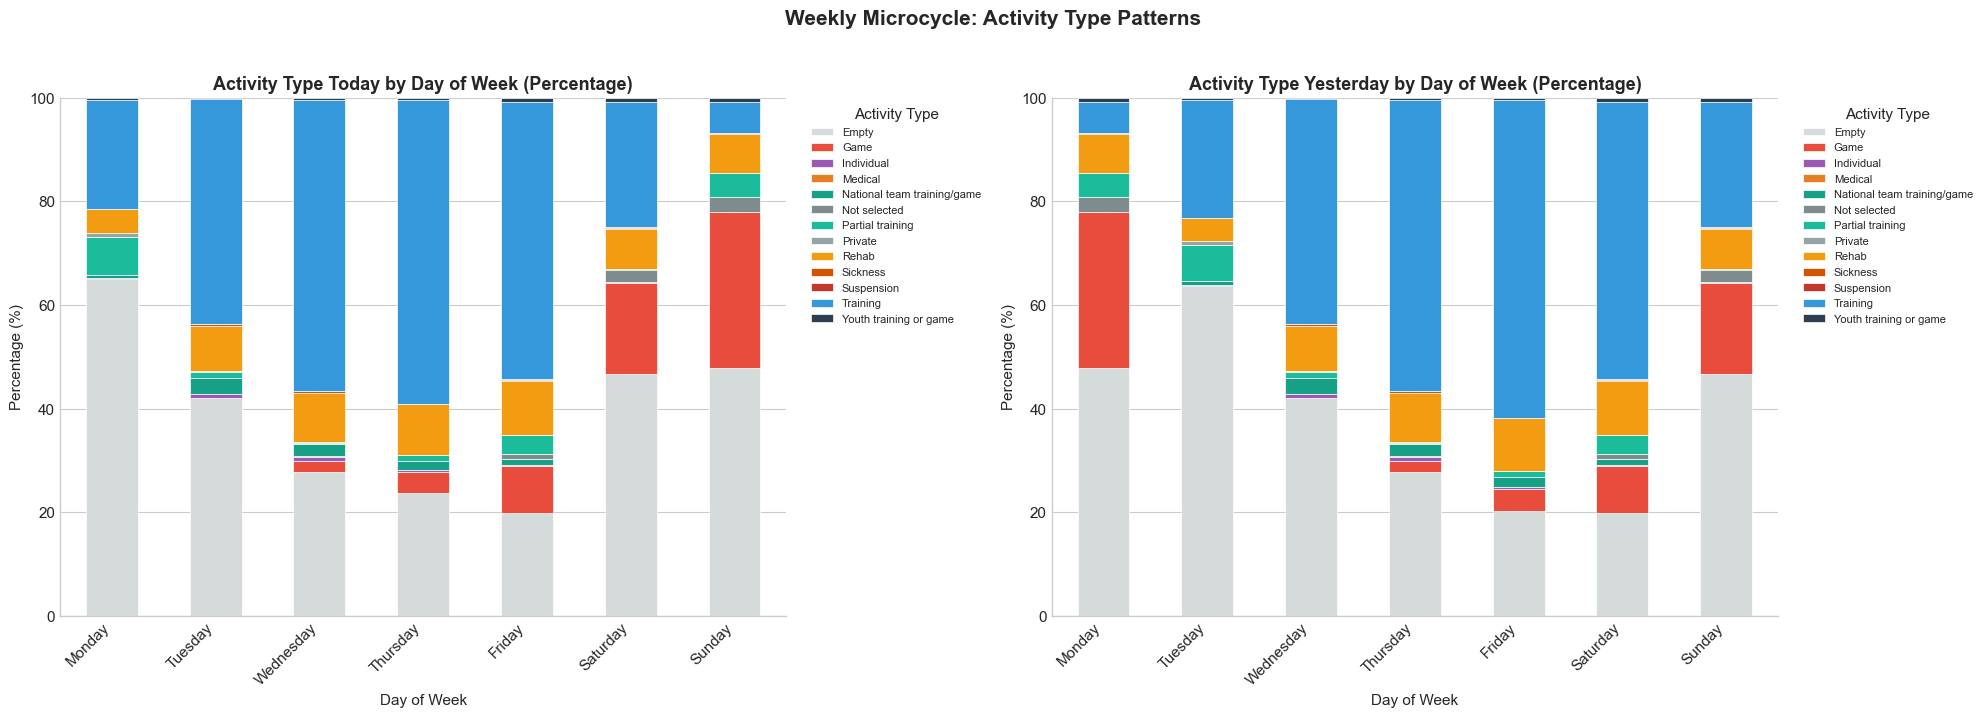

In [29]:
# Activity Type Today by Day of the Week (stacked bar, normalized)
activity_day_ct = pd.crosstab(df['DayOfWeek'], df['Activity Type Today'], normalize='index') * 100

# Define a color map for activities
# Using centralized ACTIVITY_COLORS palette

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Left: Stacked percentage bar
activity_day_ct.plot(kind='bar', stacked=True, ax=axes[0],
                     color=[ACTIVITY_COLORS.get(c, '#bdc3c7') for c in activity_day_ct.columns],
                     edgecolor='white', linewidth=0.5)
axes[0].set_title('Activity Type Today by Day of Week (Percentage)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].set_xlabel('Day of Week', fontsize=11)
axes[0].legend(title='Activity Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].set_xticklabels(day_order, rotation=45, ha='right')
axes[0].set_ylim(0, 100)

# Right: Activity Type Yesterday by Day of Week
activity_yest_day_ct = pd.crosstab(df['DayOfWeek'], df['Activity Type Yesterday'], normalize='index') * 100
activity_yest_day_ct.plot(kind='bar', stacked=True, ax=axes[1],
                          color=[ACTIVITY_COLORS.get(c, '#bdc3c7') for c in activity_yest_day_ct.columns],
                          edgecolor='white', linewidth=0.5)
axes[1].set_title('Activity Type Yesterday by Day of Week (Percentage)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].legend(title='Activity Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].set_xticklabels(day_order, rotation=45, ha='right')
axes[1].set_ylim(0, 100)

plt.suptitle('Weekly Microcycle: Activity Type Patterns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.2 GPS Workload Metrics by Day of the Week

How does external training load (Total Distance %, High Speed Distance %, etc.) vary across weekdays? This shows the weekly load periodization pattern.

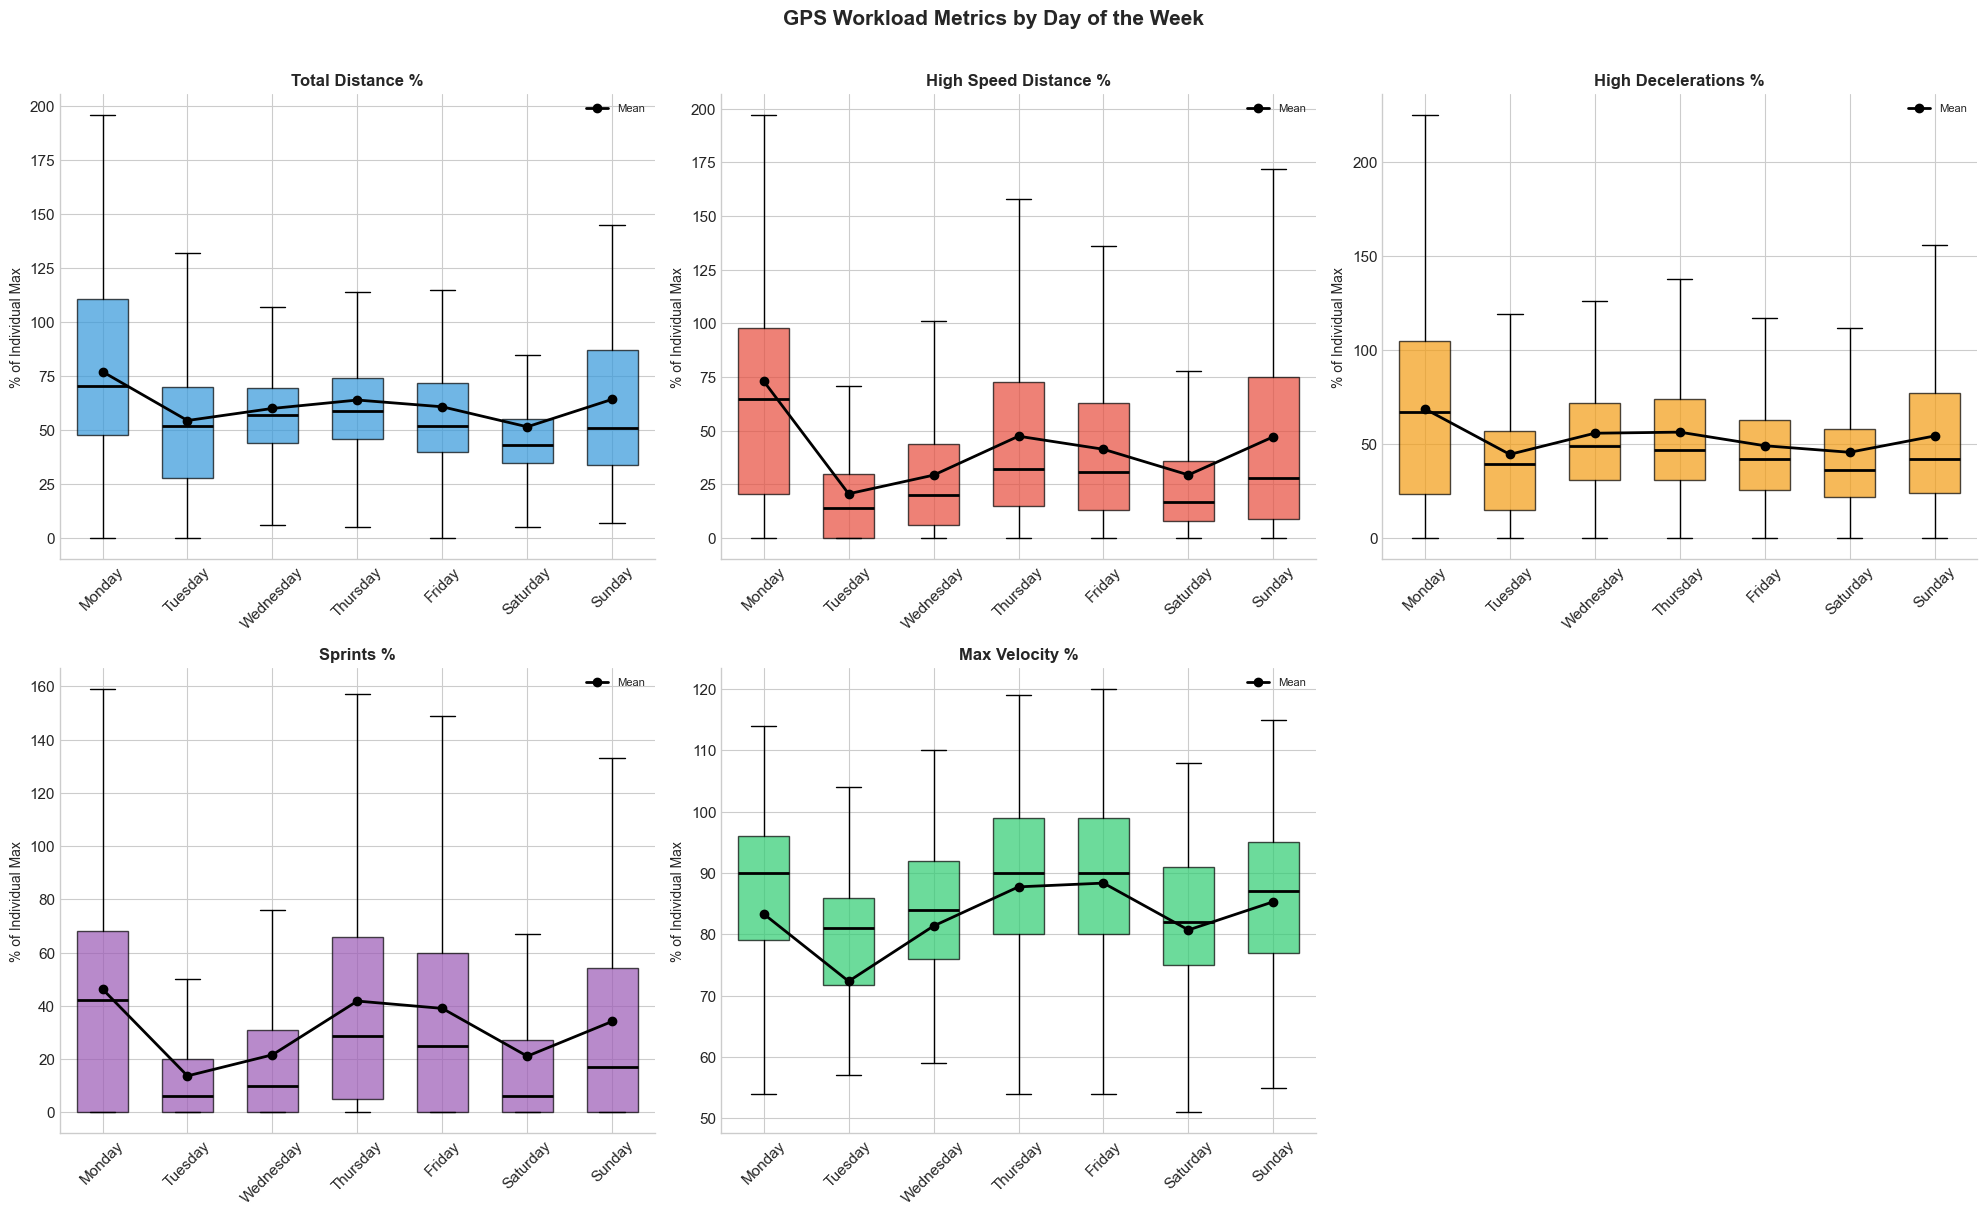

In [30]:
# GPS load metrics by day of week
gps_cols = [
    'Total Distance % Yesterday', 
    'High Speed Distance % Yesterday',
    'High Decelerations % Yesterday', 
    'Sprints % Yesterday',
    'Max Velocity % Yesterday'
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

gps_colors = list(GPS_COLORS.values())

for i, (col, color) in enumerate(zip(gps_cols, gps_colors)):
    ax = axes[i]
    
    # Box plot by day of week
    day_data = [df[df['DayOfWeek'] == day][col].dropna() for day in day_order]
    bp = ax.boxplot(day_data, labels=day_order, patch_artist=True, 
                    widths=0.6, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Overlay mean line
    means = [d.mean() if len(d) > 0 else np.nan for d in day_data]
    ax.plot(range(1, 8), means, 'ko-', markersize=6, linewidth=2, label='Mean')
    
    short_name = col.replace(' % Yesterday', '').replace(' Yesterday', '')
    ax.set_title(f'{short_name} %', fontsize=12, fontweight='bold')
    ax.set_ylabel('% of Individual Max', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

# Remove unused subplot
axes[5].set_visible(False)

plt.suptitle('GPS Workload Metrics by Day of the Week', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

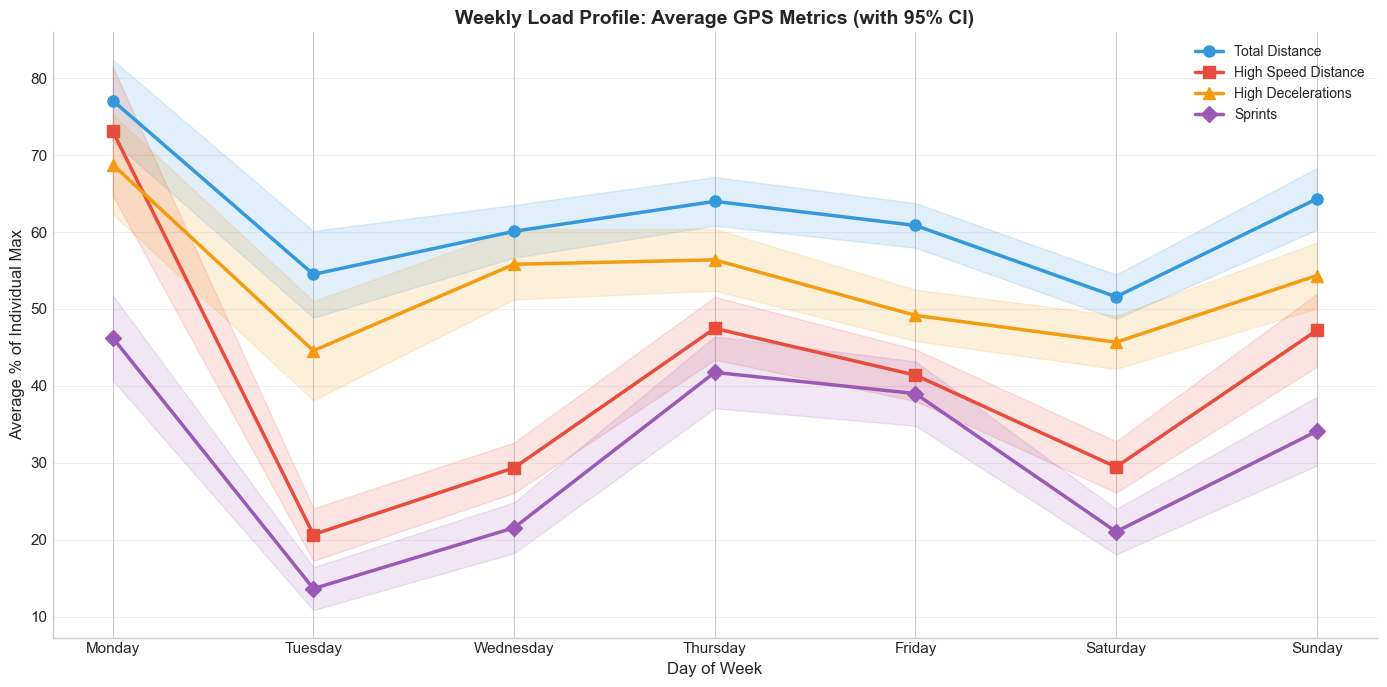

In [31]:
# Average GPS workload profile across the week (line chart with CI)
fig, ax = plt.subplots(figsize=(14, 7))

for col, color, marker in zip(
    ['Total Distance % Yesterday', 'High Speed Distance % Yesterday', 
     'High Decelerations % Yesterday', 'Sprints % Yesterday'],
    [GPS_COLORS[c] for c in ['Total Distance % Yesterday', 'High Speed Distance % Yesterday', 'High Decelerations % Yesterday', 'Sprints % Yesterday']],
    ['o', 's', '^', 'D']
):
    grouped = df.groupby('DayOfWeek')[col]
    means = grouped.mean()
    sems = grouped.sem()
    
    short_name = col.replace(' % Yesterday', '')
    ax.plot(range(7), means.values, color=color, marker=marker, markersize=8, 
            linewidth=2.5, label=short_name, zorder=3)
    ax.fill_between(range(7), 
                    (means - 1.96 * sems).values, 
                    (means + 1.96 * sems).values,
                    color=color, alpha=0.15)

ax.set_xticks(range(7))
ax.set_xticklabels(day_order, fontsize=11)
ax.set_ylabel('Average % of Individual Max', fontsize=12)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_title('Weekly Load Profile: Average GPS Metrics (with 95% CI)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 ACWR by Day of the Week

How does the Acute:Chronic Workload Ratio vary across the week? Higher ACWR values indicate workload spikes relative to the player's chronic baseline.

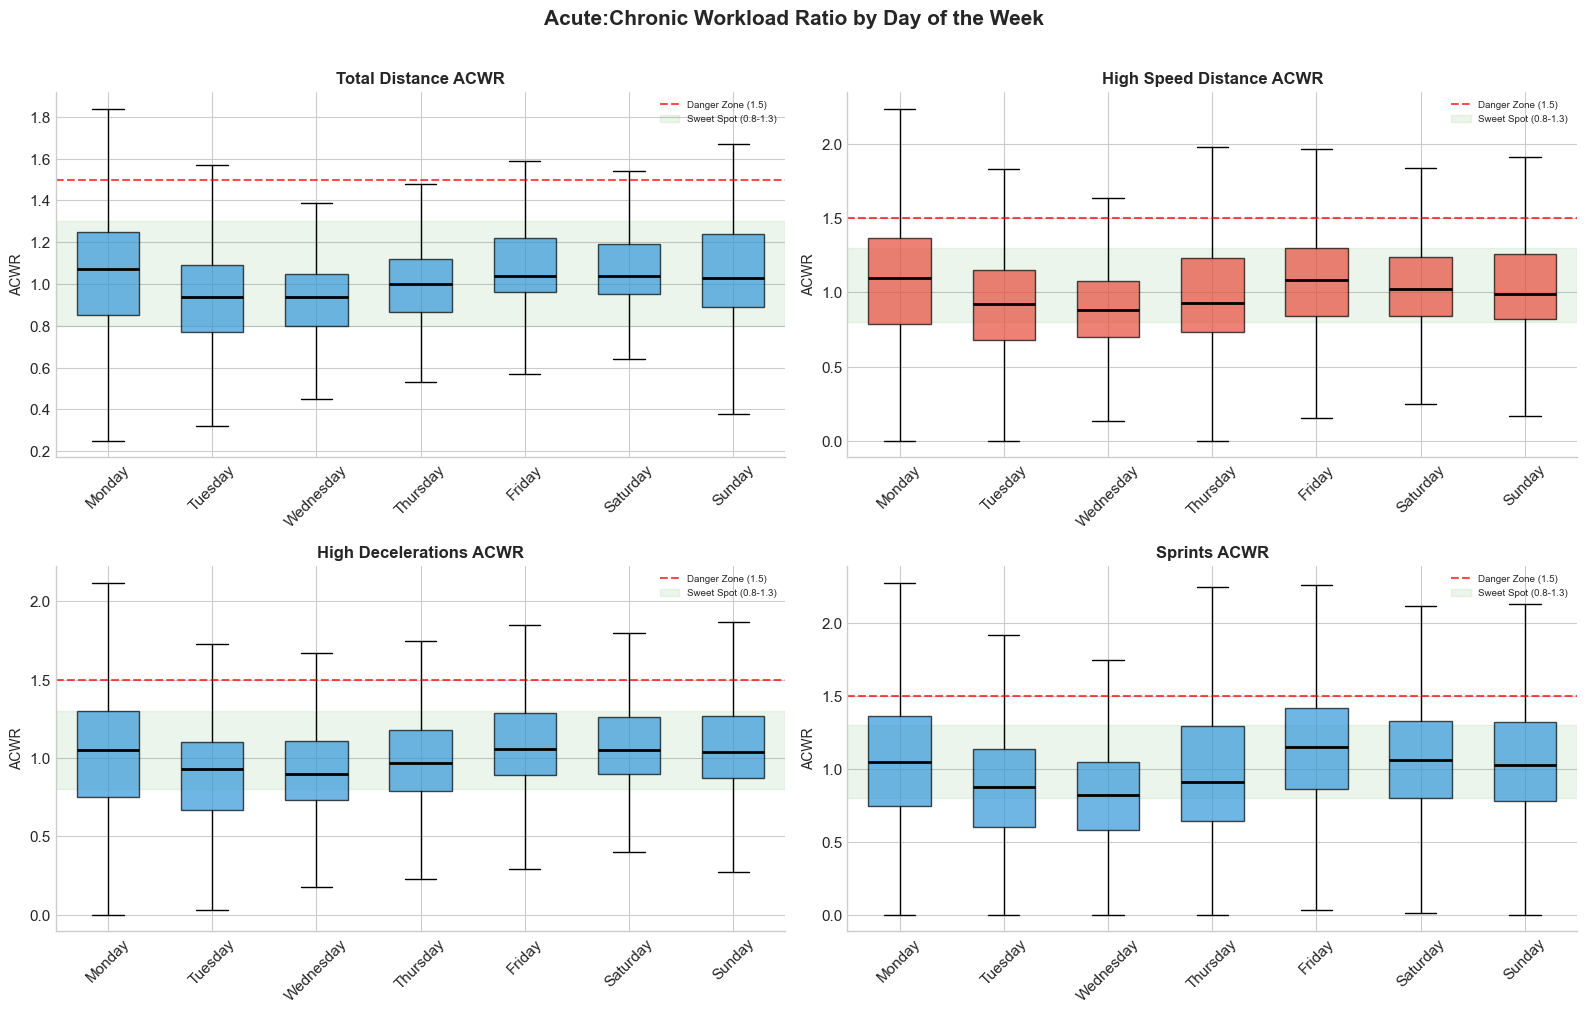

In [32]:
# ACWR metrics by day of week
acwr_cols = [
    'Total Distance (ACWR) Yesterday',
    'High Speed Distance (ACWR) Yesterday',
    'High Decelerations (ACWR) Yesterday',
    'Sprints (ACWR) Yesterday'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

acwr_colors = [ACWR_COLORS.get(c, COLORS["primary"]) for c in acwr_cols]

for ax, col, color in zip(axes, acwr_cols, acwr_colors):
    day_data = [df[df['DayOfWeek'] == day][col].dropna() for day in day_order]
    
    bp = ax.boxplot(day_data, labels=day_order, patch_artist=True,
                    widths=0.6, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Sweet spot and danger zone reference lines
    ax.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Danger Zone (1.5)')
    ax.axhspan(0.8, 1.3, alpha=0.08, color='green', label='Sweet Spot (0.8-1.3)')
    
    short_name = col.replace(' (ACWR) Yesterday', '')
    ax.set_title(f'{short_name} ACWR', fontsize=12, fontweight='bold')
    ax.set_ylabel('ACWR', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Acute:Chronic Workload Ratio by Day of the Week', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 9.4 Wellbeing Metrics by Day of the Week

How do subjective wellbeing scores (Fatigue, Soreness, Sleep Quality, etc.) fluctuate across the week? This captures the recovery-fatigue cycle.

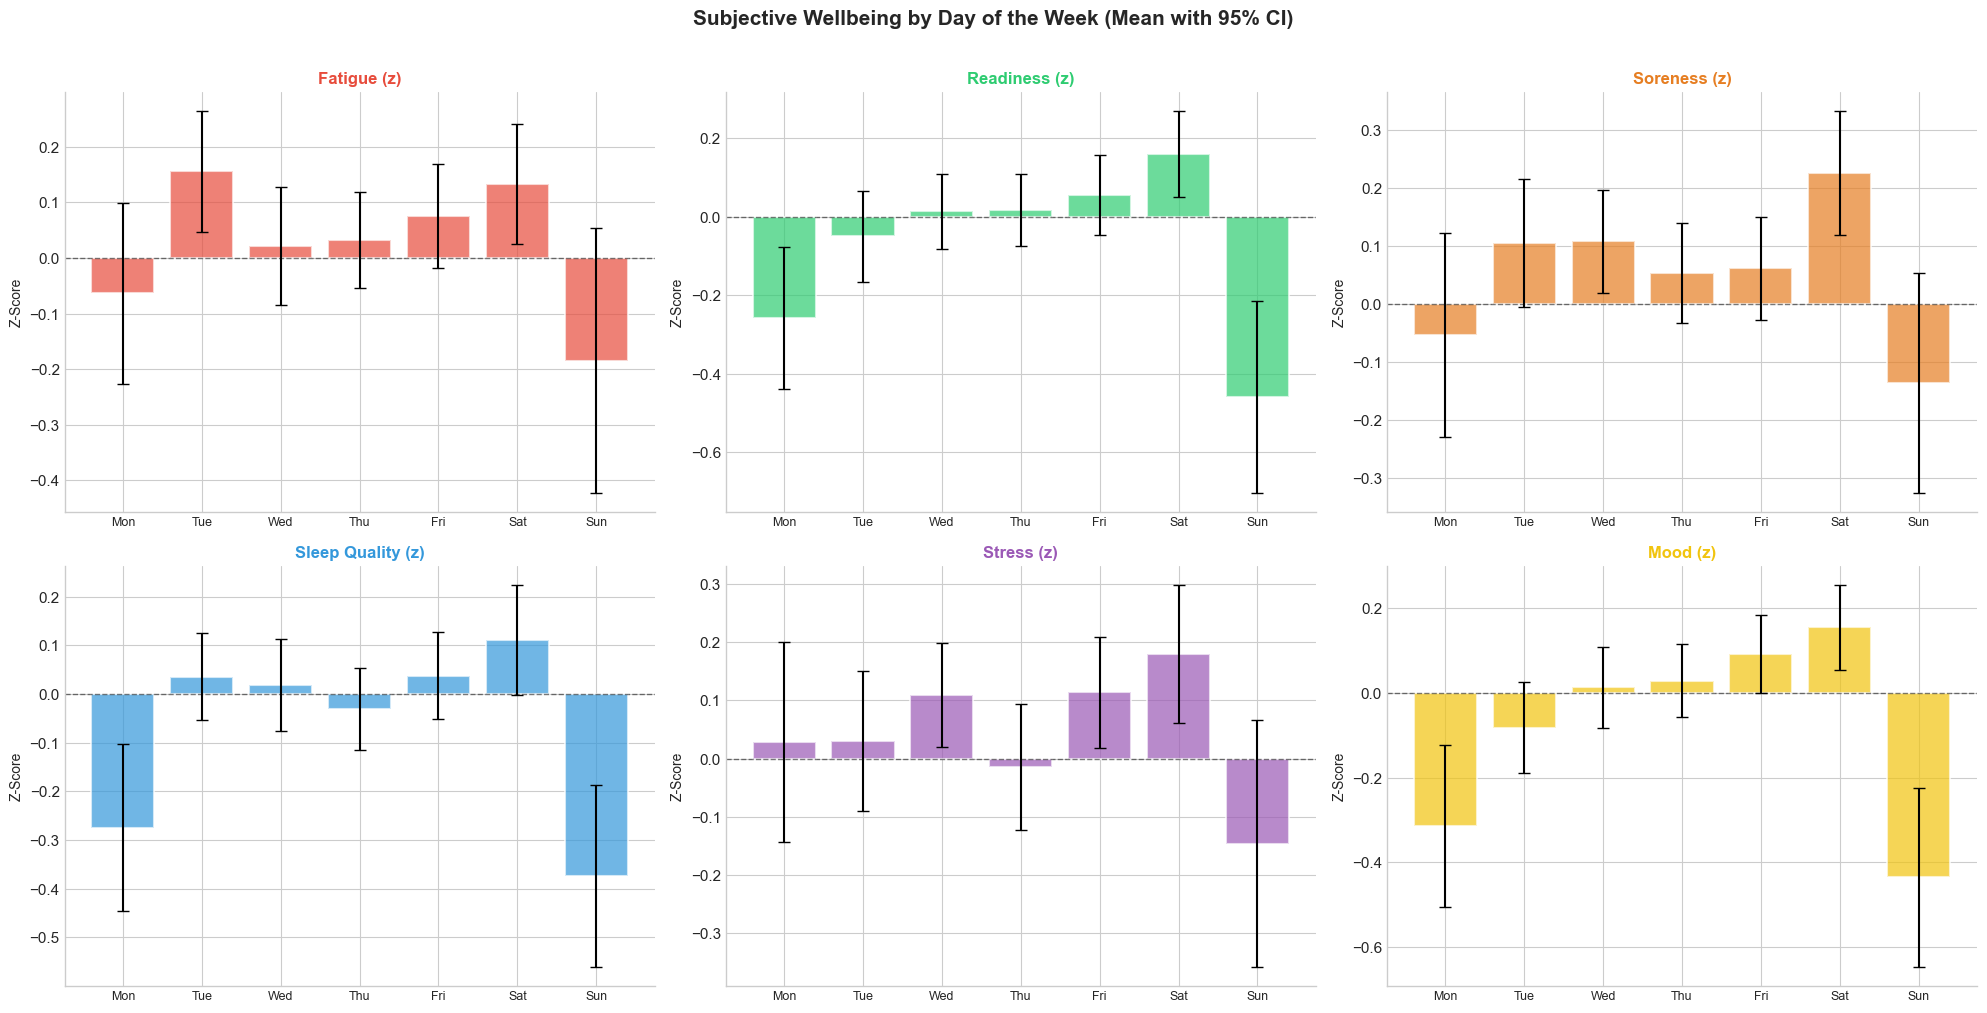

In [33]:
# Subjective wellbeing z-scores by day of week
wellbeing_z_cols = ['Fatigue (z)', 'Readiness (z)', 'Soreness (z)', 'Sleep Quality (z)', 'Stress (z)', 'Mood (z)']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

wb_colors = [WELLBEING_COLORS[c] for c in wellbeing_z_cols]

for ax, col, color in zip(axes, wellbeing_z_cols, wb_colors):
    grouped = df.groupby('DayOfWeek')[col]
    means = grouped.mean()
    sems = grouped.sem()
    
    ax.bar(range(7), means.values, color=color, alpha=0.7, edgecolor='white', linewidth=1.5)
    ax.errorbar(range(7), means.values, yerr=1.96 * sems.values, 
                fmt='none', color='black', capsize=4, linewidth=1.5)
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xticks(range(7))
    ax.set_xticklabels([d[:3] for d in day_order], fontsize=9)
    ax.set_ylabel('Z-Score', fontsize=10)
    ax.set_title(col, fontsize=12, fontweight='bold', color=color)

plt.suptitle('Subjective Wellbeing by Day of the Week (Mean with 95% CI)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

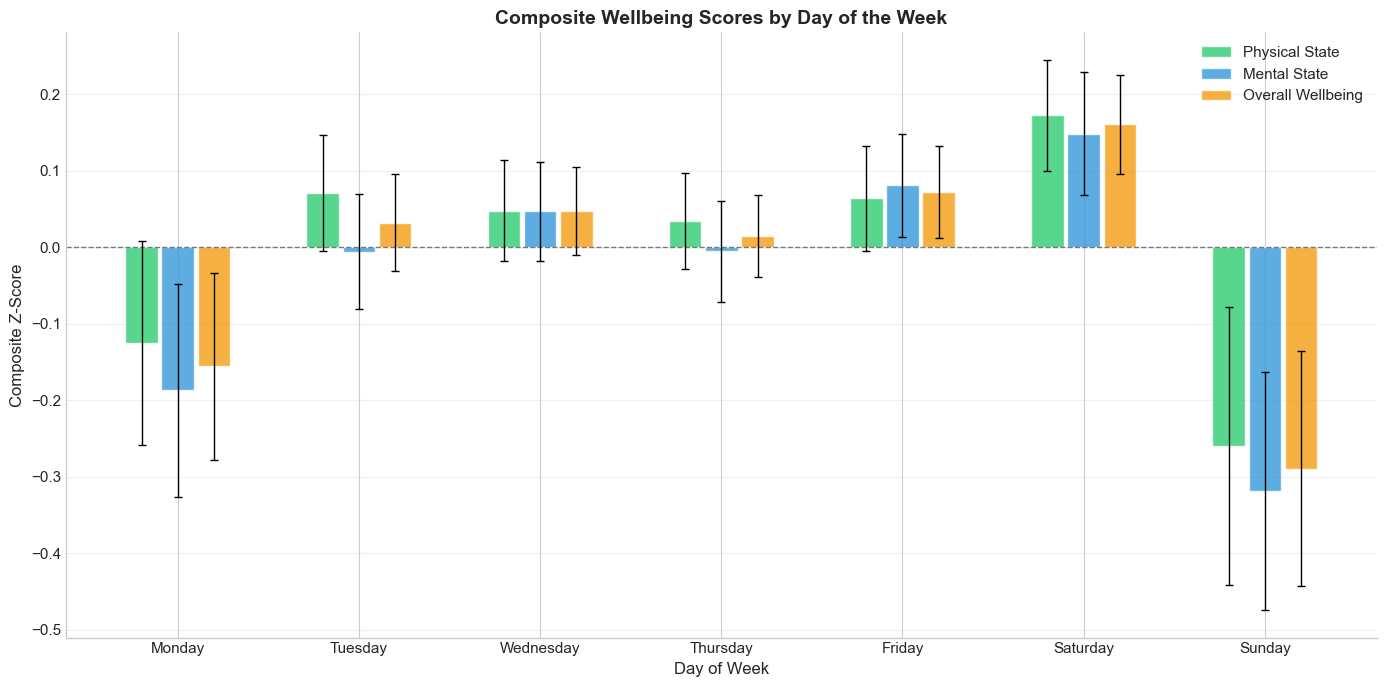

In [34]:
# Composite wellbeing scores by day of week (Physical, Mental, Overall)
fig, ax = plt.subplots(figsize=(14, 7))

composite_cols = ['Physical State', 'Mental State', 'Overall Wellbeing']
composite_colors = [COMPOSITE_COLORS[c] for c in composite_cols]
offsets = [-0.2, 0.0, 0.2]

for col, color, offset in zip(composite_cols, composite_colors, offsets):
    grouped = df.groupby('DayOfWeek')[col]
    means = grouped.mean()
    sems = grouped.sem()
    
    positions = np.arange(7) + offset
    ax.bar(positions, means.values, width=0.18, color=color, alpha=0.8, 
           edgecolor='white', linewidth=1, label=col)
    ax.errorbar(positions, means.values, yerr=1.96 * sems.values,
                fmt='none', color='black', capsize=3, linewidth=1)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticks(range(7))
ax.set_xticklabels(day_order, fontsize=11)
ax.set_ylabel('Composite Z-Score', fontsize=12)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_title('Composite Wellbeing Scores by Day of the Week', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

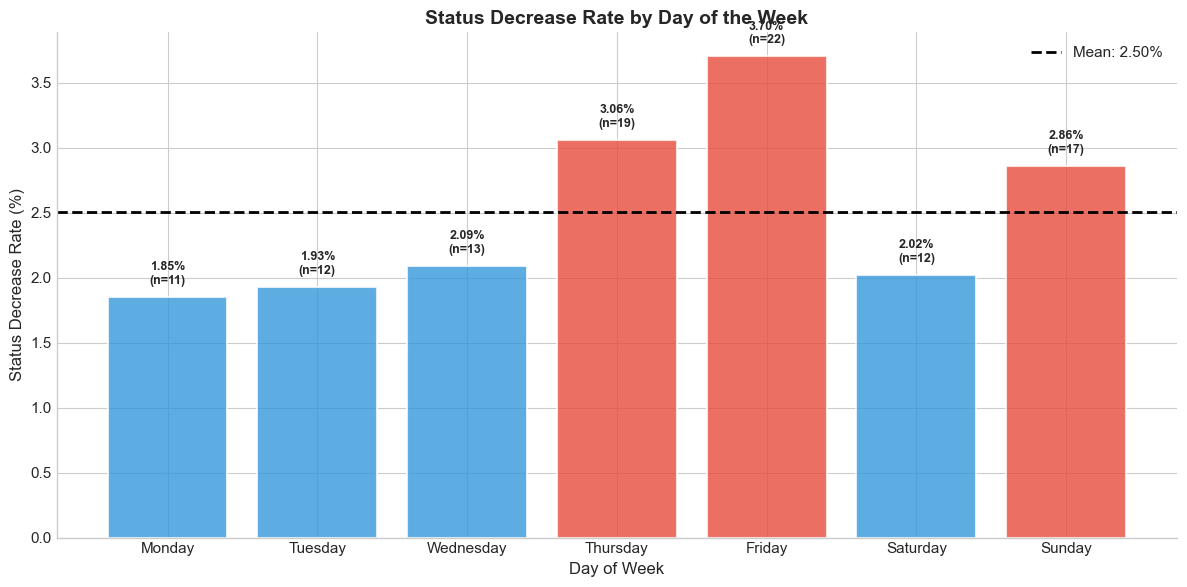

In [35]:
# Status Decrease rate by day of week
fig, ax = plt.subplots(figsize=(12, 6))

decrease_by_day = df.groupby('DayOfWeek')['Status Decrease'].agg(['sum', 'count', 'mean'])
decrease_by_day['rate'] = decrease_by_day['mean'] * 100

bars = ax.bar(range(7), decrease_by_day['rate'].values, 
              color=[COLORS['secondary'] if r > decrease_by_day['rate'].mean() else COLORS['primary'] 
                     for r in decrease_by_day['rate'].values],
              alpha=0.8, edgecolor='white', linewidth=1.5)

ax.axhline(y=decrease_by_day['rate'].mean(), color='black', linestyle='--', linewidth=2, 
           label=f"Mean: {decrease_by_day['rate'].mean():.2f}%")

for i, (bar, val, n) in enumerate(zip(bars, decrease_by_day['rate'].values, decrease_by_day['sum'].values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f'{val:.2f}%\n(n={int(n)})', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(7))
ax.set_xticklabels(day_order, fontsize=11)
ax.set_ylabel('Status Decrease Rate (%)', fontsize=12)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_title('Status Decrease Rate by Day of the Week', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## 10. Training Load & Treatment Analysis

In the causal framework, **Activity Type** serves as the treatment variable. Understanding how workload differs by activity type is essential for defining treatment intensities (Recovery, Low, Moderate, Hard).

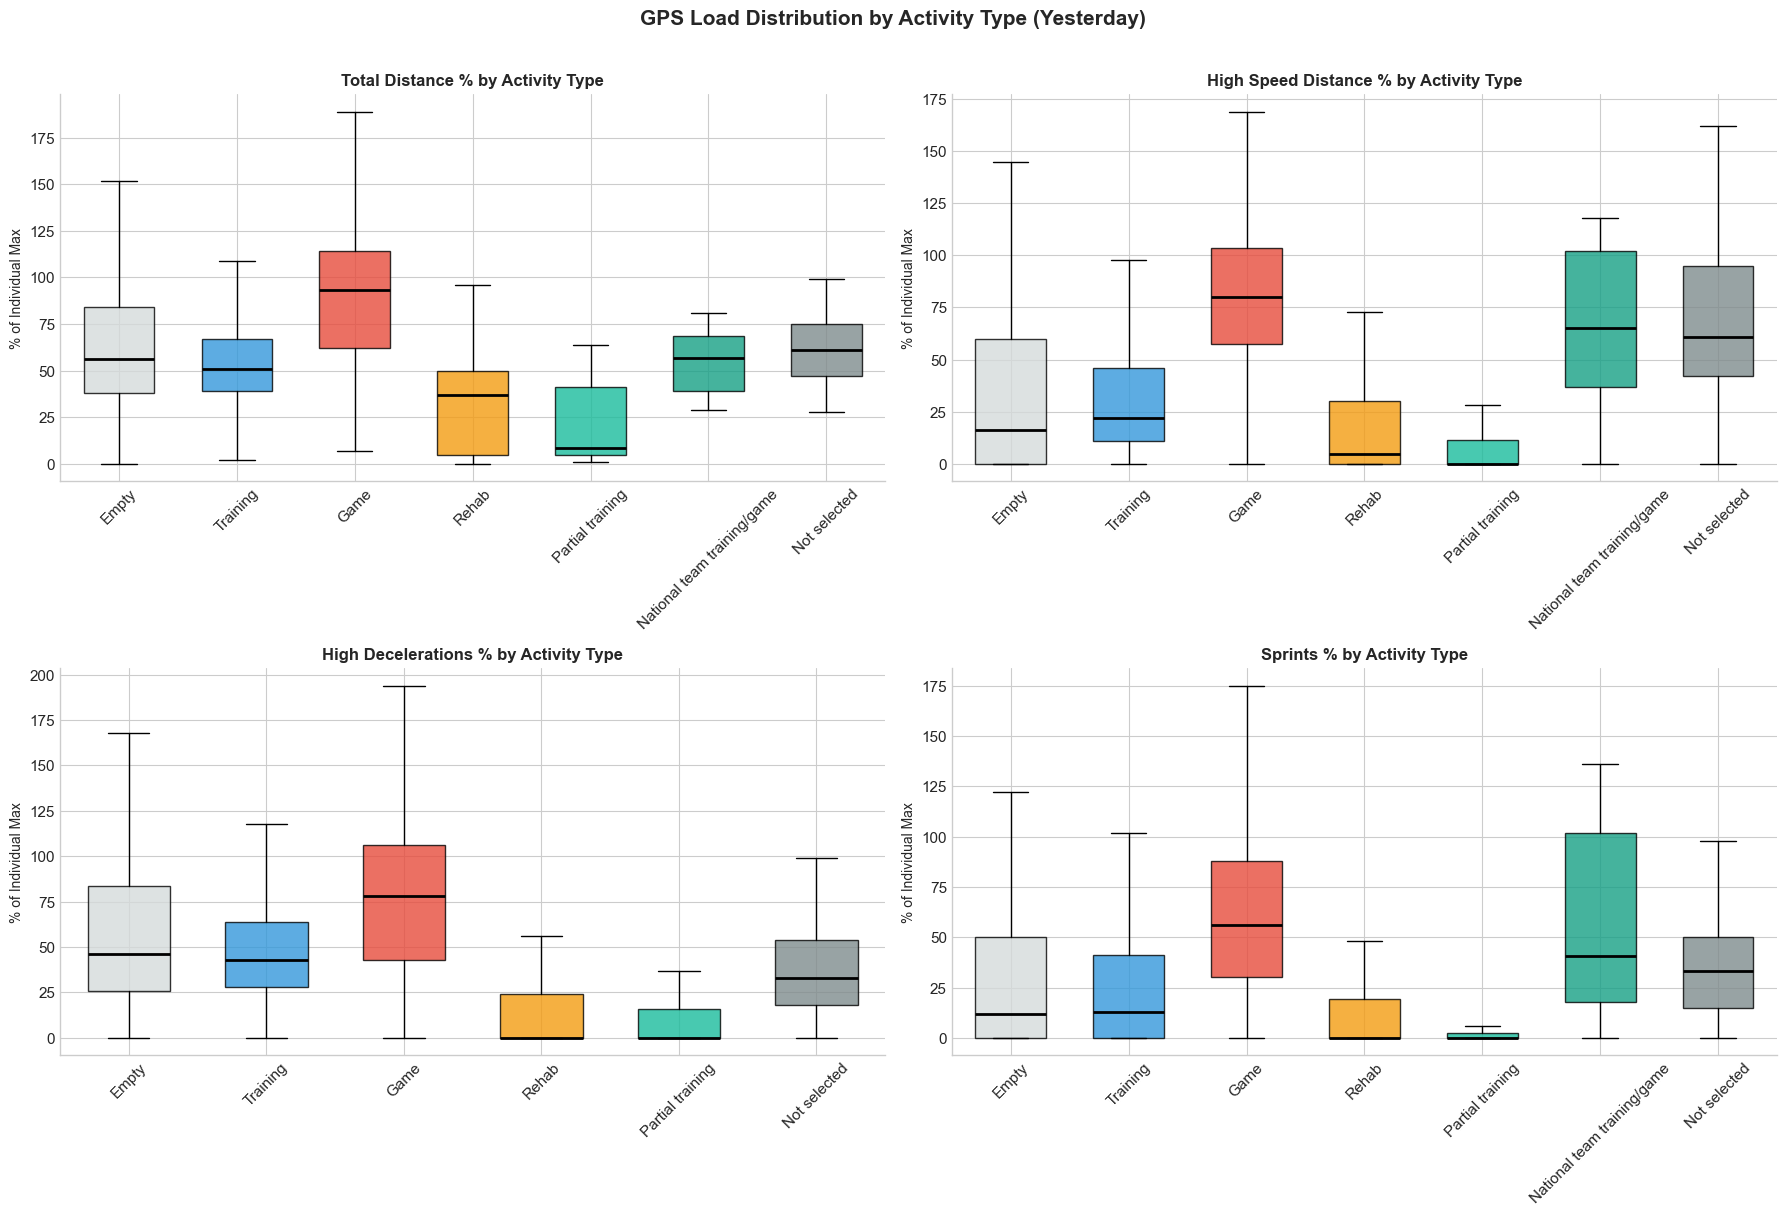

In [36]:
# GPS Load distributions by Activity Type Yesterday
# Focus on main activity types with sufficient data
main_activities = df['Activity Type Yesterday'].value_counts()
main_activities = main_activities[main_activities > 30].index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

load_cols = ['Total Distance % Yesterday', 'High Speed Distance % Yesterday',
             'High Decelerations % Yesterday', 'Sprints % Yesterday']

for ax, col in zip(axes, load_cols):
    data_by_activity = []
    labels = []
    for act in main_activities:
        vals = df[df['Activity Type Yesterday'] == act][col].dropna()
        if len(vals) > 5:
            data_by_activity.append(vals)
            labels.append(act)
    
    bp = ax.boxplot(data_by_activity, labels=labels, patch_artist=True,
                    widths=0.6, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    
    colors_cycle = [ACTIVITY_COLORS.get(a, '#bdc3c7') for a in labels]
    for patch, c in zip(bp['boxes'], colors_cycle):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    
    short_name = col.replace(' % Yesterday', '').replace(' Yesterday', '')
    ax.set_title(f'{short_name} % by Activity Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('% of Individual Max', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('GPS Load Distribution by Activity Type (Yesterday)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

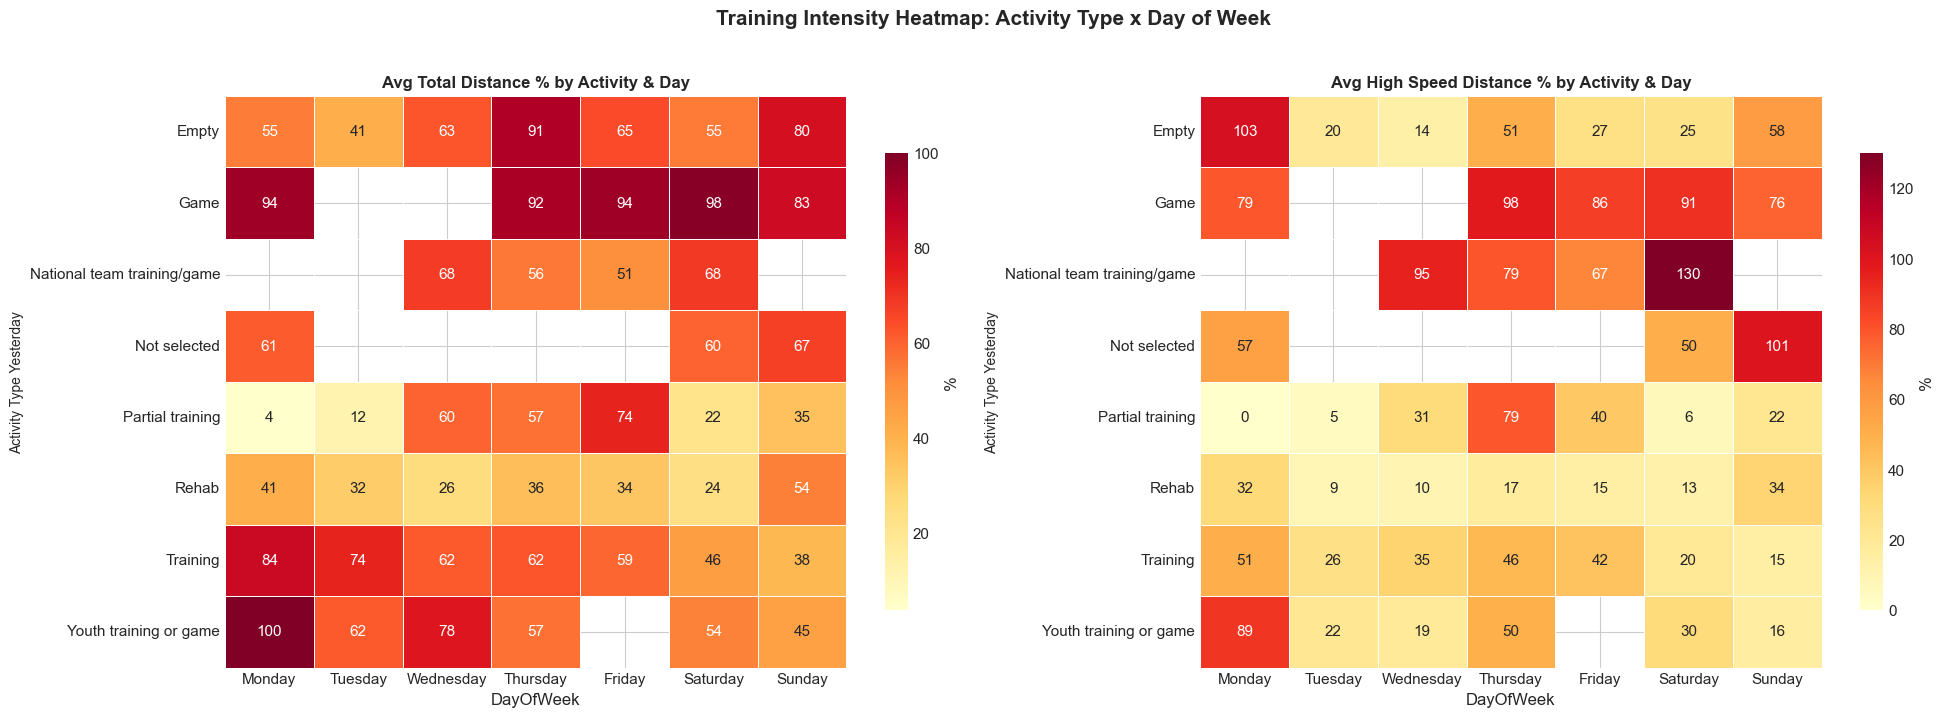

In [37]:
# Heatmap: Average GPS load by Activity Type and Day of Week
# This reveals how training intensity varies across the microcycle for each activity
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Total Distance %
pivot_td = df.pivot_table(values='Total Distance % Yesterday', 
                           index='Activity Type Yesterday', columns='DayOfWeek', 
                           aggfunc='mean')
# Filter to activities with enough data
pivot_td = pivot_td.loc[pivot_td.count(axis=1) >= 3]

sns.heatmap(pivot_td, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': '%', 'shrink': 0.8}, linewidths=0.5, linecolor='white')
axes[0].set_title('Avg Total Distance % by Activity & Day', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Activity Type Yesterday', fontsize=10)

# High Speed Distance %
pivot_hsd = df.pivot_table(values='High Speed Distance % Yesterday',
                            index='Activity Type Yesterday', columns='DayOfWeek',
                            aggfunc='mean')
pivot_hsd = pivot_hsd.loc[pivot_hsd.count(axis=1) >= 3]

sns.heatmap(pivot_hsd, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': '%', 'shrink': 0.8}, linewidths=0.5, linecolor='white')
axes[1].set_title('Avg High Speed Distance % by Activity & Day', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Activity Type Yesterday', fontsize=10)

plt.suptitle('Training Intensity Heatmap: Activity Type x Day of Week', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

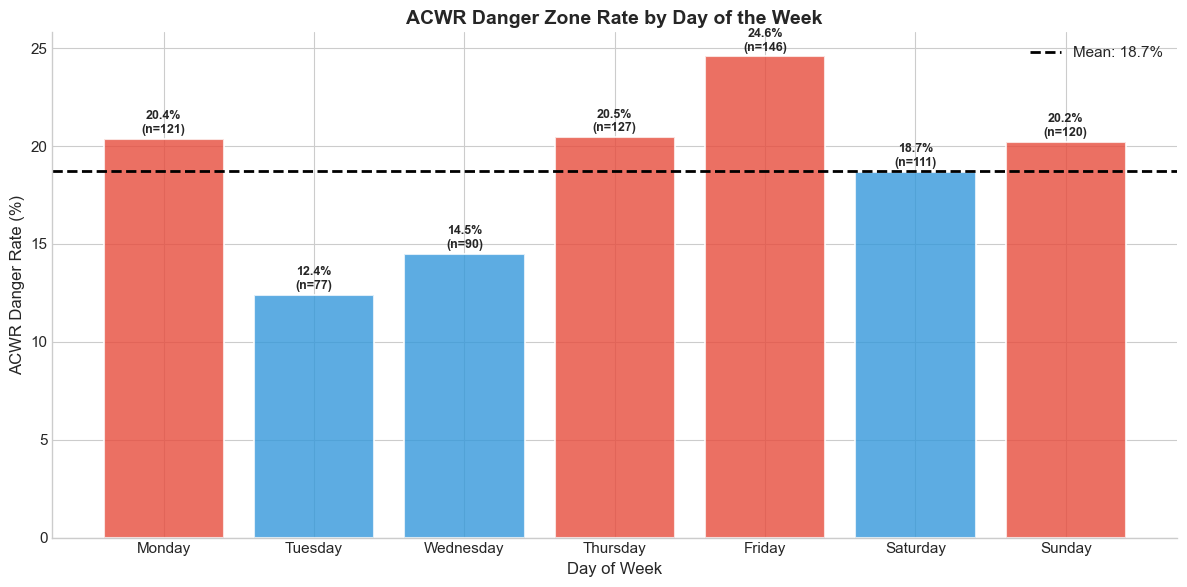

In [38]:
# ACWR Danger Zone rate by Day of the Week
fig, ax = plt.subplots(figsize=(12, 6))

danger_by_day = df.groupby('DayOfWeek')['Any ACWR Danger'].agg(['sum', 'count', 'mean'])
danger_by_day['rate'] = danger_by_day['mean'] * 100

bars = ax.bar(range(7), danger_by_day['rate'].values,
              color=[COLORS['secondary'] if r > danger_by_day['rate'].mean() else COLORS['primary']
                     for r in danger_by_day['rate'].values],
              alpha=0.8, edgecolor='white', linewidth=1.5)

ax.axhline(y=danger_by_day['rate'].mean(), color='black', linestyle='--', linewidth=2,
           label=f"Mean: {danger_by_day['rate'].mean():.1f}%")

for i, (bar, val, n) in enumerate(zip(bars, danger_by_day['rate'].values, danger_by_day['sum'].values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%\n(n={int(n)})', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(7))
ax.set_xticklabels(day_order, fontsize=11)
ax.set_ylabel('ACWR Danger Rate (%)', fontsize=12)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_title('ACWR Danger Zone Rate by Day of the Week', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## 11. Status Transition & Readiness Decline Analysis

The core outcome in this project is understanding when and why players transition from Available to Attention/Injured. This section examines these transitions from multiple angles relevant to the causal modeling objective.

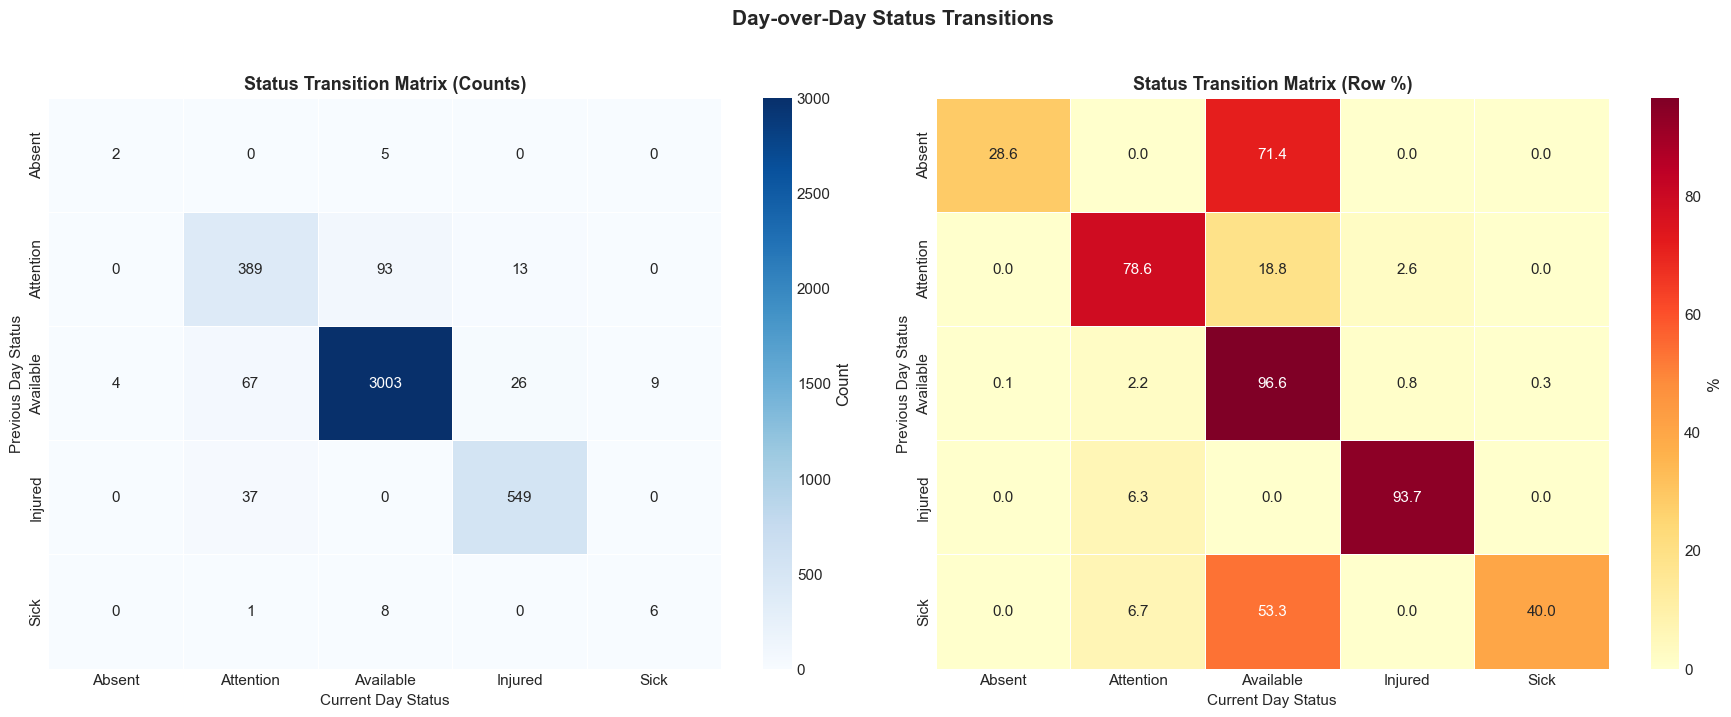


Key Transition Probabilities:
  Absent       → stays: 28.6% | transitions out: 71.4%
  Attention    → stays: 78.6% | transitions out: 21.4%
  Available    → stays: 96.6% | transitions out: 3.4%
  Injured      → stays: 93.7% | transitions out: 6.3%
  Sick         → stays: 40.0% | transitions out: 60.0%


In [39]:
# Status transition matrix: compute day-over-day status transitions per player
df_sorted = df.sort_values(['Player ID', 'Date'])
df_sorted['Previous Status'] = df_sorted.groupby('Player ID')['Status'].shift(1)

# Remove first observation per player (no previous status)
transitions = df_sorted.dropna(subset=['Previous Status'])

# Transition counts
transition_matrix = pd.crosstab(transitions['Previous Status'], transitions['Status'])
transition_pct = pd.crosstab(transitions['Previous Status'], transitions['Status'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Counts
sns.heatmap(transition_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Count'})
axes[0].set_title('Status Transition Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Previous Day Status', fontsize=11)
axes[0].set_xlabel('Current Day Status', fontsize=11)

# Percentages
sns.heatmap(transition_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, linecolor='white', cbar_kws={'label': '%'})
axes[1].set_title('Status Transition Matrix (Row %)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Previous Day Status', fontsize=11)
axes[1].set_xlabel('Current Day Status', fontsize=11)

plt.suptitle('Day-over-Day Status Transitions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Key insight: probability of leaving each state
print("\nKey Transition Probabilities:")
print("="*60)
for status in transition_pct.index:
    stay_pct = transition_pct.loc[status, status] if status in transition_pct.columns else 0
    print(f"  {status:12} → stays: {stay_pct:.1f}% | transitions out: {100-stay_pct:.1f}%")

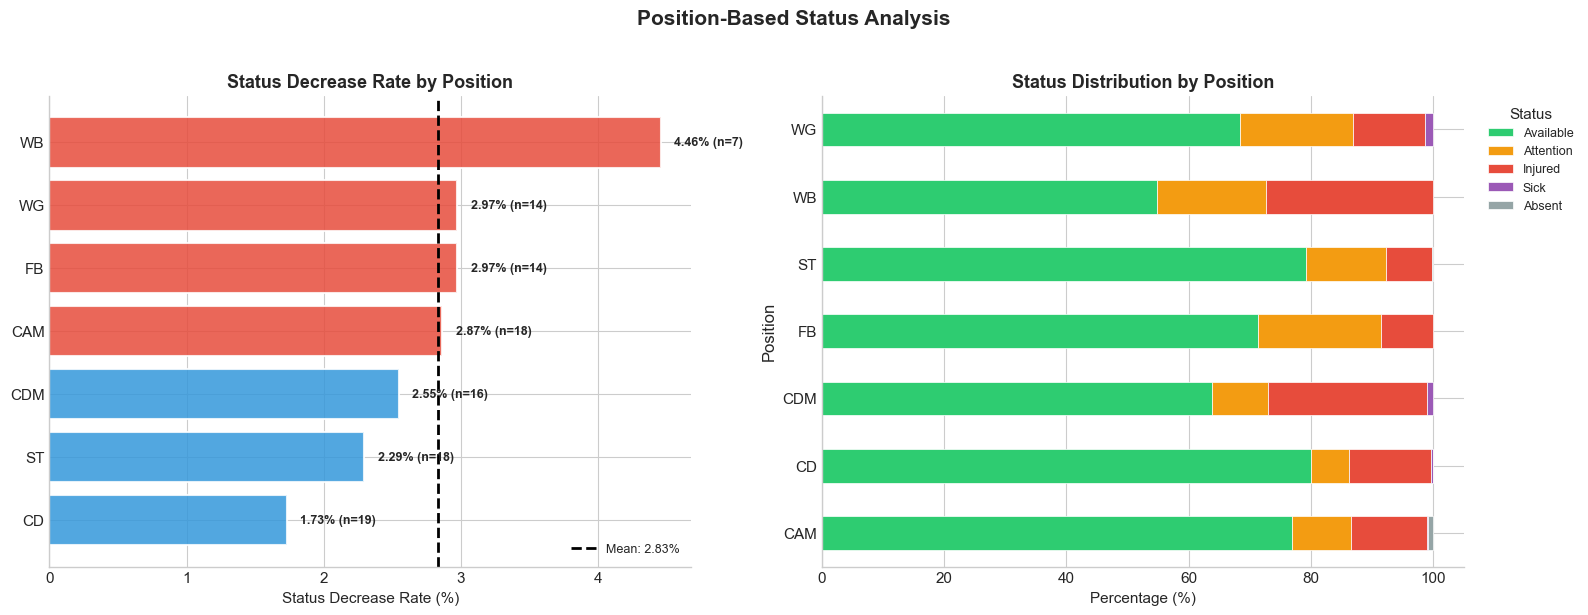

In [40]:
# Status Decrease by Position
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rate
decrease_by_pos = df.groupby('Position')['Status Decrease'].agg(['sum', 'count', 'mean'])
decrease_by_pos['rate'] = decrease_by_pos['mean'] * 100
decrease_by_pos = decrease_by_pos.sort_values('rate', ascending=True)

ax = axes[0]
colors_pos = [COLORS['secondary'] if r > decrease_by_pos['rate'].mean() else COLORS['primary'] 
              for r in decrease_by_pos['rate'].values]
bars = ax.barh(range(len(decrease_by_pos)), decrease_by_pos['rate'].values,
               color=colors_pos, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(decrease_by_pos)))
ax.set_yticklabels(decrease_by_pos.index, fontsize=11)
ax.axvline(x=decrease_by_pos['rate'].mean(), color='black', linestyle='--', linewidth=2,
           label=f"Mean: {decrease_by_pos['rate'].mean():.2f}%")
for i, (val, n) in enumerate(zip(decrease_by_pos['rate'].values, decrease_by_pos['sum'].values)):
    ax.text(val + 0.1, i, f'{val:.2f}% (n={int(n)})', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Status Decrease Rate (%)', fontsize=11)
ax.set_title('Status Decrease Rate by Position', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Status distribution by position
ax = axes[1]
status_pos_ct = pd.crosstab(df['Position'], df['Status'], normalize='index') * 100
status_order = ['Available', 'Attention', 'Injured', 'Sick', 'Absent']
status_pos_ct = status_pos_ct[[c for c in status_order if c in status_pos_ct.columns]]
status_pos_ct.plot(kind='barh', stacked=True, ax=ax,
                   color=[STATUS_COLORS.get(s, '#95a5a6') for s in status_pos_ct.columns],
                   edgecolor='white', linewidth=0.5)
ax.set_title('Status Distribution by Position', fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage (%)', fontsize=11)
ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.suptitle('Position-Based Status Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

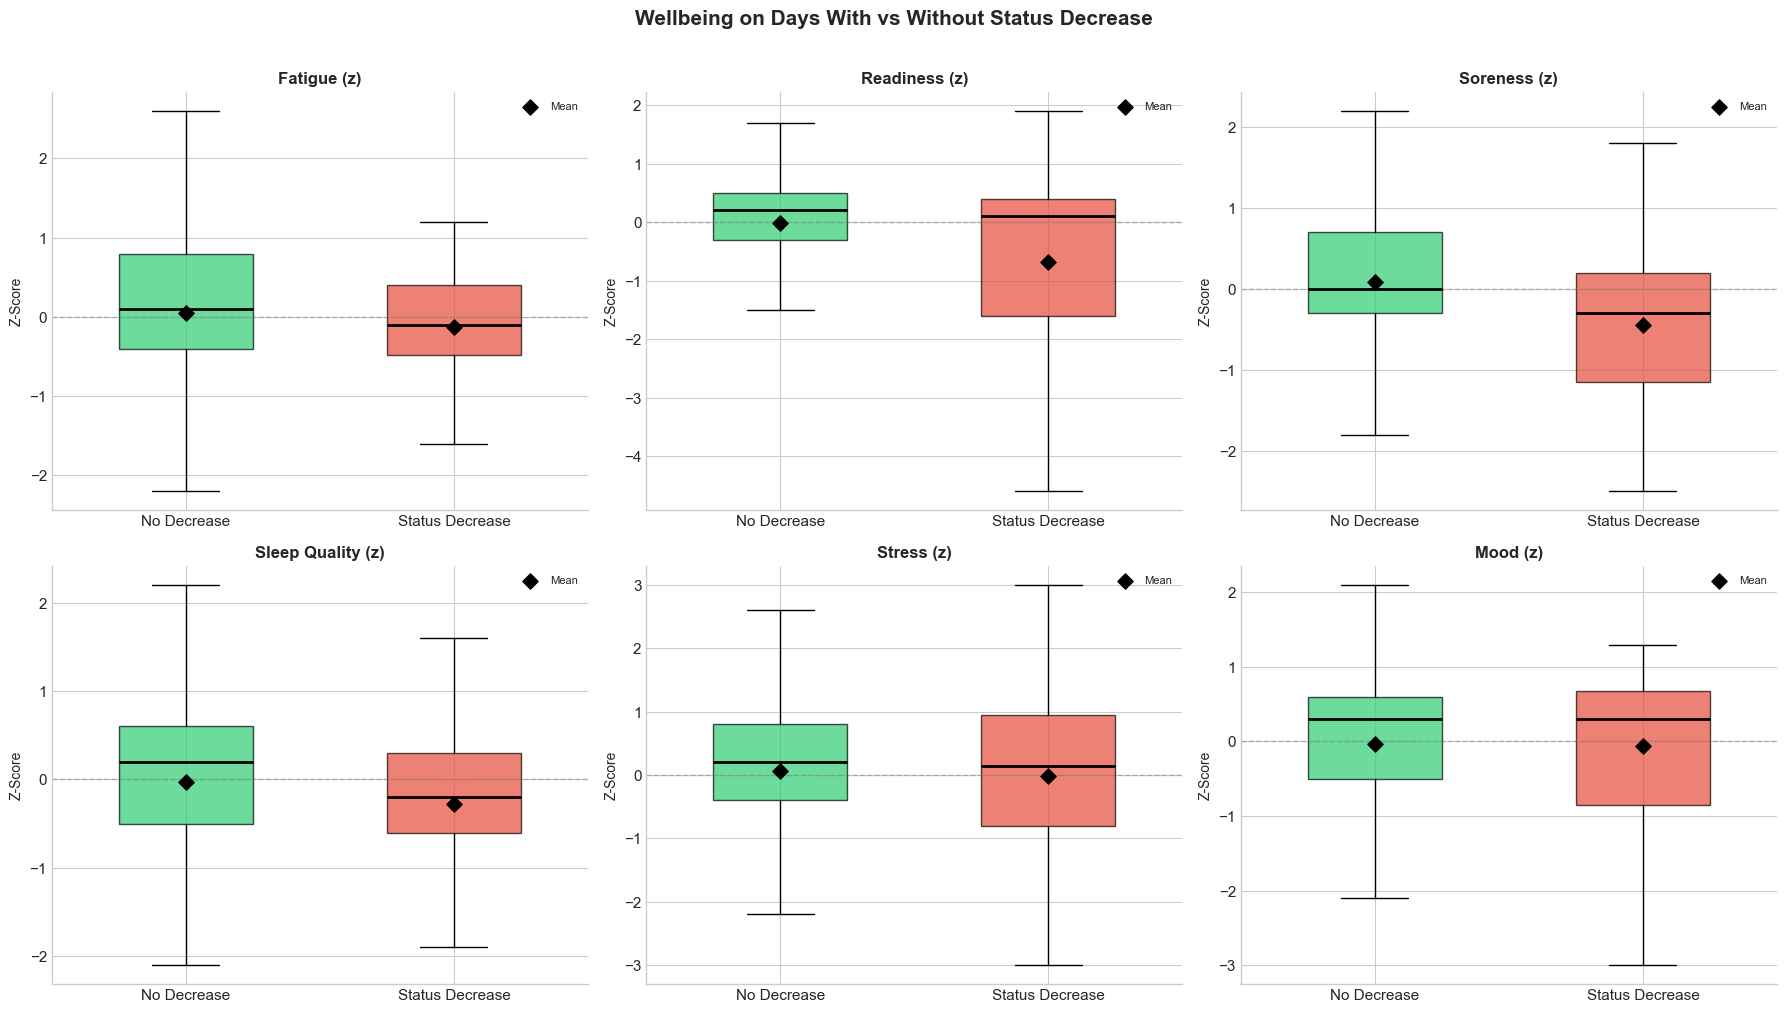

In [41]:
# Wellbeing comparison: days WITH vs WITHOUT status decrease
# This reveals whether wellbeing signals precede status declines
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

wellbeing_all = ['Fatigue (z)', 'Readiness (z)', 'Soreness (z)', 
                 'Sleep Quality (z)', 'Stress (z)', 'Mood (z)']

for ax, col in zip(axes, wellbeing_all):
    no_decrease = df[df['Status Decrease'] == 0][col].dropna()
    yes_decrease = df[df['Status Decrease'] == 1][col].dropna()
    
    bp = ax.boxplot([no_decrease, yes_decrease],
                    labels=['No Decrease', 'Status Decrease'],
                    patch_artist=True, widths=0.5, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLORS['success'])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(COLORS['secondary'])
    bp['boxes'][1].set_alpha(0.7)
    
    # Add means as diamonds
    ax.scatter([1, 2], [no_decrease.mean(), yes_decrease.mean()], 
               color='black', marker='D', s=60, zorder=5, label='Mean')
    
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Z-Score', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Wellbeing on Days With vs Without Status Decrease', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

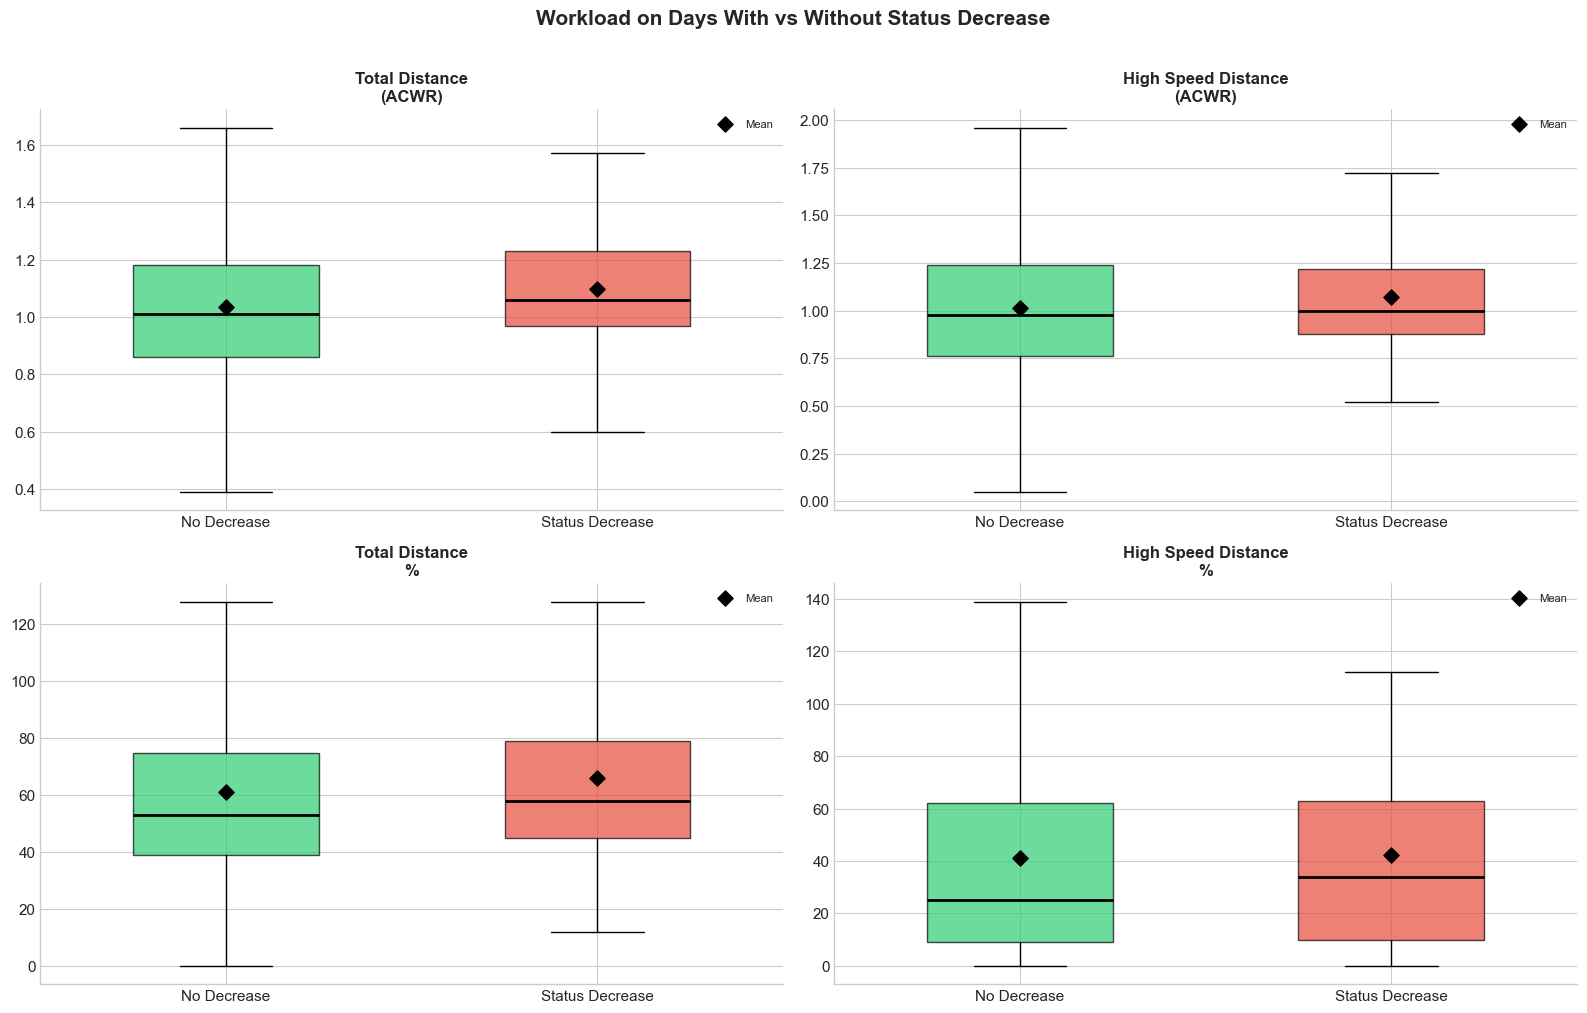

In [42]:
# Workload comparison: days WITH vs WITHOUT status decrease
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

load_compare_cols = ['Total Distance (ACWR) Yesterday', 'High Speed Distance (ACWR) Yesterday',
                     'Total Distance % Yesterday', 'High Speed Distance % Yesterday']

for ax, col in zip(axes, load_compare_cols):
    no_decrease = df[df['Status Decrease'] == 0][col].dropna()
    yes_decrease = df[df['Status Decrease'] == 1][col].dropna()
    
    bp = ax.boxplot([no_decrease, yes_decrease],
                    labels=['No Decrease', 'Status Decrease'],
                    patch_artist=True, widths=0.5, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLORS['success'])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(COLORS['secondary'])
    bp['boxes'][1].set_alpha(0.7)
    
    ax.scatter([1, 2], [no_decrease.mean(), yes_decrease.mean()],
               color='black', marker='D', s=60, zorder=5, label='Mean')
    
    short_name = col.replace(' Yesterday', '').replace(' (ACWR)', '\n(ACWR)').replace(' %', '\n%')
    ax.set_title(short_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Workload on Days With vs Without Status Decrease', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 12. Player-Level Profiles & Individual Variability

The project uses individualized Z-scores to acknowledge unique physiological baselines. This section examines inter-player variability and individual availability patterns, which are central to the "Small N, Large T" challenge.

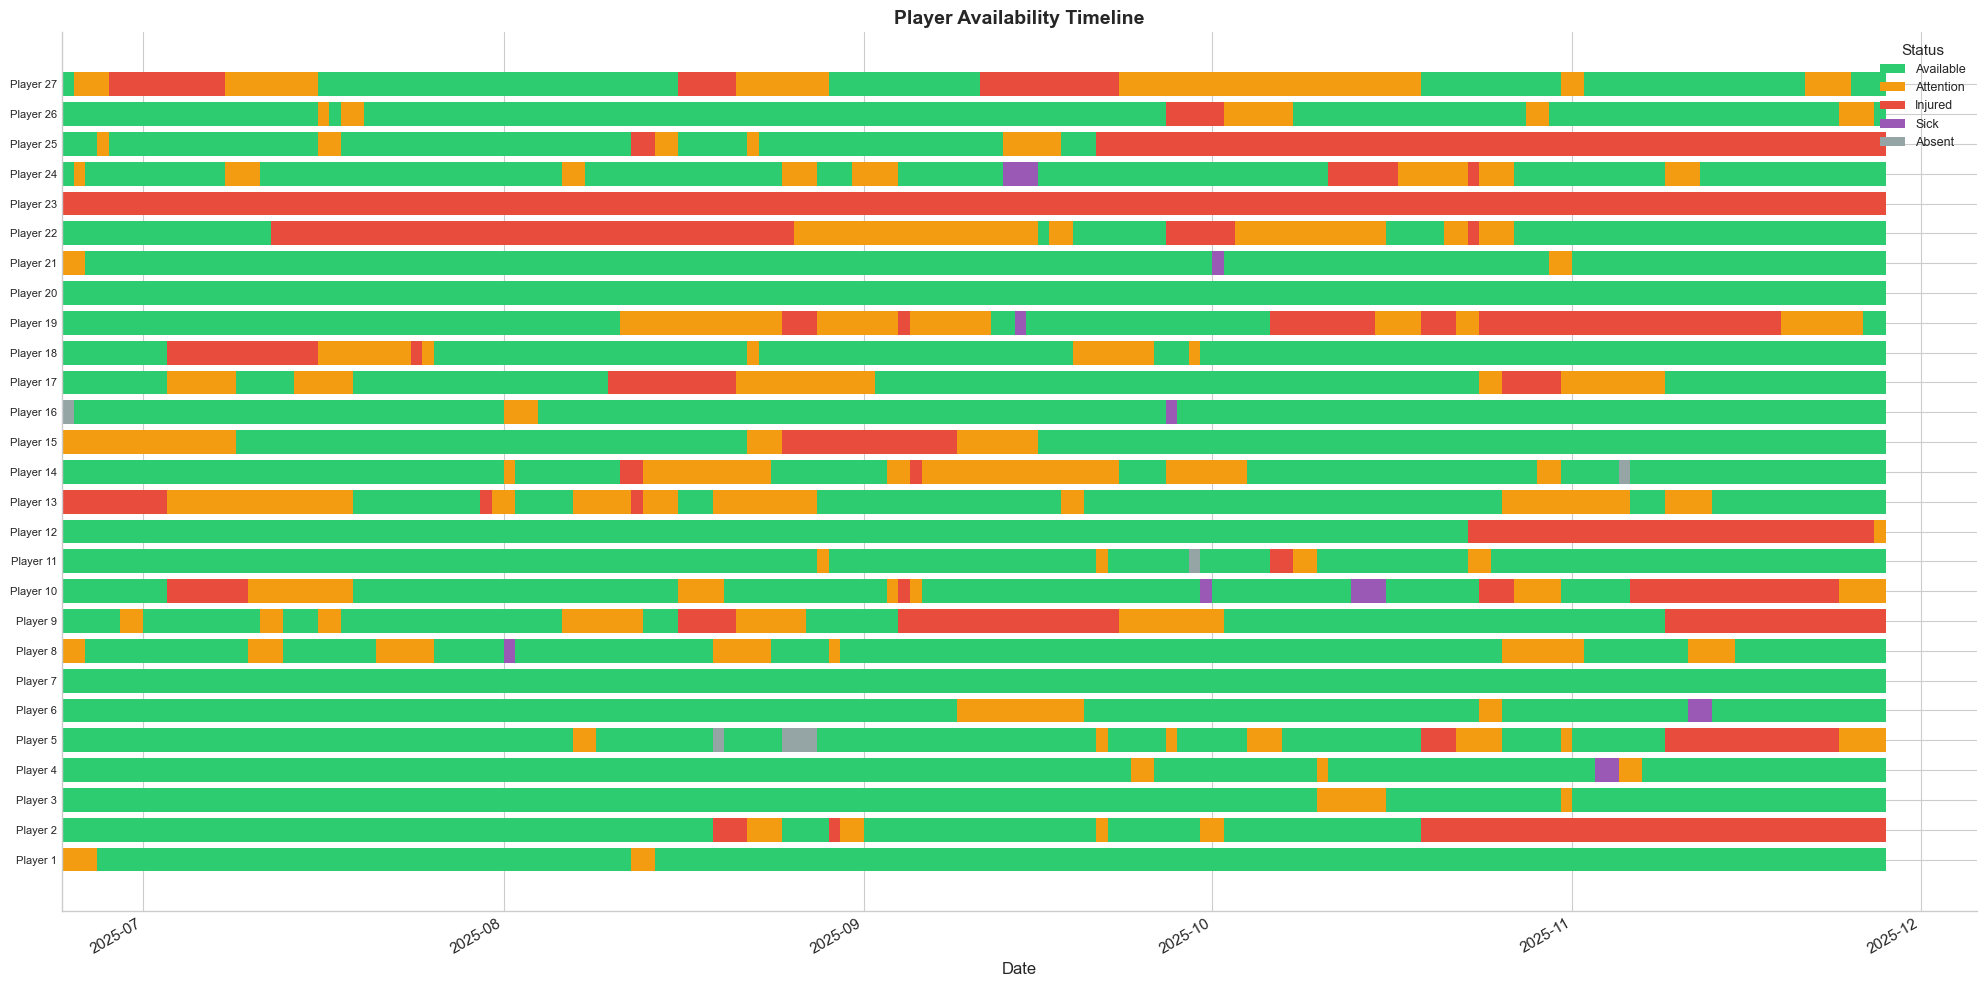

In [43]:
# Player availability timeline (Gantt-style chart)
# Show each player's status over time
player_ids = sorted(df['Player ID'].unique())

fig, ax = plt.subplots(figsize=(20, 10))

for i, pid in enumerate(player_ids):
    player_data = df[df['Player ID'] == pid].sort_values('Date')
    for _, row in player_data.iterrows():
        color = STATUS_COLORS.get(row['Status'], '#95a5a6')
        ax.barh(i, 1, left=row['Date'], height=0.8, color=color, edgecolor='none')

ax.set_yticks(range(len(player_ids)))
ax.set_yticklabels([f'Player {pid}' for pid in player_ids], fontsize=8)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Player Availability Timeline', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in STATUS_COLORS.items()]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, title='Status')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

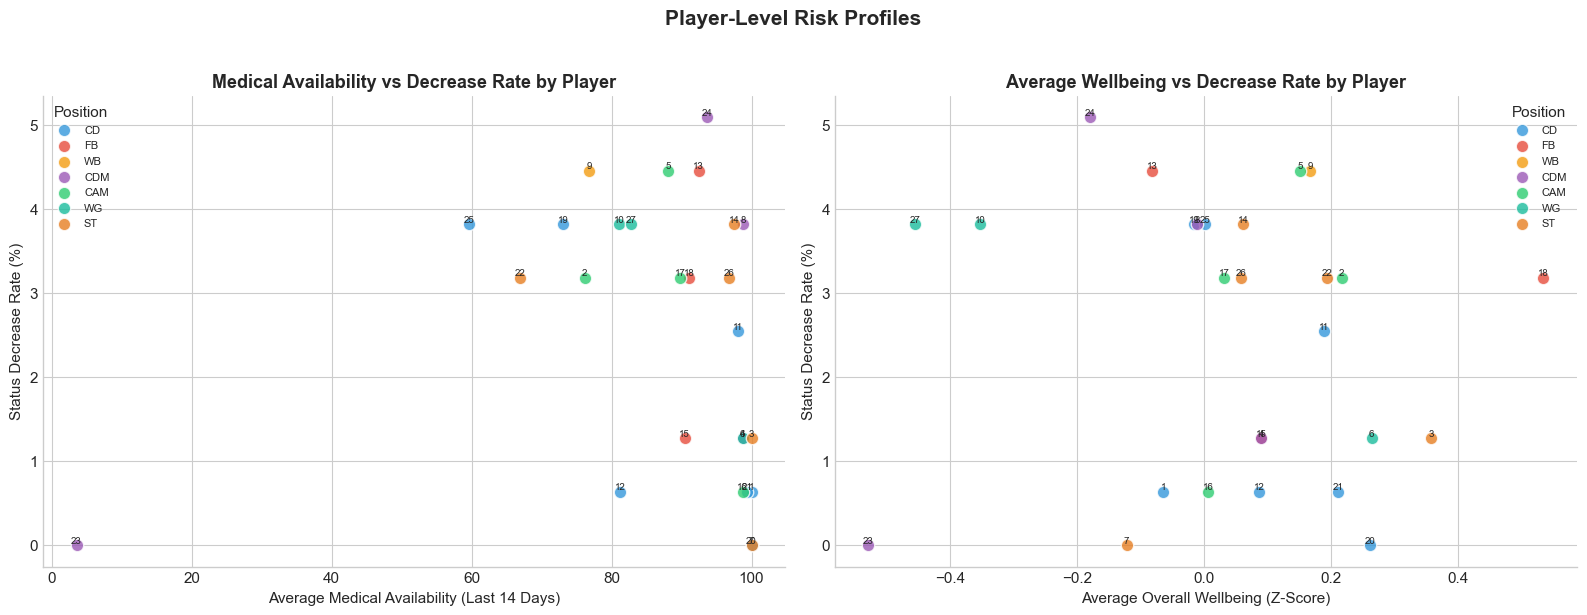

In [44]:
# Per-player summary statistics
player_summary = df.groupby('Player ID').agg({
    'Status Decrease': ['sum', 'mean'],
    'Any ACWR Danger': ['sum', 'mean'],
    'Overall Wellbeing': 'mean',
    'Medical Availability Last 14 Days': 'mean',
    'Date': 'count'
}).reset_index()
player_summary.columns = ['Player ID', 'Total Decreases', 'Decrease Rate', 
                           'Total Danger', 'Danger Rate',
                           'Avg Wellbeing', 'Avg Med Availability', 'Observations']
player_summary['Decrease Rate %'] = player_summary['Decrease Rate'] * 100
player_summary['Danger Rate %'] = player_summary['Danger Rate'] * 100

# Add position
player_pos = df.groupby('Player ID')['Position'].first().reset_index()
player_summary = player_summary.merge(player_pos, on='Player ID')

# Scatter: Medical Availability vs Status Decrease Rate (colored by position)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pos_colors = {'CD': '#3498db', 'FB': '#e74c3c', 'WB': '#f39c12', 
              'CDM': '#9b59b6', 'CAM': '#2ecc71', 'WG': '#1abc9c', 'ST': '#e67e22'}

ax = axes[0]
for pos in pos_colors:
    mask = player_summary['Position'] == pos
    ax.scatter(player_summary.loc[mask, 'Avg Med Availability'], 
               player_summary.loc[mask, 'Decrease Rate %'],
               c=pos_colors[pos], s=80, alpha=0.8, label=pos, edgecolors='white', linewidth=1)
    for _, row in player_summary[mask].iterrows():
        ax.annotate(str(int(row['Player ID'])), (row['Avg Med Availability'], row['Decrease Rate %']),
                    fontsize=7, ha='center', va='bottom')

ax.set_xlabel('Average Medical Availability (Last 14 Days)', fontsize=11)
ax.set_ylabel('Status Decrease Rate (%)', fontsize=11)
ax.set_title('Medical Availability vs Decrease Rate by Player', fontsize=13, fontweight='bold')
ax.legend(title='Position', fontsize=8)

# Scatter: Overall Wellbeing vs Status Decrease Rate
ax = axes[1]
for pos in pos_colors:
    mask = player_summary['Position'] == pos
    ax.scatter(player_summary.loc[mask, 'Avg Wellbeing'],
               player_summary.loc[mask, 'Decrease Rate %'],
               c=pos_colors[pos], s=80, alpha=0.8, label=pos, edgecolors='white', linewidth=1)
    for _, row in player_summary[mask].iterrows():
        ax.annotate(str(int(row['Player ID'])), (row['Avg Wellbeing'], row['Decrease Rate %']),
                    fontsize=7, ha='center', va='bottom')

ax.set_xlabel('Average Overall Wellbeing (Z-Score)', fontsize=11)
ax.set_ylabel('Status Decrease Rate (%)', fontsize=11)
ax.set_title('Average Wellbeing vs Decrease Rate by Player', fontsize=13, fontweight='bold')
ax.legend(title='Position', fontsize=8)

plt.suptitle('Player-Level Risk Profiles', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

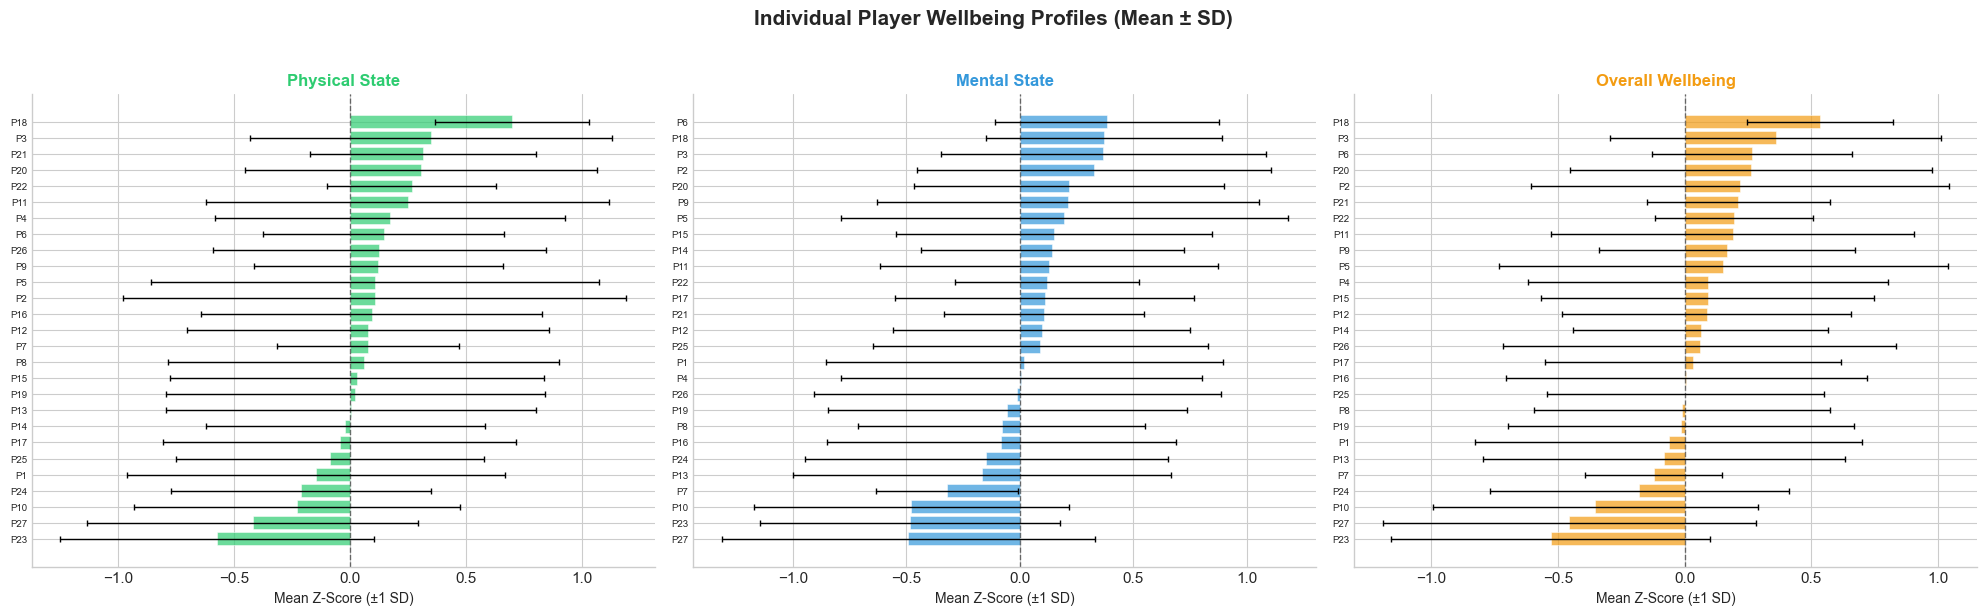

In [45]:
# Inter-player variability: distribution of wellbeing scores per player (violin plots)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col, color in zip(axes, ['Physical State', 'Mental State', 'Overall Wellbeing'],
                           [COLORS['success'], COLORS['primary'], COLORS['warning']]):
    player_means = df.groupby('Player ID')[col].mean().sort_values()
    player_stds = df.groupby('Player ID')[col].std()
    
    ax.barh(range(len(player_means)), player_means.values, 
            xerr=player_stds.loc[player_means.index].values,
            color=color, alpha=0.7, edgecolor='white', linewidth=0.5,
            error_kw=dict(ecolor='black', capsize=2, linewidth=1))
    
    ax.set_yticks(range(len(player_means)))
    ax.set_yticklabels([f'P{int(pid)}' for pid in player_means.index], fontsize=7)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Mean Z-Score (±1 SD)', fontsize=10)
    ax.set_title(col, fontsize=12, fontweight='bold', color=color)

plt.suptitle('Individual Player Wellbeing Profiles (Mean ± SD)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 13. Workload-Wellbeing Interaction

The supercompensation theory suggests that training stress must be balanced with recovery. This section explores the relationship between external load (GPS) and subjective wellbeing, and how the ACWR "sweet spot" (0.8-1.3) relates to readiness outcomes.

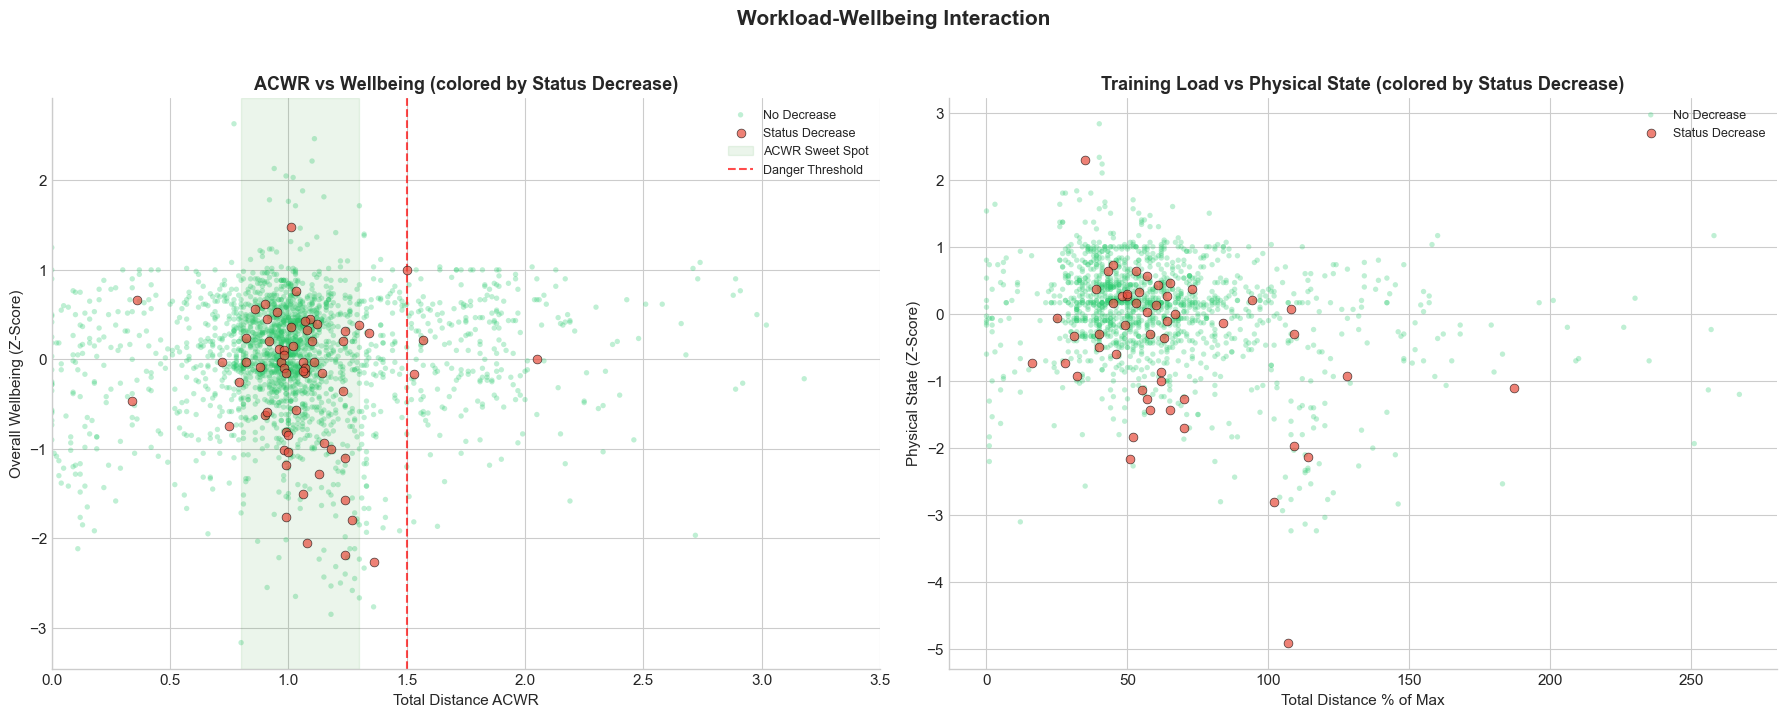

In [46]:
# Scatter: Total Distance ACWR vs Overall Wellbeing, colored by Status Decrease
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: ACWR vs Wellbeing
ax = axes[0]
mask_no = df['Status Decrease'] == 0
mask_yes = df['Status Decrease'] == 1

ax.scatter(df.loc[mask_no, 'Total Distance (ACWR) Yesterday'],
           df.loc[mask_no, 'Overall Wellbeing'],
           c=COLORS['success'], alpha=0.3, s=15, label='No Decrease', edgecolors='none')
ax.scatter(df.loc[mask_yes, 'Total Distance (ACWR) Yesterday'],
           df.loc[mask_yes, 'Overall Wellbeing'],
           c=COLORS['secondary'], alpha=0.7, s=40, label='Status Decrease', 
           edgecolors='black', linewidth=0.5, zorder=5)

# ACWR zones
ax.axvspan(0.8, 1.3, alpha=0.08, color='green', label='ACWR Sweet Spot')
ax.axvline(x=1.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Danger Threshold')

ax.set_xlabel('Total Distance ACWR', fontsize=11)
ax.set_ylabel('Overall Wellbeing (Z-Score)', fontsize=11)
ax.set_title('ACWR vs Wellbeing (colored by Status Decrease)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 3.5)
ax.legend(fontsize=9)

# Right: Total Distance % vs Physical State
ax = axes[1]
ax.scatter(df.loc[mask_no, 'Total Distance % Yesterday'],
           df.loc[mask_no, 'Physical State'],
           c=COLORS['success'], alpha=0.3, s=15, label='No Decrease', edgecolors='none')
ax.scatter(df.loc[mask_yes, 'Total Distance % Yesterday'],
           df.loc[mask_yes, 'Physical State'],
           c=COLORS['secondary'], alpha=0.7, s=40, label='Status Decrease',
           edgecolors='black', linewidth=0.5, zorder=5)

ax.set_xlabel('Total Distance % of Max', fontsize=11)
ax.set_ylabel('Physical State (Z-Score)', fontsize=11)
ax.set_title('Training Load vs Physical State (colored by Status Decrease)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Workload-Wellbeing Interaction', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

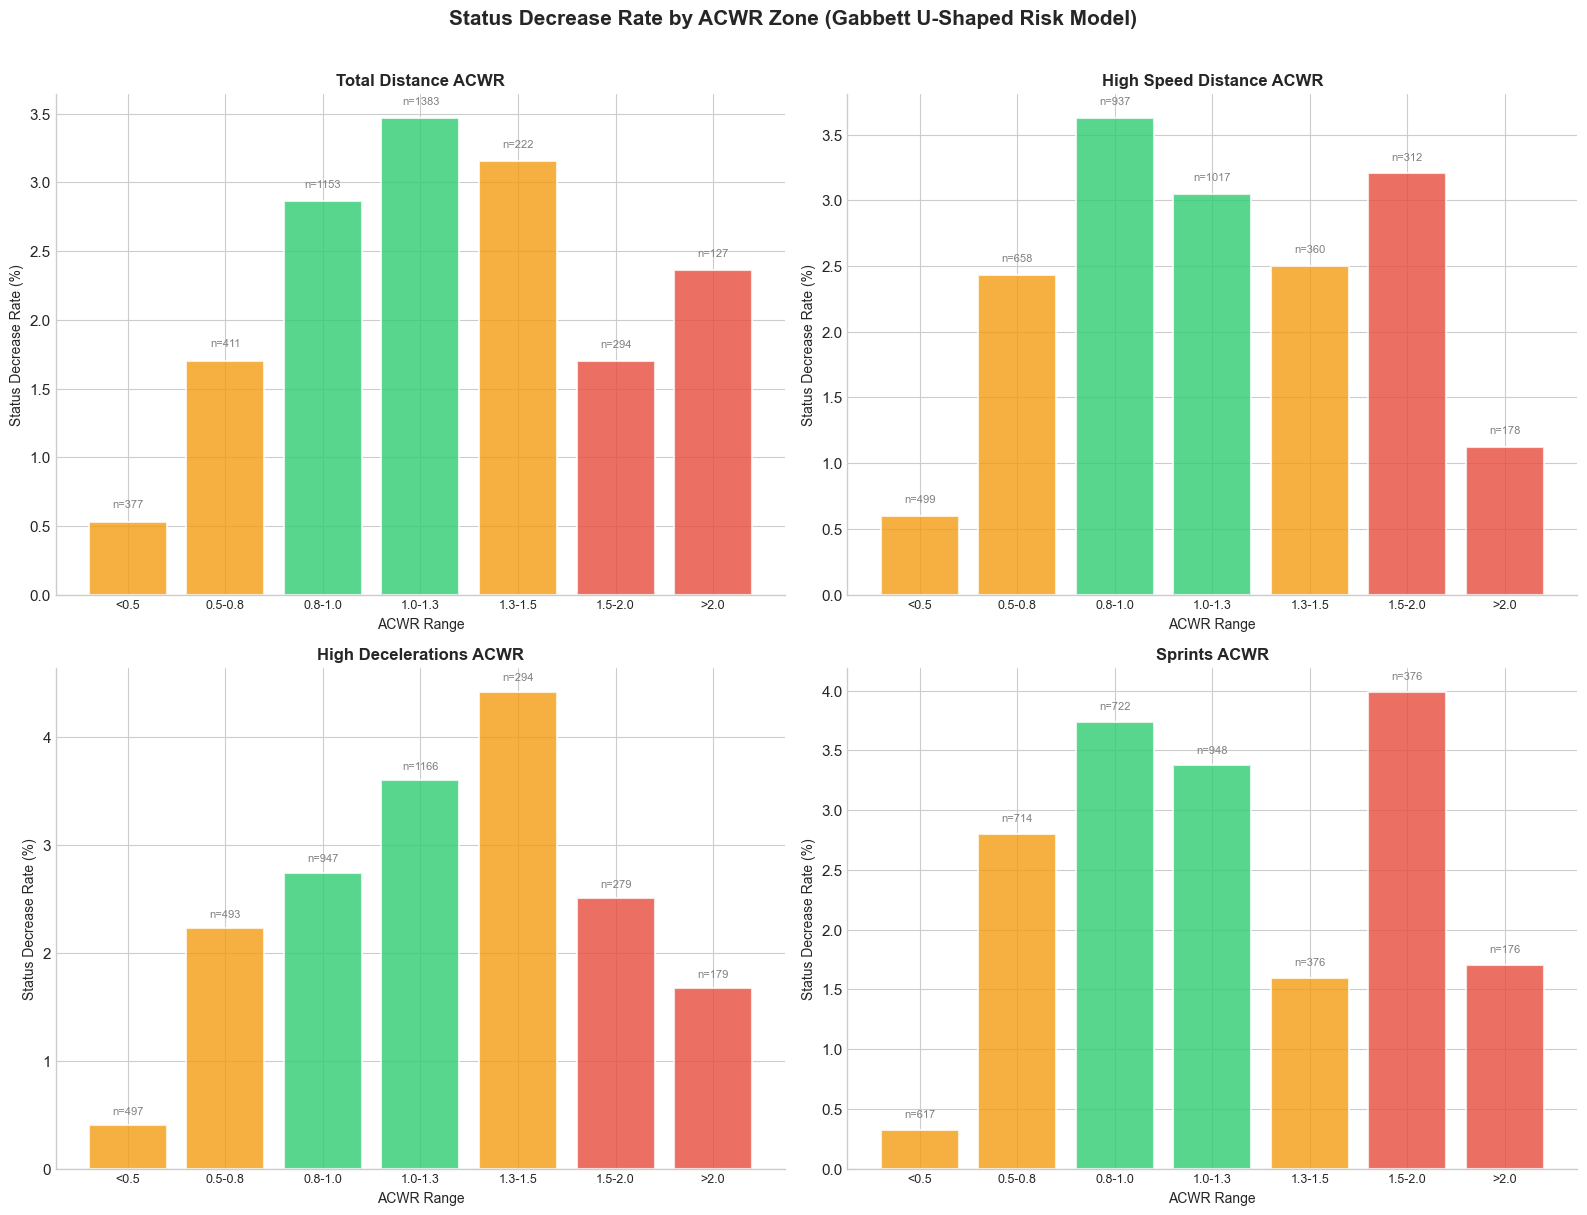

In [47]:
# ACWR Sweet Spot Analysis: Status Decrease rate by ACWR bin
# Following Gabbett's U-shaped risk model
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, col, color in zip(axes, acwr_cols, acwr_colors):
    data = df[[col, 'Status Decrease']].dropna()
    
    # Create ACWR bins
    bins = [0, 0.5, 0.8, 1.0, 1.3, 1.5, 2.0, data[col].max() + 0.1]
    labels_bin = ['<0.5', '0.5-0.8', '0.8-1.0', '1.0-1.3', '1.3-1.5', '1.5-2.0', '>2.0']
    data['ACWR_bin'] = pd.cut(data[col], bins=bins, labels=labels_bin, include_lowest=True)
    
    binned = data.groupby('ACWR_bin', observed=False)['Status Decrease'].agg(['sum', 'count', 'mean'])
    binned['rate'] = binned['mean'] * 100
    
    # Color bins: green for sweet spot, red for danger
    bin_colors = ['#f39c12', '#f39c12', '#2ecc71', '#2ecc71', '#f39c12', '#e74c3c', '#e74c3c']
    
    bars = ax.bar(range(len(binned)), binned['rate'].values, color=bin_colors, 
                  alpha=0.8, edgecolor='white', linewidth=1.5)
    
    # Add sample sizes
    for i, (bar, n) in enumerate(zip(bars, binned['count'].values)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'n={int(n)}', ha='center', fontsize=8, color='grey')
    
    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels(labels_bin, fontsize=9)
    
    short_name = col.replace(' (ACWR) Yesterday', '')
    ax.set_title(f'{short_name} ACWR', fontsize=12, fontweight='bold')
    ax.set_ylabel('Status Decrease Rate (%)', fontsize=10)
    ax.set_xlabel('ACWR Range', fontsize=10)

plt.suptitle('Status Decrease Rate by ACWR Zone (Gabbett U-Shaped Risk Model)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

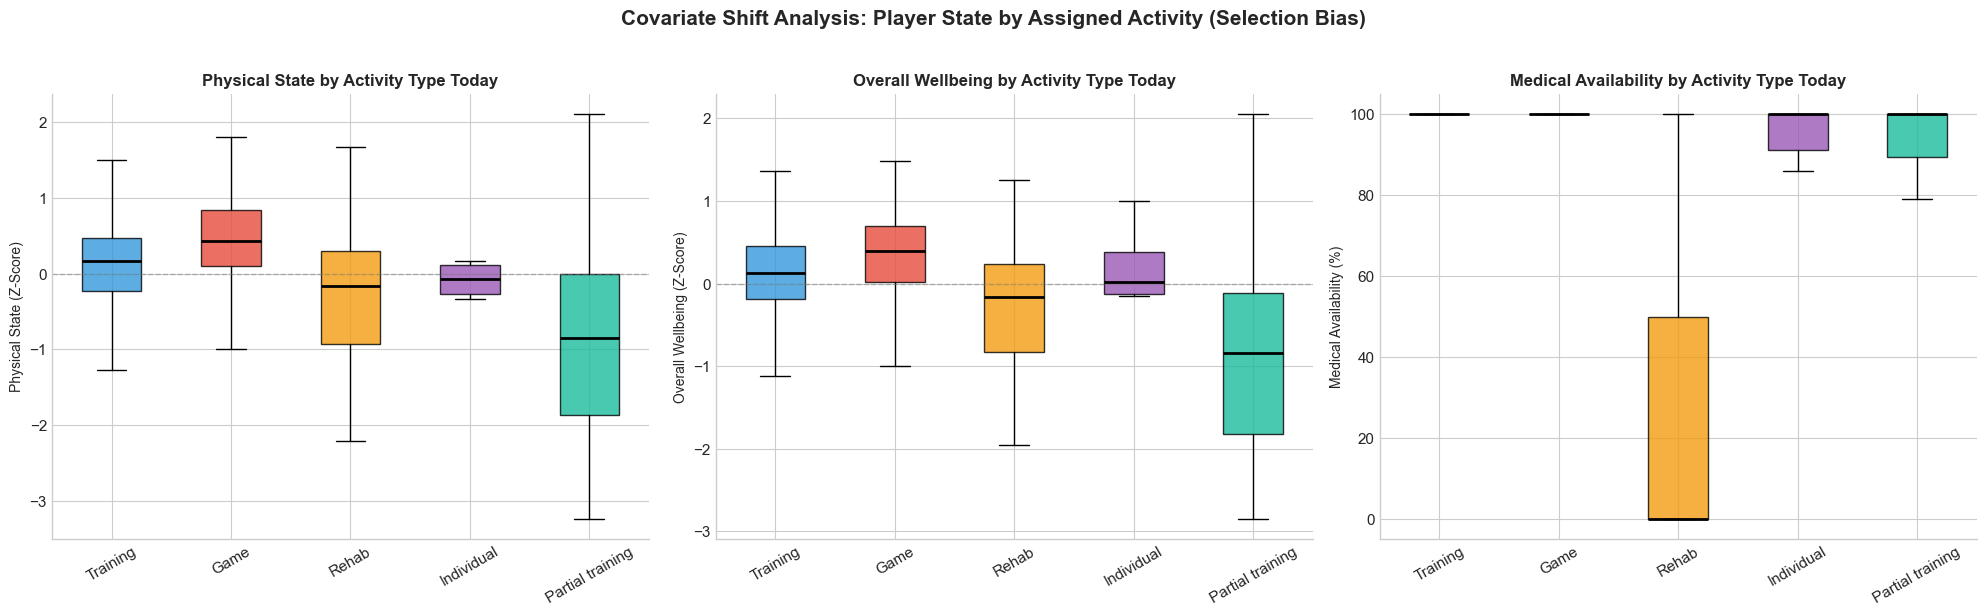

In [48]:
# Covariate Shift Analysis: Do coaches assign different training to players based on their state?
# This is critical for causal inference - shows selection bias
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Filter to training days only
training_mask = df['Activity Type Today'] == 'Training'

# Physical State by Activity Type Today
ax = axes[0]
activities_main = ['Training', 'Game', 'Rehab', 'Individual', 'Partial training']
act_data = [df[df['Activity Type Today'] == act]['Physical State'].dropna() for act in activities_main]
act_data = [d for d, a in zip(act_data, activities_main) if len(d) > 5]
act_labels = [a for d, a in zip([df[df['Activity Type Today'] == act]['Physical State'].dropna() for act in activities_main], activities_main) if len(d) > 5]

bp = ax.boxplot(act_data, labels=act_labels, patch_artist=True, widths=0.5, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
colors_act = [ACTIVITY_COLORS.get(a, '#bdc3c7') for a in act_labels]
for patch, c in zip(bp['boxes'], colors_act):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Physical State by Activity Type Today', fontsize=12, fontweight='bold')
ax.set_ylabel('Physical State (Z-Score)', fontsize=10)
ax.tick_params(axis='x', rotation=30)

# Overall Wellbeing by Activity Type Today
ax = axes[1]
act_data_wb = [df[df['Activity Type Today'] == act]['Overall Wellbeing'].dropna() for act in activities_main]
act_data_wb = [d for d in act_data_wb if len(d) > 5]

bp = ax.boxplot(act_data_wb, labels=act_labels, patch_artist=True, widths=0.5, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], colors_act):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Overall Wellbeing by Activity Type Today', fontsize=12, fontweight='bold')
ax.set_ylabel('Overall Wellbeing (Z-Score)', fontsize=10)
ax.tick_params(axis='x', rotation=30)

# Medical Availability by Activity Type Today
ax = axes[2]
act_data_med = [df[df['Activity Type Today'] == act]['Medical Availability Last 14 Days'].dropna() for act in activities_main]
act_data_med = [d for d in act_data_med if len(d) > 5]

bp = ax.boxplot(act_data_med, labels=act_labels, patch_artist=True, widths=0.5, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], colors_act):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
ax.set_title('Medical Availability by Activity Type Today', fontsize=12, fontweight='bold')
ax.set_ylabel('Medical Availability (%)', fontsize=10)
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Covariate Shift Analysis: Player State by Assigned Activity (Selection Bias)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 14. Match Day Proximity Analysis

A key element of the causal framework is how a 5-day training sequence affects the player's state on match day (Day 6). The `Days Since Game` feature captures how far a player is from the last match. This section examines how metrics evolve as match day approaches.

In [49]:
# Filter to typical match cycle (Days Since Game 1-15)
# Note: Days Since Game is NEVER 0 — it counts days since the last COMPLETED game.
# On a match day, the game hasn't happened yet, so it counts since the previous match.
df_cycle = df[df['Days Since Game'].between(1, 15)].copy()

print(f"Observations within 1-15 days of a game: {len(df_cycle):,} ({len(df_cycle)/len(df)*100:.1f}%)")
print(f"Breakdown by Days Since Game:")
print(df_cycle['Days Since Game'].value_counts().sort_index())
print()
print("Note: Days Since Game minimum = 1 (game was yesterday). Never 0.")
print("Use 'Days Until Match' to identify match days (Days Until Match = 0).")

Observations within 1-15 days of a game: 2,977 (70.2%)
Breakdown by Days Since Game:
Days Since Game
1.0     376
2.0     376
3.0     376
4.0     376
5.0     337
6.0     296
7.0     262
8.0     147
9.0     117
10.0     78
11.0     66
12.0     51
13.0     51
14.0     36
15.0     32
Name: count, dtype: int64

Note: Days Since Game minimum = 1 (game was yesterday). Never 0.
Use 'Days Until Match' to identify match days (Days Until Match = 0).


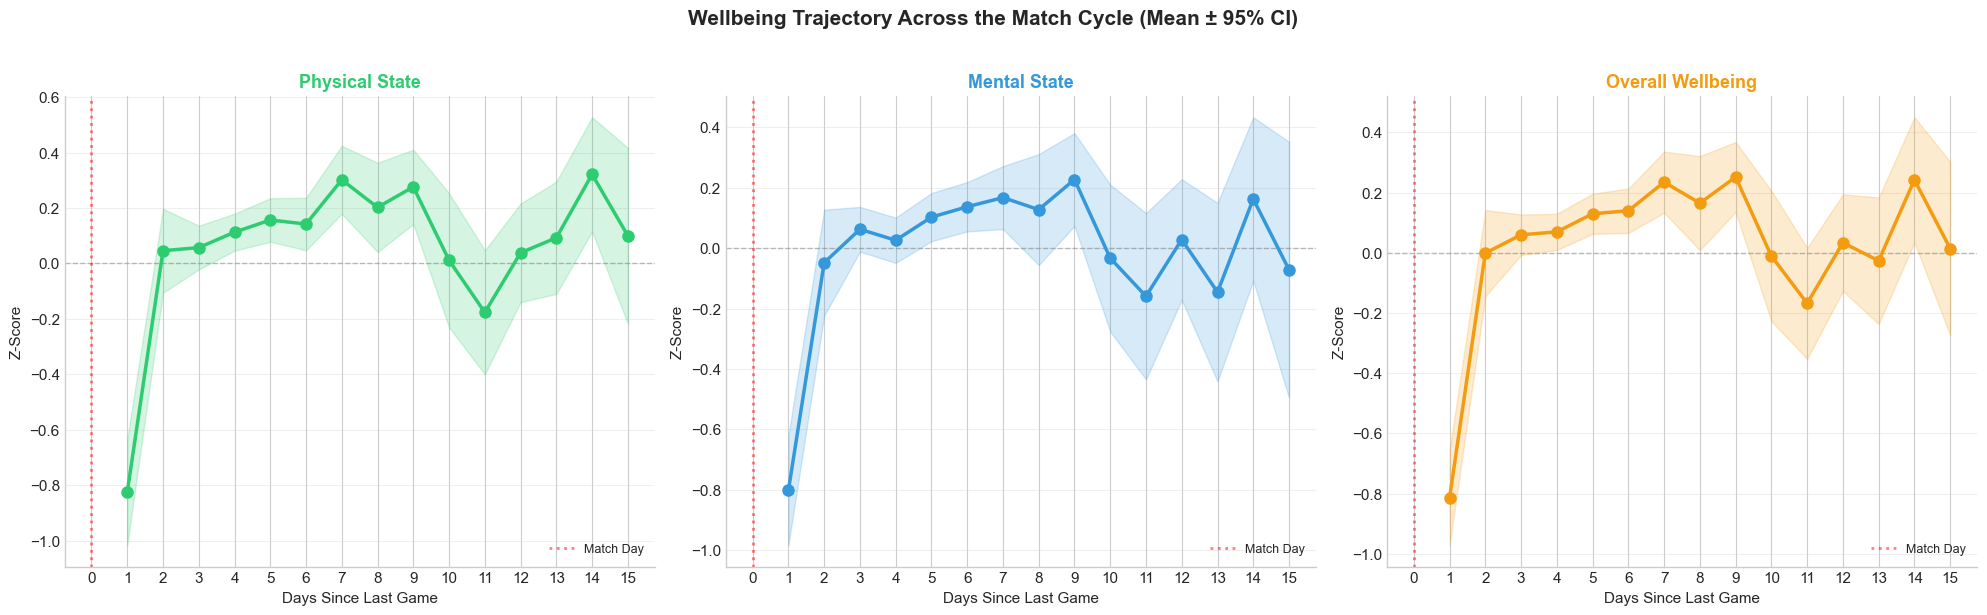

In [50]:
# Wellbeing trajectory across the match cycle
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

composite_cols_cycle = ['Physical State', 'Mental State', 'Overall Wellbeing']
composite_colors_cycle = [COLORS['success'], COLORS['primary'], COLORS['warning']]

for ax, col, color in zip(axes, composite_cols_cycle, composite_colors_cycle):
    grouped = df_cycle.groupby('Days Since Game')[col]
    means = grouped.mean()
    sems = grouped.sem()
    
    ax.plot(means.index, means.values, color=color, marker='o', markersize=8, 
            linewidth=2.5, zorder=3)
    ax.fill_between(means.index, 
                    (means - 1.96 * sems).values, 
                    (means + 1.96 * sems).values,
                    color=color, alpha=0.2)
    
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='red', linestyle=':', linewidth=2, alpha=0.5, label='Match Day')
    ax.set_xlabel('Days Since Last Game', fontsize=11)
    ax.set_ylabel('Z-Score', fontsize=11)
    ax.set_title(col, fontsize=13, fontweight='bold', color=color)
    ax.set_xticks(range(16))
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Wellbeing Trajectory Across the Match Cycle (Mean ± 95% CI)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

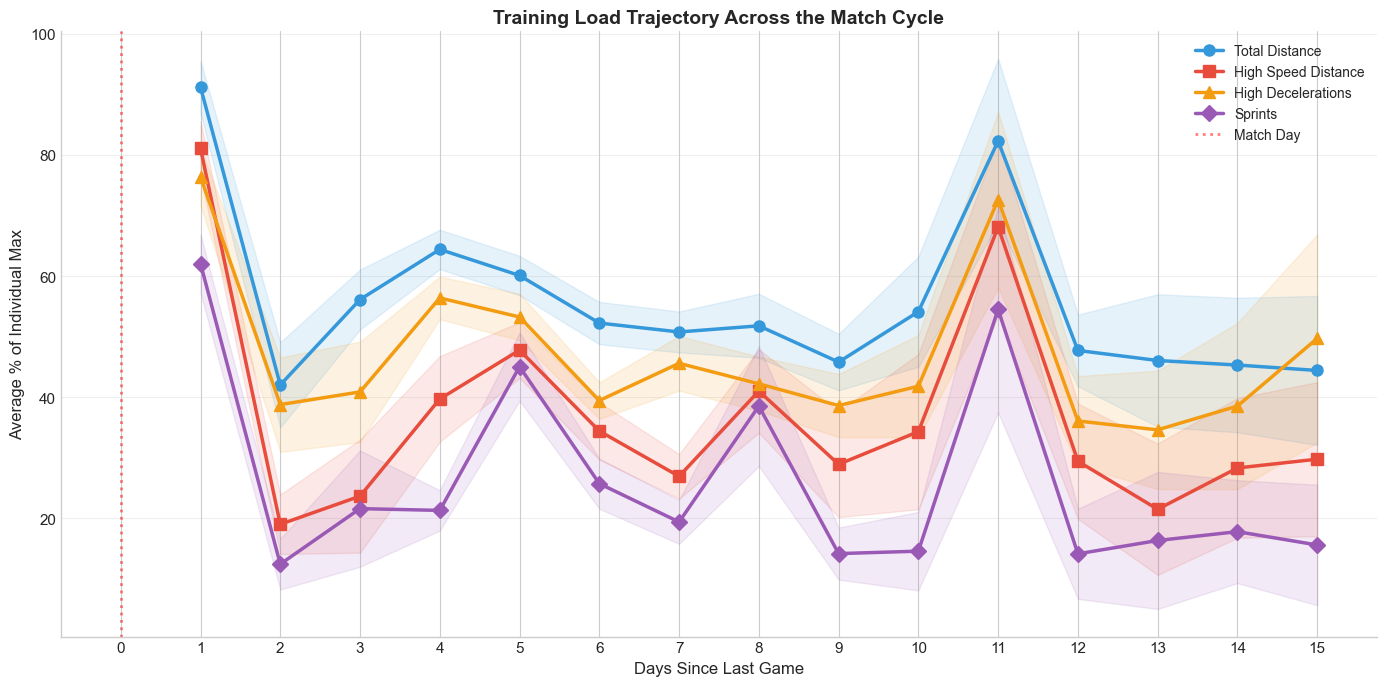

In [51]:
# GPS Load trajectory across the match cycle
fig, ax = plt.subplots(figsize=(14, 7))

gps_cycle_cols = ['Total Distance % Yesterday', 'High Speed Distance % Yesterday',
                  'High Decelerations % Yesterday', 'Sprints % Yesterday']
gps_cycle_colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
markers = ['o', 's', '^', 'D']

for col, color, marker in zip(gps_cycle_cols, gps_cycle_colors, markers):
    grouped = df_cycle.groupby('Days Since Game')[col]
    means = grouped.mean()
    sems = grouped.sem()
    
    short = col.replace(' % Yesterday', '').replace(' Yesterday', '')
    ax.plot(means.index, means.values, color=color, marker=marker, markersize=8,
            linewidth=2.5, label=short, zorder=3)
    ax.fill_between(means.index,
                    (means - 1.96 * sems).values,
                    (means + 1.96 * sems).values,
                    color=color, alpha=0.12)

ax.axvline(x=0, color='red', linestyle=':', linewidth=2, alpha=0.5, label='Match Day')
ax.set_xlabel('Days Since Last Game', fontsize=12)
ax.set_ylabel('Average % of Individual Max', fontsize=12)
ax.set_title('Training Load Trajectory Across the Match Cycle', fontsize=14, fontweight='bold')
ax.set_xticks(range(16))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

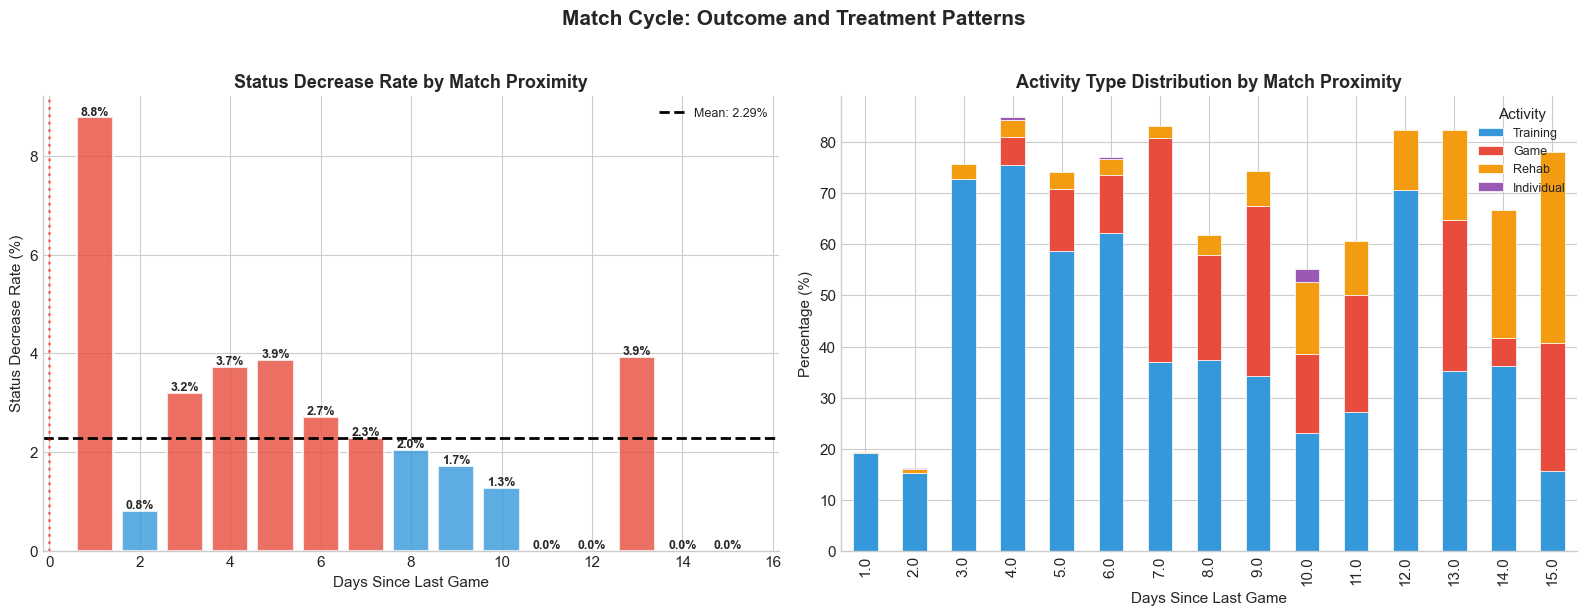

In [52]:
# Status Decrease rate by Days Since Game
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Status Decrease rate
ax = axes[0]
decrease_by_days = df_cycle.groupby('Days Since Game')['Status Decrease'].agg(['sum', 'count', 'mean'])
decrease_by_days['rate'] = decrease_by_days['mean'] * 100

bars = ax.bar(decrease_by_days.index, decrease_by_days['rate'].values,
              color=[COLORS['secondary'] if r > decrease_by_days['rate'].mean() else COLORS['primary']
                     for r in decrease_by_days['rate'].values],
              alpha=0.8, edgecolor='white', linewidth=1.5)

ax.axhline(y=decrease_by_days['rate'].mean(), color='black', linestyle='--', linewidth=2,
           label=f"Mean: {decrease_by_days['rate'].mean():.2f}%")
ax.axvline(x=0, color='red', linestyle=':', linewidth=2, alpha=0.5)

for bar, val, n in zip(bars, decrease_by_days['rate'].values, decrease_by_days['sum'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Days Since Last Game', fontsize=11)
ax.set_ylabel('Status Decrease Rate (%)', fontsize=11)
ax.set_title('Status Decrease Rate by Match Proximity', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Right: Activity Type distribution by Days Since Game
ax = axes[1]
activity_by_days = pd.crosstab(df_cycle['Days Since Game'], df_cycle['Activity Type Today'], normalize='index') * 100
top_activities = ['Training', 'Game', 'Rehab', 'Individual']
activity_by_days_filtered = activity_by_days[[c for c in top_activities if c in activity_by_days.columns]]

activity_by_days_filtered.plot(kind='bar', stacked=True, ax=ax,
                                color=[ACTIVITY_COLORS.get(c, '#bdc3c7') for c in activity_by_days_filtered.columns],
                                edgecolor='white', linewidth=0.5)
ax.set_xlabel('Days Since Last Game', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Activity Type Distribution by Match Proximity', fontsize=13, fontweight='bold')
ax.legend(title='Activity', fontsize=9, loc='upper right')

plt.suptitle('Match Cycle: Outcome and Treatment Patterns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

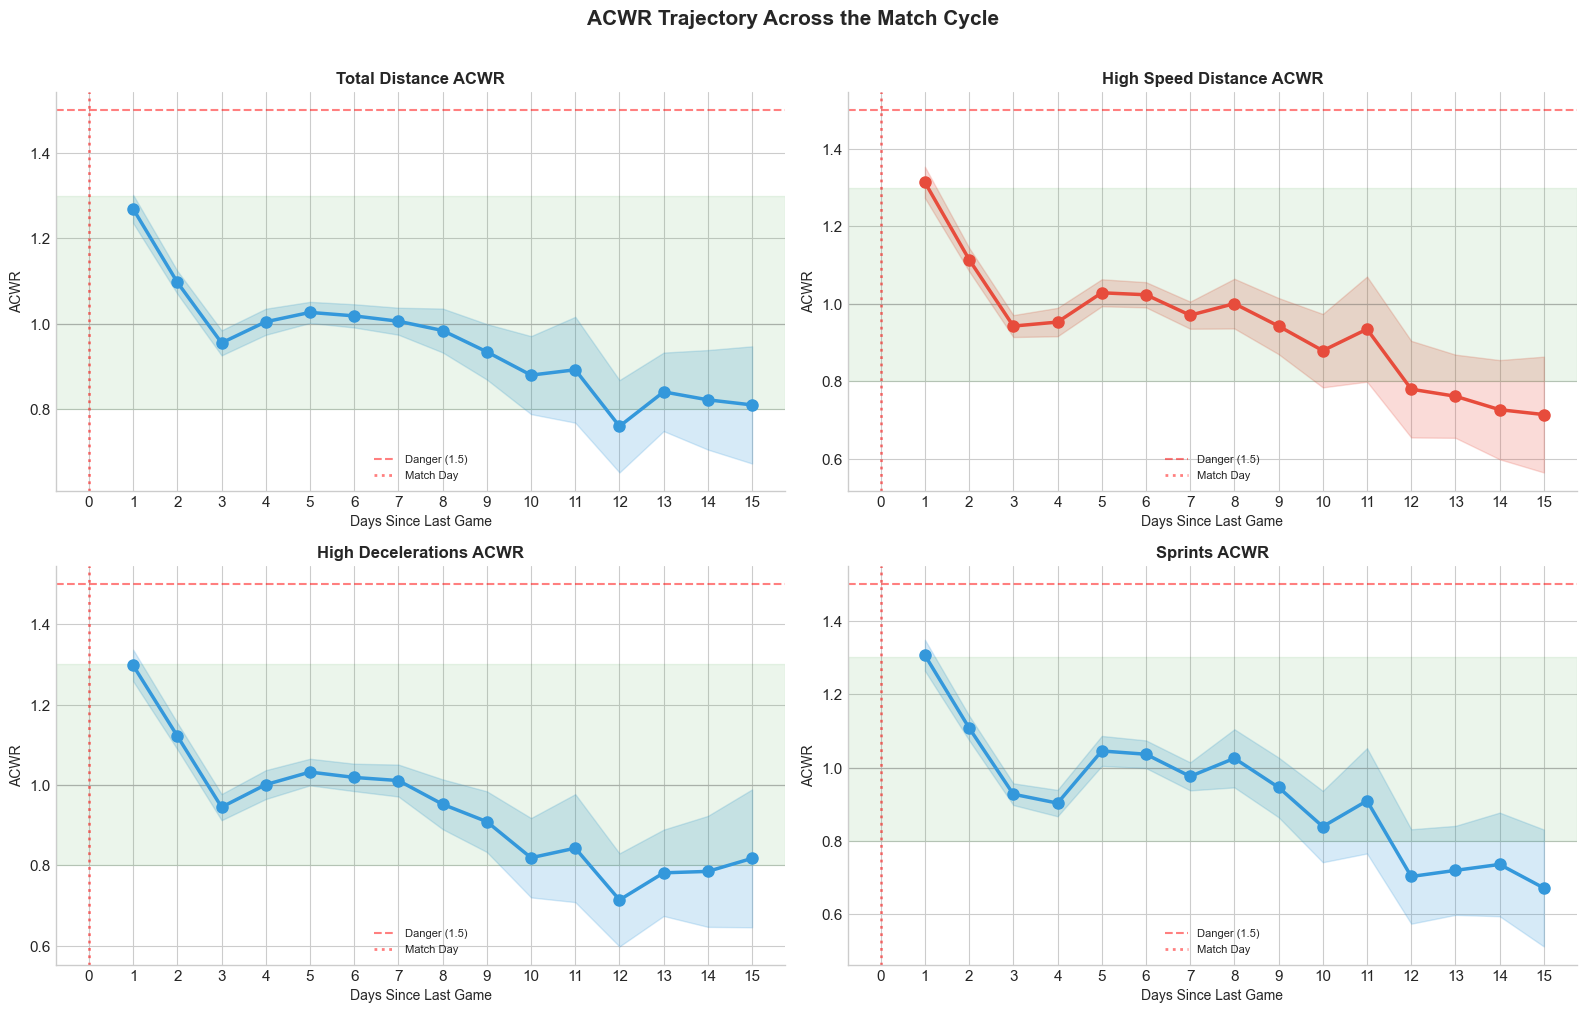

In [53]:
# ACWR trajectory across the match cycle
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col, color in zip(axes, acwr_cols, acwr_colors):
    grouped = df_cycle.groupby('Days Since Game')[col]
    means = grouped.mean()
    sems = grouped.sem()
    
    ax.plot(means.index, means.values, color=color, marker='o', markersize=8,
            linewidth=2.5, zorder=3)
    ax.fill_between(means.index,
                    (means - 1.96 * sems).values,
                    (means + 1.96 * sems).values,
                    color=color, alpha=0.2)
    
    # Reference zones
    ax.axhspan(0.8, 1.3, alpha=0.08, color='green')
    ax.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Danger (1.5)')
    ax.axhline(y=1.0, color='grey', linestyle='-', linewidth=1, alpha=0.3)
    ax.axvline(x=0, color='red', linestyle=':', linewidth=2, alpha=0.5, label='Match Day')
    
    short = col.replace(' (ACWR) Yesterday', '')
    ax.set_title(f'{short} ACWR', fontsize=12, fontweight='bold')
    ax.set_xlabel('Days Since Last Game', fontsize=10)
    ax.set_ylabel('ACWR', fontsize=10)
    ax.set_xticks(range(16))
    ax.legend(fontsize=8)

plt.suptitle('ACWR Trajectory Across the Match Cycle', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 15. Comment Category Analysis

Player comments can signal early warning signs (discomfort, stiffness, sickness). Understanding comment patterns is relevant for predicting status transitions.

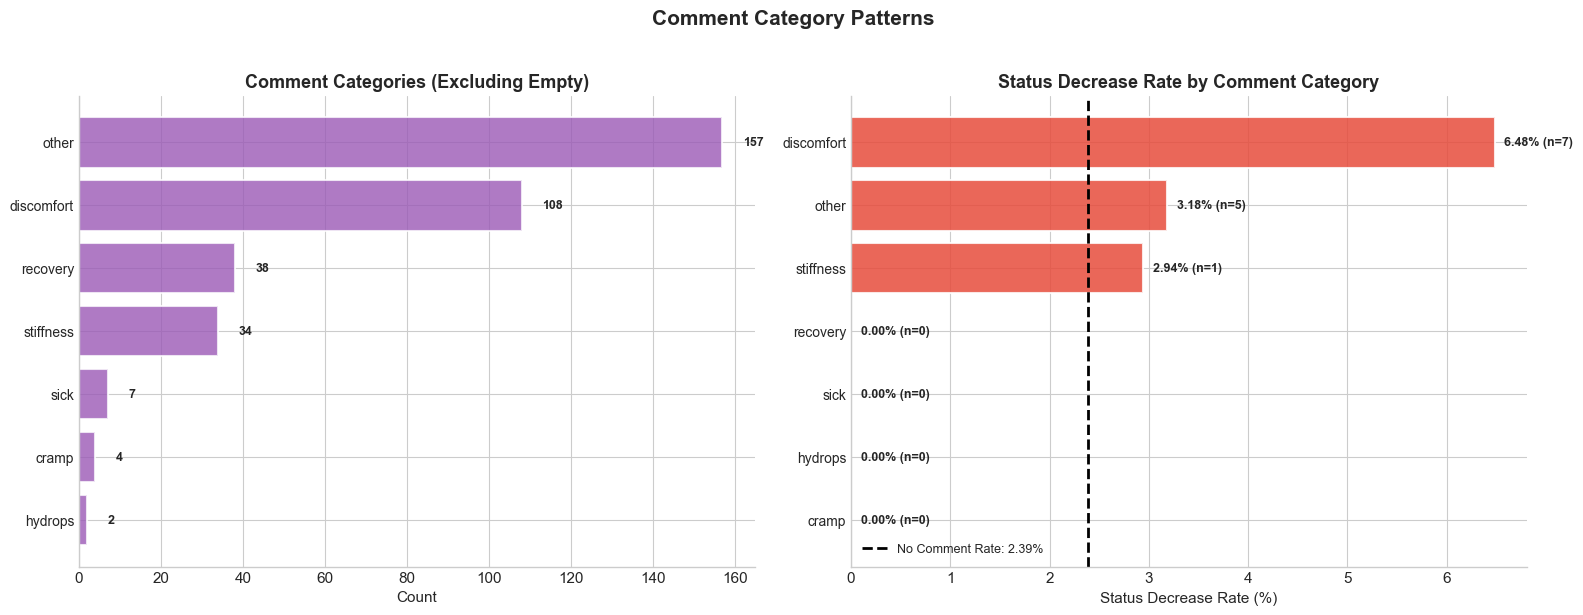

In [54]:
# Comment Category analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Comment category distribution
ax = axes[0]
comment_dist = df['Comment Category Yesterday'].value_counts()
comment_dist = comment_dist[comment_dist.index != 'empty']  # Exclude empty
bars = ax.barh(range(len(comment_dist)), comment_dist.values,
               color=COLORS['info'], alpha=0.8, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(comment_dist)))
ax.set_yticklabels(comment_dist.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Count', fontsize=11)
ax.set_title('Comment Categories (Excluding Empty)', fontsize=13, fontweight='bold')
for i, val in enumerate(comment_dist.values):
    ax.text(val + 5, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

# Right: Status Decrease rate by comment category
ax = axes[1]
comment_categories = df[df['Comment Category Yesterday'] != 'empty'].copy()
decrease_by_comment = comment_categories.groupby('Comment Category Yesterday')['Status Decrease'].agg(['sum', 'count', 'mean'])
decrease_by_comment['rate'] = decrease_by_comment['mean'] * 100
decrease_by_comment = decrease_by_comment.sort_values('rate', ascending=True)

# Include 'empty' for reference
empty_rate = df[df['Comment Category Yesterday'] == 'empty']['Status Decrease'].mean() * 100

colors_comment = [COLORS['secondary'] if r > empty_rate else COLORS['primary'] 
                  for r in decrease_by_comment['rate'].values]
bars = ax.barh(range(len(decrease_by_comment)), decrease_by_comment['rate'].values,
               color=colors_comment, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(decrease_by_comment)))
ax.set_yticklabels(decrease_by_comment.index, fontsize=10)
ax.axvline(x=empty_rate, color='black', linestyle='--', linewidth=2,
           label=f'No Comment Rate: {empty_rate:.2f}%')
for i, (val, n) in enumerate(zip(decrease_by_comment['rate'].values, decrease_by_comment['sum'].values)):
    ax.text(val + 0.1, i, f'{val:.2f}% (n={int(n)})', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Status Decrease Rate (%)', fontsize=11)
ax.set_title('Status Decrease Rate by Comment Category', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Comment Category Patterns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 16. Days Until Match Analysis

The `Days Until Match` variable captures where we are in the weekly microcycle. It is 0 on match day and counts down from the previous match. This is a key feature for understanding load periodization.

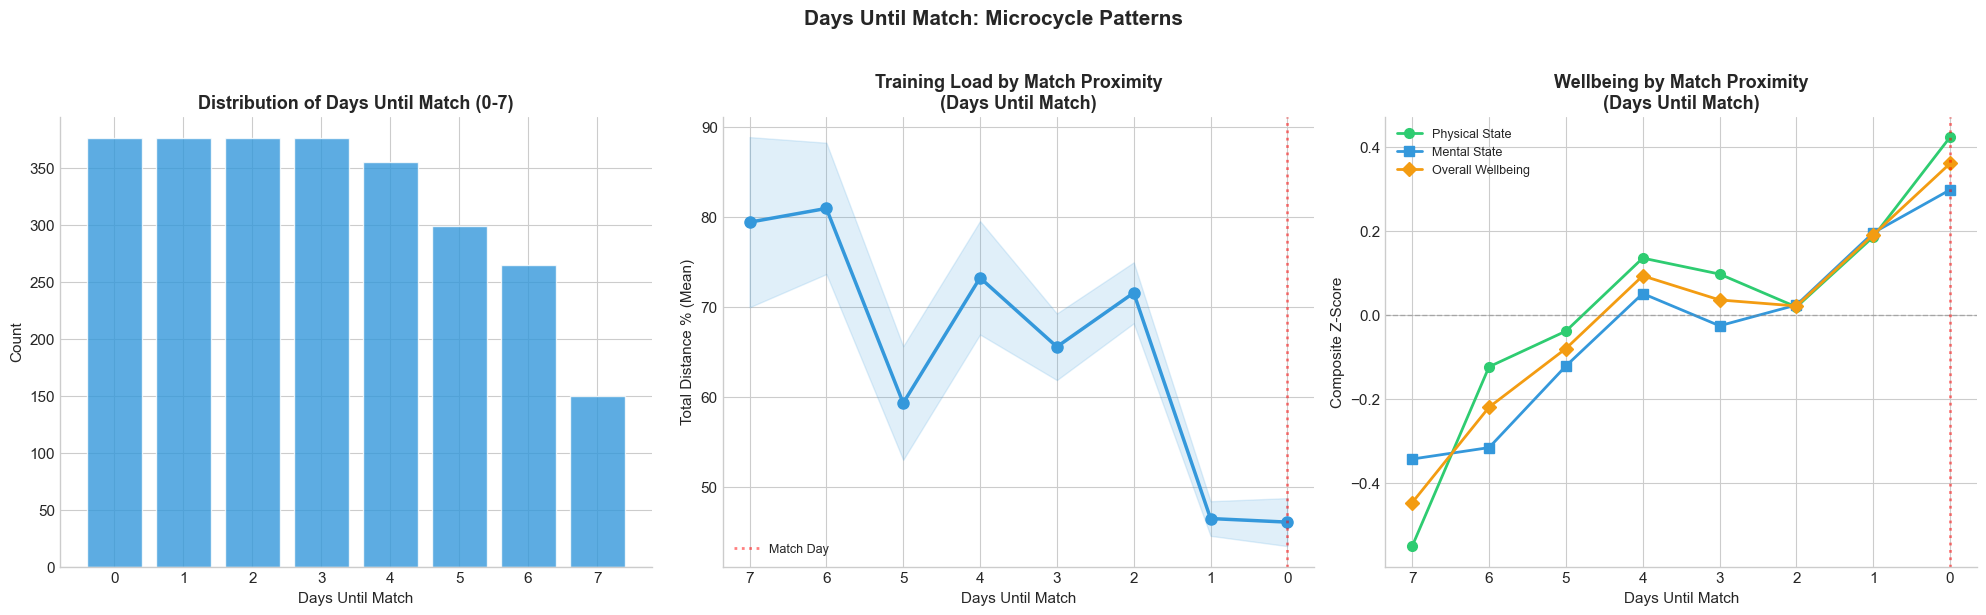

In [55]:
# Days Until Match distribution and relationship with training load
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Filter to typical microcycle (0-7 days until match)
df_microcycle = df[df['Days Until Match'].between(0, 7)].copy()

# Left: Distribution of Days Until Match
ax = axes[0]
dum_counts = df_microcycle['Days Until Match'].value_counts().sort_index()
bars = ax.bar(dum_counts.index, dum_counts.values, color=COLORS['primary'], alpha=0.8, edgecolor='white')
ax.set_xlabel('Days Until Match', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Days Until Match (0-7)', fontsize=13, fontweight='bold')
ax.set_xticks(range(8))

# Middle: Average Total Distance % by Days Until Match
ax = axes[1]
grouped_load = df_microcycle.groupby('Days Until Match')['Total Distance % Yesterday']
means = grouped_load.mean()
sems = grouped_load.sem()

ax.plot(means.index, means.values, 'o-', color=COLORS['primary'], linewidth=2.5, markersize=8)
ax.fill_between(means.index, (means - 1.96*sems).values, (means + 1.96*sems).values,
                color=COLORS['primary'], alpha=0.15)
ax.axvline(x=0, color='red', linestyle=':', linewidth=2, alpha=0.5, label='Match Day')
ax.set_xlabel('Days Until Match', fontsize=11)
ax.set_ylabel('Total Distance % (Mean)', fontsize=11)
ax.set_title('Training Load by Match Proximity\n(Days Until Match)', fontsize=13, fontweight='bold')
ax.set_xticks(range(8))
ax.legend(fontsize=9)
ax.invert_xaxis()  # Match day (0) on the right

# Right: Wellbeing by Days Until Match
ax = axes[2]
for col, color, marker in zip(
    ['Physical State', 'Mental State', 'Overall Wellbeing'],
    [COLORS['success'], COLORS['primary'], COLORS['warning']],
    ['o', 's', 'D']
):
    grouped = df_microcycle.groupby('Days Until Match')[col]
    means = grouped.mean()
    ax.plot(means.index, means.values, marker=marker, color=color, linewidth=2, markersize=7, label=col)

ax.axhline(y=0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='red', linestyle=':', linewidth=2, alpha=0.5)
ax.set_xlabel('Days Until Match', fontsize=11)
ax.set_ylabel('Composite Z-Score', fontsize=11)
ax.set_title('Wellbeing by Match Proximity\n(Days Until Match)', fontsize=13, fontweight='bold')
ax.set_xticks(range(8))
ax.legend(fontsize=9)
ax.invert_xaxis()

plt.suptitle('Days Until Match: Microcycle Patterns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

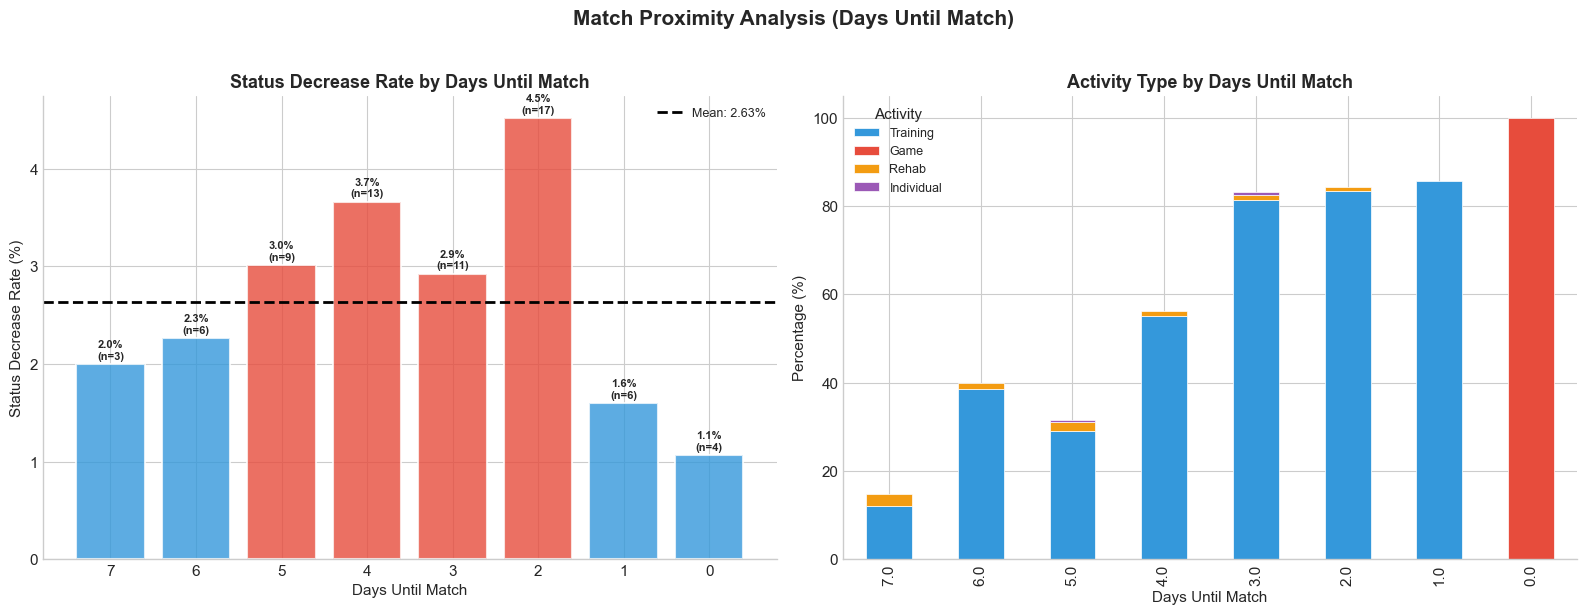

In [56]:
# Status Decrease rate and Activity Type by Days Until Match
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Status Decrease rate by Days Until Match
ax = axes[0]
decrease_by_dum = df_microcycle.groupby('Days Until Match')['Status Decrease'].agg(['sum', 'count', 'mean'])
decrease_by_dum['rate'] = decrease_by_dum['mean'] * 100

bars = ax.bar(decrease_by_dum.index, decrease_by_dum['rate'].values,
              color=[COLORS['secondary'] if r > decrease_by_dum['rate'].mean() else COLORS['primary']
                     for r in decrease_by_dum['rate'].values],
              alpha=0.8, edgecolor='white', linewidth=1.5)

ax.axhline(y=decrease_by_dum['rate'].mean(), color='black', linestyle='--', linewidth=2,
           label=f"Mean: {decrease_by_dum['rate'].mean():.2f}%")

for bar, val, n in zip(bars, decrease_by_dum['rate'].values, decrease_by_dum['sum'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}%\n(n={int(n)})', ha='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Days Until Match', fontsize=11)
ax.set_ylabel('Status Decrease Rate (%)', fontsize=11)
ax.set_title('Status Decrease Rate by Days Until Match', fontsize=13, fontweight='bold')
ax.set_xticks(range(8))
ax.invert_xaxis()
ax.legend(fontsize=9)

# Right: Activity Type distribution by Days Until Match
ax = axes[1]
act_by_dum = pd.crosstab(df_microcycle['Days Until Match'], df_microcycle['Activity Type Today'], normalize='index') * 100
top_acts = ['Training', 'Game', 'Rehab', 'Individual']
act_by_dum_filt = act_by_dum[[c for c in top_acts if c in act_by_dum.columns]]
act_by_dum_filt.plot(kind='bar', stacked=True, ax=ax,
                      color=[ACTIVITY_COLORS.get(c, '#bdc3c7') for c in act_by_dum_filt.columns],
                      edgecolor='white', linewidth=0.5)
ax.set_xlabel('Days Until Match', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Activity Type by Days Until Match', fontsize=13, fontweight='bold')
ax.legend(title='Activity', fontsize=9)
ax.invert_xaxis()

plt.suptitle('Match Proximity Analysis (Days Until Match)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 17. Match Day Analysis

Deep dive into match days using the preprocessed `Match Day` and `Selected` columns.
Match Day is a team-level binary (1 if any player has a game on that date), and Selected
is player-level (1 = selected for match, 0 = not selected, NaN = no match day).

Analyses include: match scheduling, player selection patterns, activity distribution on
match days, individual player match participation, workload on match days, and post-match recovery.

In [57]:
# Identify match days using preprocessed Match Day column
match_dates = sorted(df[df['Match Day'] == 1]['Date'].unique())

print(f"Total match days identified: {len(match_dates)}")
print(f"Date range: {match_dates[0].strftime('%Y-%m-%d')} to {match_dates[-1].strftime('%Y-%m-%d')}")
print(f"\nMatch days:")
for i, d in enumerate(match_dates):
    day_name = d.strftime('%A')
    n_selected = df[(df['Date'] == d) & (df['Selected'] == 1)].shape[0]
    n_not_selected = df[(df['Date'] == d) & (df['Selected'] == 0)].shape[0]
    n_total = df[df['Date'] == d].shape[0]
    print(f"  {i+1}. {d.strftime('%Y-%m-%d')} ({day_name}) — {n_selected} selected, {n_not_selected} not selected, {n_total} total")

Total match days identified: 22
Date range: 2025-06-28 to 2025-11-23

Match days:
  1. 2025-06-28 (Saturday) — 15 selected, 4 not selected, 27 total
  2. 2025-07-02 (Wednesday) — 13 selected, 6 not selected, 27 total
  3. 2025-07-13 (Sunday) — 17 selected, 3 not selected, 27 total
  4. 2025-07-20 (Sunday) — 17 selected, 4 not selected, 27 total
  5. 2025-07-27 (Sunday) — 17 selected, 5 not selected, 27 total
  6. 2025-08-03 (Sunday) — 17 selected, 5 not selected, 27 total
  7. 2025-08-10 (Sunday) — 18 selected, 4 not selected, 27 total
  8. 2025-08-15 (Friday) — 17 selected, 5 not selected, 27 total
  9. 2025-08-24 (Sunday) — 19 selected, 4 not selected, 27 total
  10. 2025-08-31 (Sunday) — 19 selected, 5 not selected, 27 total
  11. 2025-09-04 (Thursday) — 11 selected, 13 not selected, 27 total
  12. 2025-09-13 (Saturday) — 18 selected, 8 not selected, 27 total
  13. 2025-09-20 (Saturday) — 19 selected, 7 not selected, 27 total
  14. 2025-09-26 (Friday) — 18 selected, 7 not selected, 

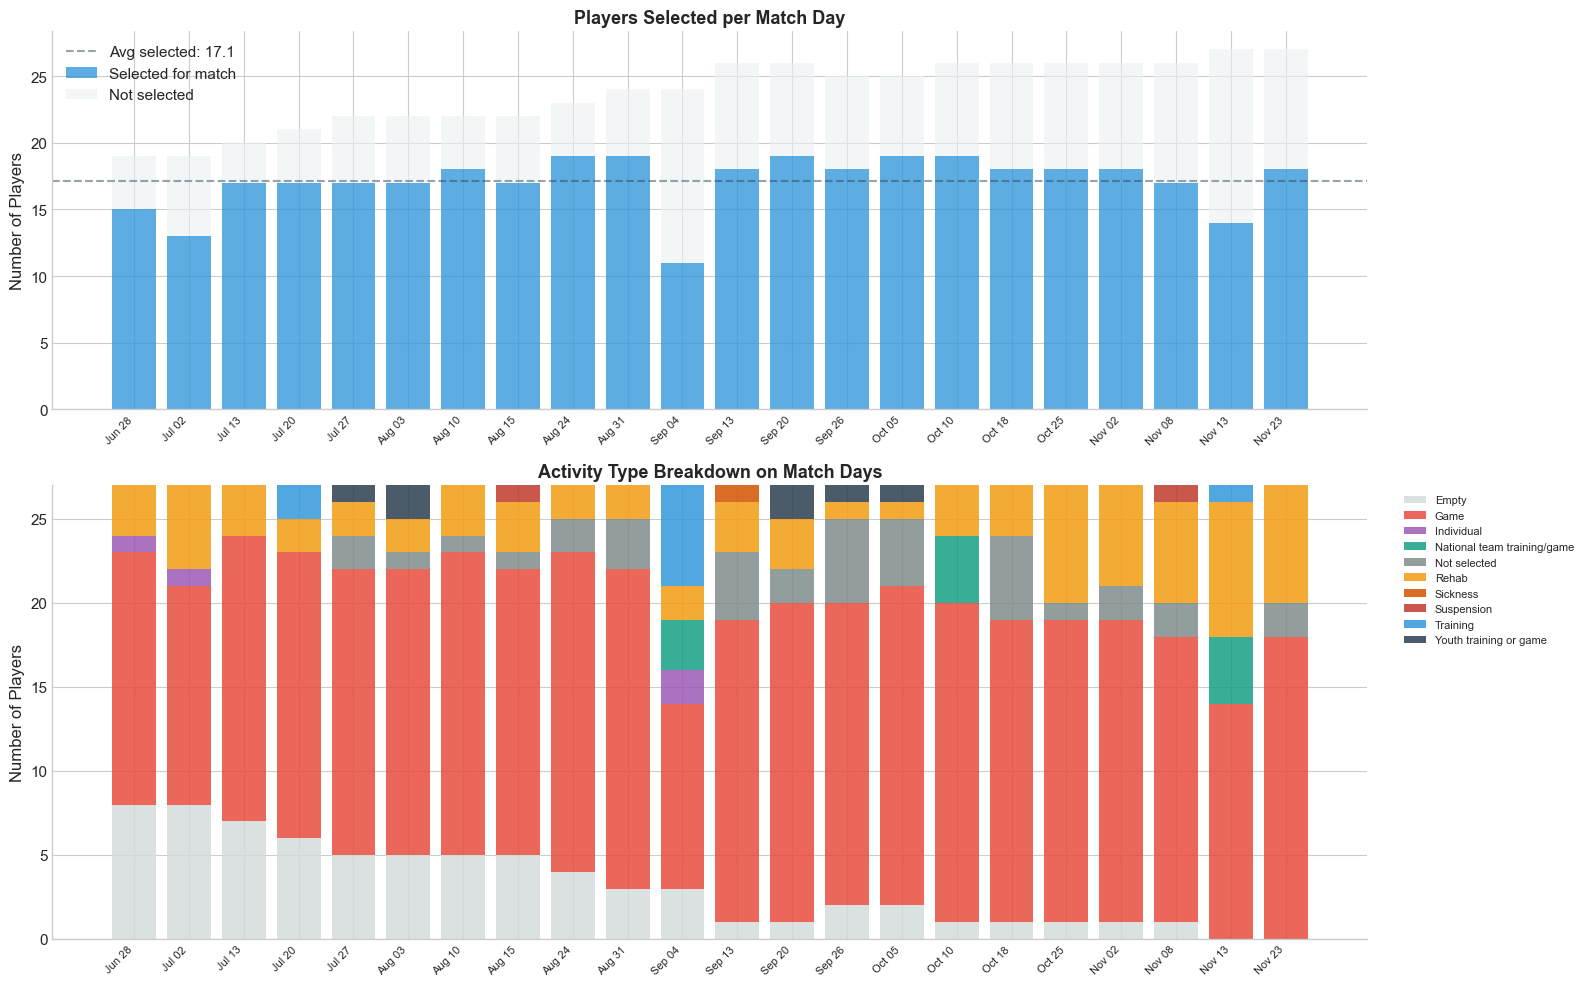

In [58]:
# Match day overview: players selected per match + activity breakdown
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [1, 1.2]})

# Top: Number of players selected for each match
match_day_data = []
for d in match_dates:
    day_df = df[df['Date'] == d]
    n_selected = (day_df['Selected'] == 1).sum()
    n_not_selected = (day_df['Selected'] == 0).sum()
    match_day_data.append({
        'Date': d,
        'Selected': n_selected,
        'Not Selected': n_not_selected,
        'Total Players': len(day_df),
        'Label': d.strftime('%b %d')
    })
match_summary = pd.DataFrame(match_day_data)

ax = axes[0]
ax.bar(range(len(match_summary)), match_summary['Selected'],
       color=SELECTION_COLORS['selected'], alpha=0.8, label='Selected for match')
ax.bar(range(len(match_summary)), match_summary['Not Selected'],
       bottom=match_summary['Selected'], color=COLORS['light'], alpha=0.6, label='Not selected')
ax.set_xticks(range(len(match_summary)))
ax.set_xticklabels(match_summary['Label'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Number of Players')
ax.set_title('Players Selected per Match Day', fontsize=13, fontweight='bold')
ax.axhline(y=match_summary['Selected'].mean(), color=COLORS['dark'], linestyle='--', alpha=0.5,
           label=f'Avg selected: {match_summary["Selected"].mean():.1f}')
ax.legend()

# Bottom: Activity type breakdown on match days (stacked)
ax = axes[1]
activity_types_on_matchdays = []
for d in match_dates:
    day_df = df[df['Date'] == d]
    for act_type in day_df['Activity Type Today'].unique():
        count = (day_df['Activity Type Today'] == act_type).sum()
        activity_types_on_matchdays.append({'Date': d, 'Activity': act_type, 'Count': count})

act_df = pd.DataFrame(activity_types_on_matchdays)
if len(act_df) > 0:
    act_pivot = act_df.pivot_table(index='Date', columns='Activity', values='Count', fill_value=0)
    act_pivot = act_pivot.reindex(match_dates)

    bottom = np.zeros(len(match_dates))
    for col in act_pivot.columns:
        color = ACTIVITY_COLORS.get(col, '#bdc3c7')
        ax.bar(range(len(match_dates)), act_pivot[col].values, bottom=bottom,
               label=col, color=color, alpha=0.85)
        bottom += act_pivot[col].values

    ax.set_xticks(range(len(match_dates)))
    ax.set_xticklabels([d.strftime('%b %d') for d in match_dates], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Number of Players')
    ax.set_title('Activity Type Breakdown on Match Days', fontsize=13, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

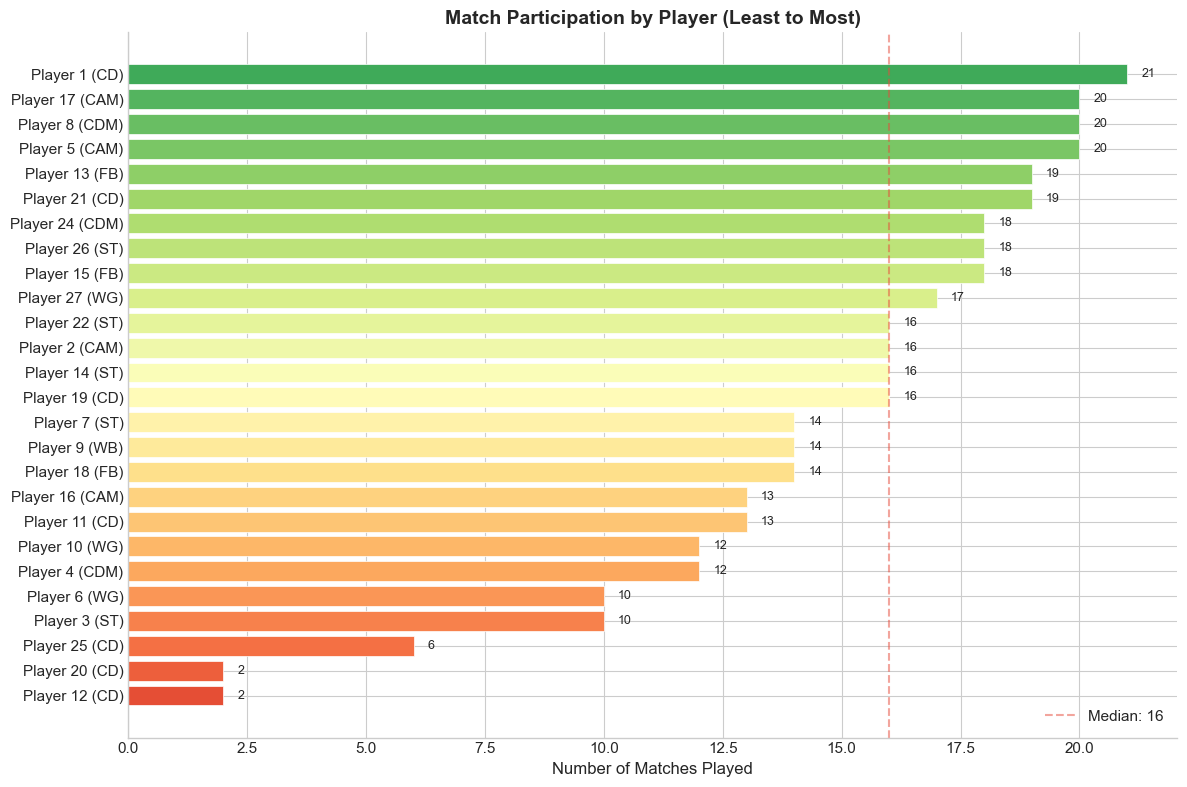


Match participation statistics:
  Total matches: 22
  Avg players per match: 17.1
  Most matches: Player 1 with 21
  Fewest matches: Player 12 with 2


In [59]:
# Player match participation ranking: who played the most/least matches?
player_match_counts = df[df['Selected'] == 1].groupby(['Player ID', 'Position']).size().reset_index(name='Matches Played')
player_match_counts = player_match_counts.sort_values('Matches Played', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(player_match_counts)))
bars = ax.barh(
    [f"Player {int(row['Player ID'])} ({row['Position']})" for _, row in player_match_counts.iterrows()],
    player_match_counts['Matches Played'],
    color=colors, edgecolor='white', linewidth=0.5
)

# Add count labels
for bar, count in zip(bars, player_match_counts['Matches Played']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(count),
            va='center', fontsize=9)

ax.set_xlabel('Number of Matches Played')
ax.set_title('Match Participation by Player (Least to Most)', fontsize=14, fontweight='bold')
ax.axvline(x=player_match_counts['Matches Played'].median(), color=COLORS['secondary'], linestyle='--',
           alpha=0.5, label=f'Median: {player_match_counts["Matches Played"].median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMatch participation statistics:")
print(f"  Total matches: {len(match_dates)}")
print(f"  Avg players per match: {player_match_counts['Matches Played'].sum() / len(match_dates):.1f}")
print(f"  Most matches: Player {int(player_match_counts.iloc[-1]['Player ID'])} with {player_match_counts.iloc[-1]['Matches Played']}")
print(f"  Fewest matches: Player {int(player_match_counts.iloc[0]['Player ID'])} with {player_match_counts.iloc[0]['Matches Played']}")

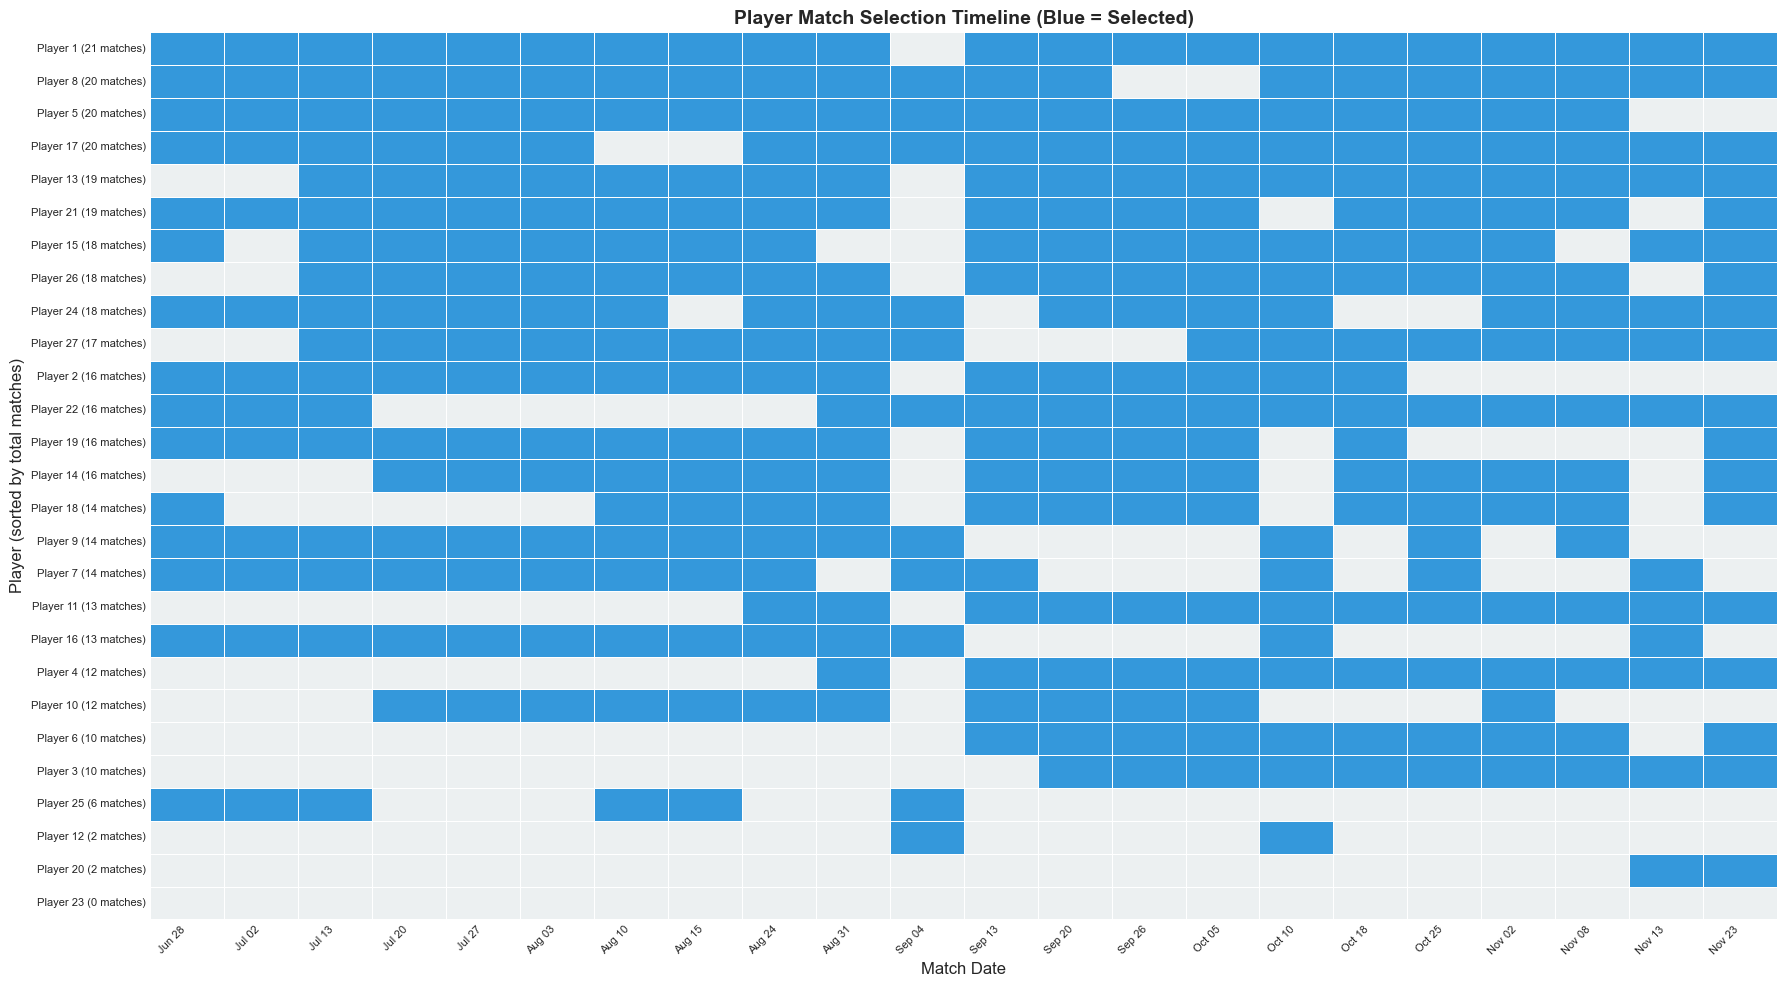

In [60]:
# Player-by-match selection timeline: Gantt-style heatmap using Selected column
all_players = sorted(df['Player ID'].unique())
player_match_matrix = pd.DataFrame(index=all_players, columns=match_dates, dtype=float)
player_match_matrix[:] = 0  # default: not selected

for d in match_dates:
    selected_players = df[(df['Date'] == d) & (df['Selected'] == 1)]['Player ID'].unique()
    for p in selected_players:
        player_match_matrix.loc[p, d] = 1

# Sort players by total matches played
player_match_matrix['Total'] = player_match_matrix.sum(axis=1)
player_match_matrix = player_match_matrix.sort_values('Total', ascending=False)
total_col = player_match_matrix.pop('Total')

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(player_match_matrix.astype(float),
            cmap=[COLORS['light'], SELECTION_COLORS['selected']],
            linewidths=0.5, linecolor='white', cbar=False, ax=ax,
            xticklabels=[d.strftime('%b %d') for d in match_dates],
            yticklabels=[f"Player {int(p)} ({total_col.loc[p]:.0f} matches)" for p in player_match_matrix.index])
ax.set_title('Player Match Selection Timeline (Blue = Selected)', fontsize=14, fontweight='bold')
ax.set_xlabel('Match Date')
ax.set_ylabel('Player (sorted by total matches)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

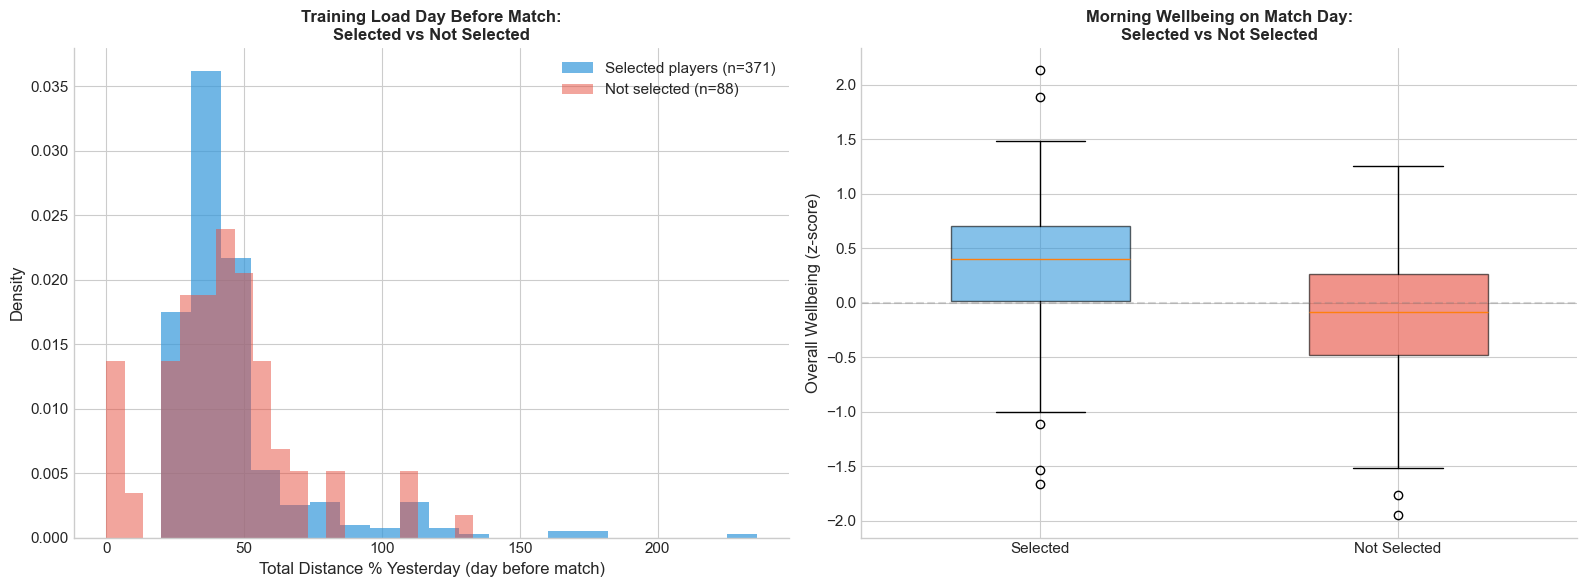

In [61]:
# GPS workload on match days: compare selected vs not-selected players
# Total Distance % Yesterday on match day rows = GPS from the day BEFORE the match

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gps_col = 'Total Distance % Yesterday'
matchday_df = df[df['Match Day'] == 1].copy()
selected_mask = matchday_df['Selected'] == 1

# Left: Distribution of day-before-match GPS load (selected vs not-selected)
ax = axes[0]
selected_load = matchday_df.loc[selected_mask, gps_col].dropna()
nonselected_load = matchday_df.loc[~selected_mask & matchday_df['Selected'].notna(), gps_col].dropna()

ax.hist(selected_load, bins=20, alpha=0.7, color=SELECTION_COLORS['selected'],
        label=f'Selected players (n={len(selected_load)})', density=True)
ax.hist(nonselected_load, bins=20, alpha=0.5, color=SELECTION_COLORS['not_selected'],
        label=f'Not selected (n={len(nonselected_load)})', density=True)
ax.set_xlabel('Total Distance % Yesterday (day before match)')
ax.set_ylabel('Density')
ax.set_title('Training Load Day Before Match:\nSelected vs Not Selected', fontsize=12, fontweight='bold')
ax.legend()

# Right: Wellbeing on match day morning for selected vs not-selected
ax = axes[1]
data_to_plot = [
    matchday_df.loc[selected_mask, 'Overall Wellbeing'].dropna(),
    matchday_df.loc[~selected_mask & matchday_df['Selected'].notna(), 'Overall Wellbeing'].dropna()
]
bp = ax.boxplot(data_to_plot, labels=['Selected', 'Not Selected'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor(SELECTION_COLORS['selected'])
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor(SELECTION_COLORS['not_selected'])
bp['boxes'][1].set_alpha(0.6)
ax.set_ylabel('Overall Wellbeing (z-score)')
ax.set_title('Morning Wellbeing on Match Day:\nSelected vs Not Selected', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

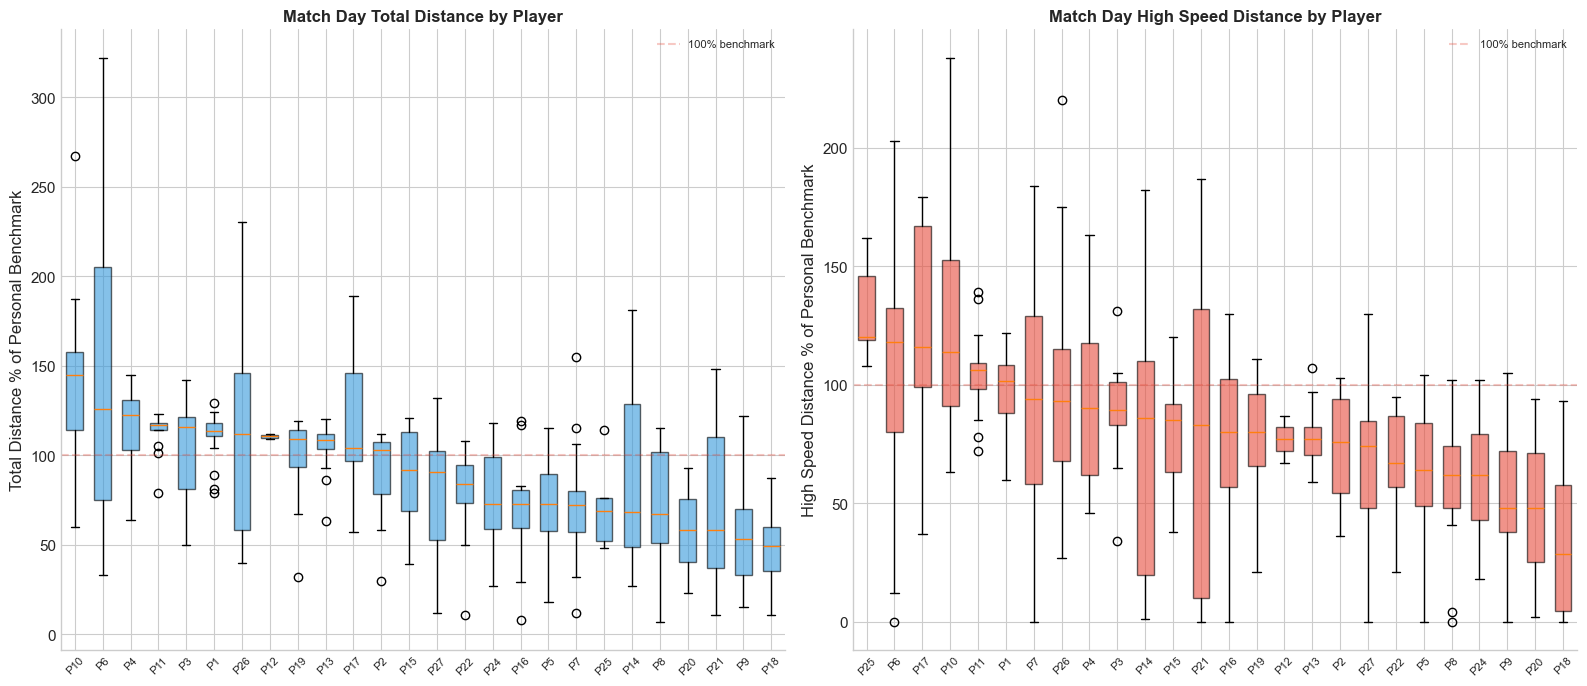

In [62]:
# Match day GPS workload per player: Total Distance and High Speed Distance
# Use shift(-1) to get NEXT day's "Yesterday" data = actual match-day GPS
df_sorted = df.sort_values(['Player ID', 'Date']).copy()
for gps_col_name in ['Total Distance % Yesterday', 'High Speed Distance % Yesterday']:
    df_sorted[f'{gps_col_name}_match_load'] = df_sorted.groupby('Player ID')[gps_col_name].shift(-1)

# Filter to match days only, selected players only
matchday_gps = df_sorted[
    (df_sorted['Match Day'] == 1) &
    (df_sorted['Selected'] == 1)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Total Distance % on match day per player (boxplot)
ax = axes[0]
player_order = matchday_gps.groupby('Player ID')['Total Distance % Yesterday_match_load'].median().sort_values(ascending=False).index
player_data = [matchday_gps[matchday_gps['Player ID'] == p]['Total Distance % Yesterday_match_load'].dropna().values
               for p in player_order]
bp = ax.boxplot(player_data, vert=True, patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor(GPS_COLORS['Total Distance % Yesterday'])
    patch.set_alpha(0.6)
ax.set_xticklabels([f'P{int(p)}' for p in player_order], rotation=45, fontsize=8)
ax.set_ylabel('Total Distance % of Personal Benchmark')
ax.set_title('Match Day Total Distance by Player', fontsize=12, fontweight='bold')
ax.axhline(y=100, color=COLORS['secondary'], linestyle='--', alpha=0.3, label='100% benchmark')
ax.legend(fontsize=8)

# Right: High Speed Distance % on match day per player
ax = axes[1]
player_order_hsd = matchday_gps.groupby('Player ID')['High Speed Distance % Yesterday_match_load'].median().sort_values(ascending=False).index
player_data_hsd = [matchday_gps[matchday_gps['Player ID'] == p]['High Speed Distance % Yesterday_match_load'].dropna().values
                   for p in player_order_hsd]
bp2 = ax.boxplot(player_data_hsd, vert=True, patch_artist=True, widths=0.6)
for patch in bp2['boxes']:
    patch.set_facecolor(GPS_COLORS['High Speed Distance % Yesterday'])
    patch.set_alpha(0.6)
ax.set_xticklabels([f'P{int(p)}' for p in player_order_hsd], rotation=45, fontsize=8)
ax.set_ylabel('High Speed Distance % of Personal Benchmark')
ax.set_title('Match Day High Speed Distance by Player', fontsize=12, fontweight='bold')
ax.axhline(y=100, color=COLORS['secondary'], linestyle='--', alpha=0.3, label='100% benchmark')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

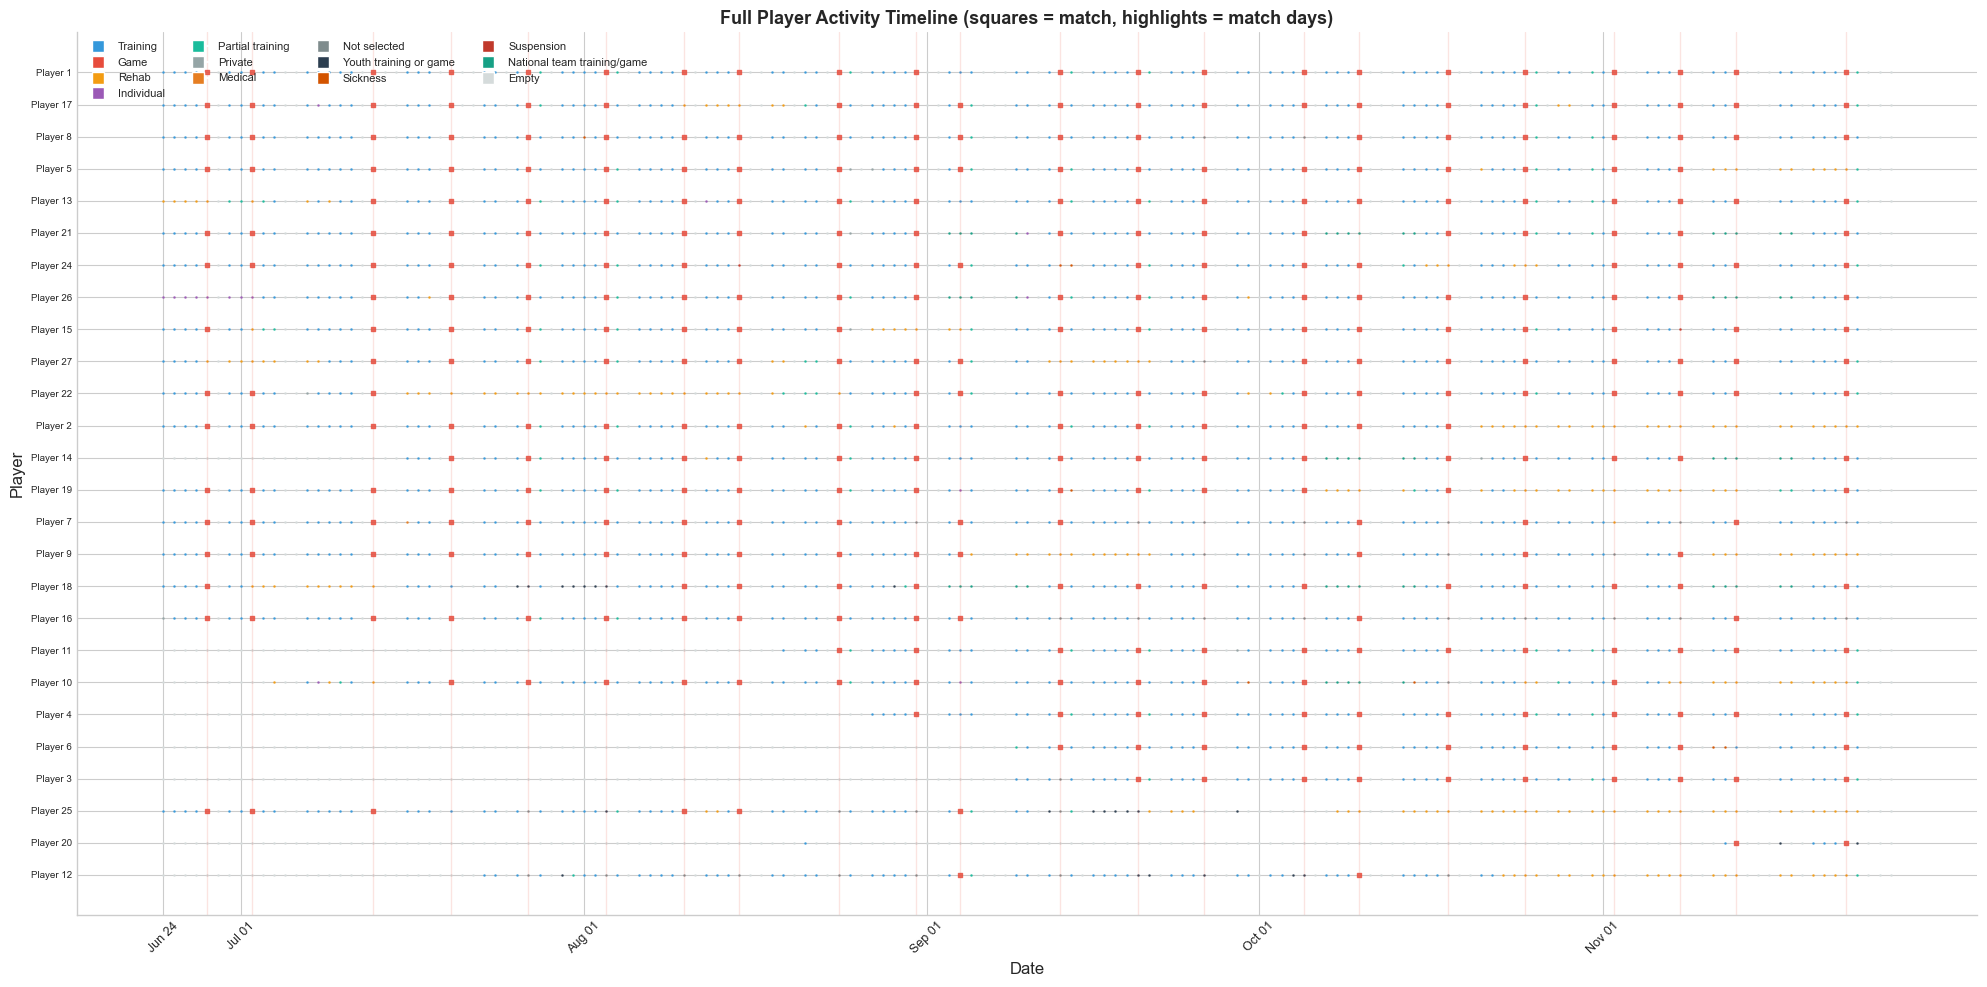

In [63]:
# Per-player match timeline: for each player, show all dates and color by activity type
fig, ax = plt.subplots(figsize=(20, 10))

# Sort players by match count
player_order_timeline = player_match_counts.sort_values('Matches Played', ascending=True)['Player ID'].values

all_dates = sorted(df['Date'].unique())
date_to_x = {d: i for i, d in enumerate(all_dates)}

for y_idx, player_id in enumerate(player_order_timeline):
    player_df = df[df['Player ID'] == player_id]
    for _, row in player_df.iterrows():
        act = row['Activity Type Today']
        x = date_to_x.get(row['Date'], None)
        if x is None:
            continue
        color = ACTIVITY_COLORS.get(act, '#bdc3c7')
        # Make match days larger
        size = 12 if act == 'Game' else 3
        marker = 's' if act == 'Game' else '.'
        ax.scatter(x, y_idx, c=color, s=size, marker=marker, alpha=0.8)

# Add vertical lines for match days
for d in match_dates:
    x = date_to_x[d]
    ax.axvline(x=x, color=ACTIVITY_COLORS['Game'], alpha=0.15, linewidth=1)

ax.set_yticks(range(len(player_order_timeline)))
ax.set_yticklabels([f'Player {int(p)}' for p in player_order_timeline], fontsize=7)

# X-axis: show monthly ticks
month_ticks = []
month_labels = []
for i, d in enumerate(all_dates):
    if d.day == 1 or i == 0:
        month_ticks.append(i)
        month_labels.append(d.strftime('%b %d'))
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, rotation=45, fontsize=9)

ax.set_title('Full Player Activity Timeline (squares = match, highlights = match days)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Player')

# Custom legend using centralized ACTIVITY_COLORS
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='s', color='w', markerfacecolor=c, markersize=8, label=k)
                   for k, c in ACTIVITY_COLORS.items() if k in df['Activity Type Today'].unique()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8, ncol=4)
plt.tight_layout()
plt.show()

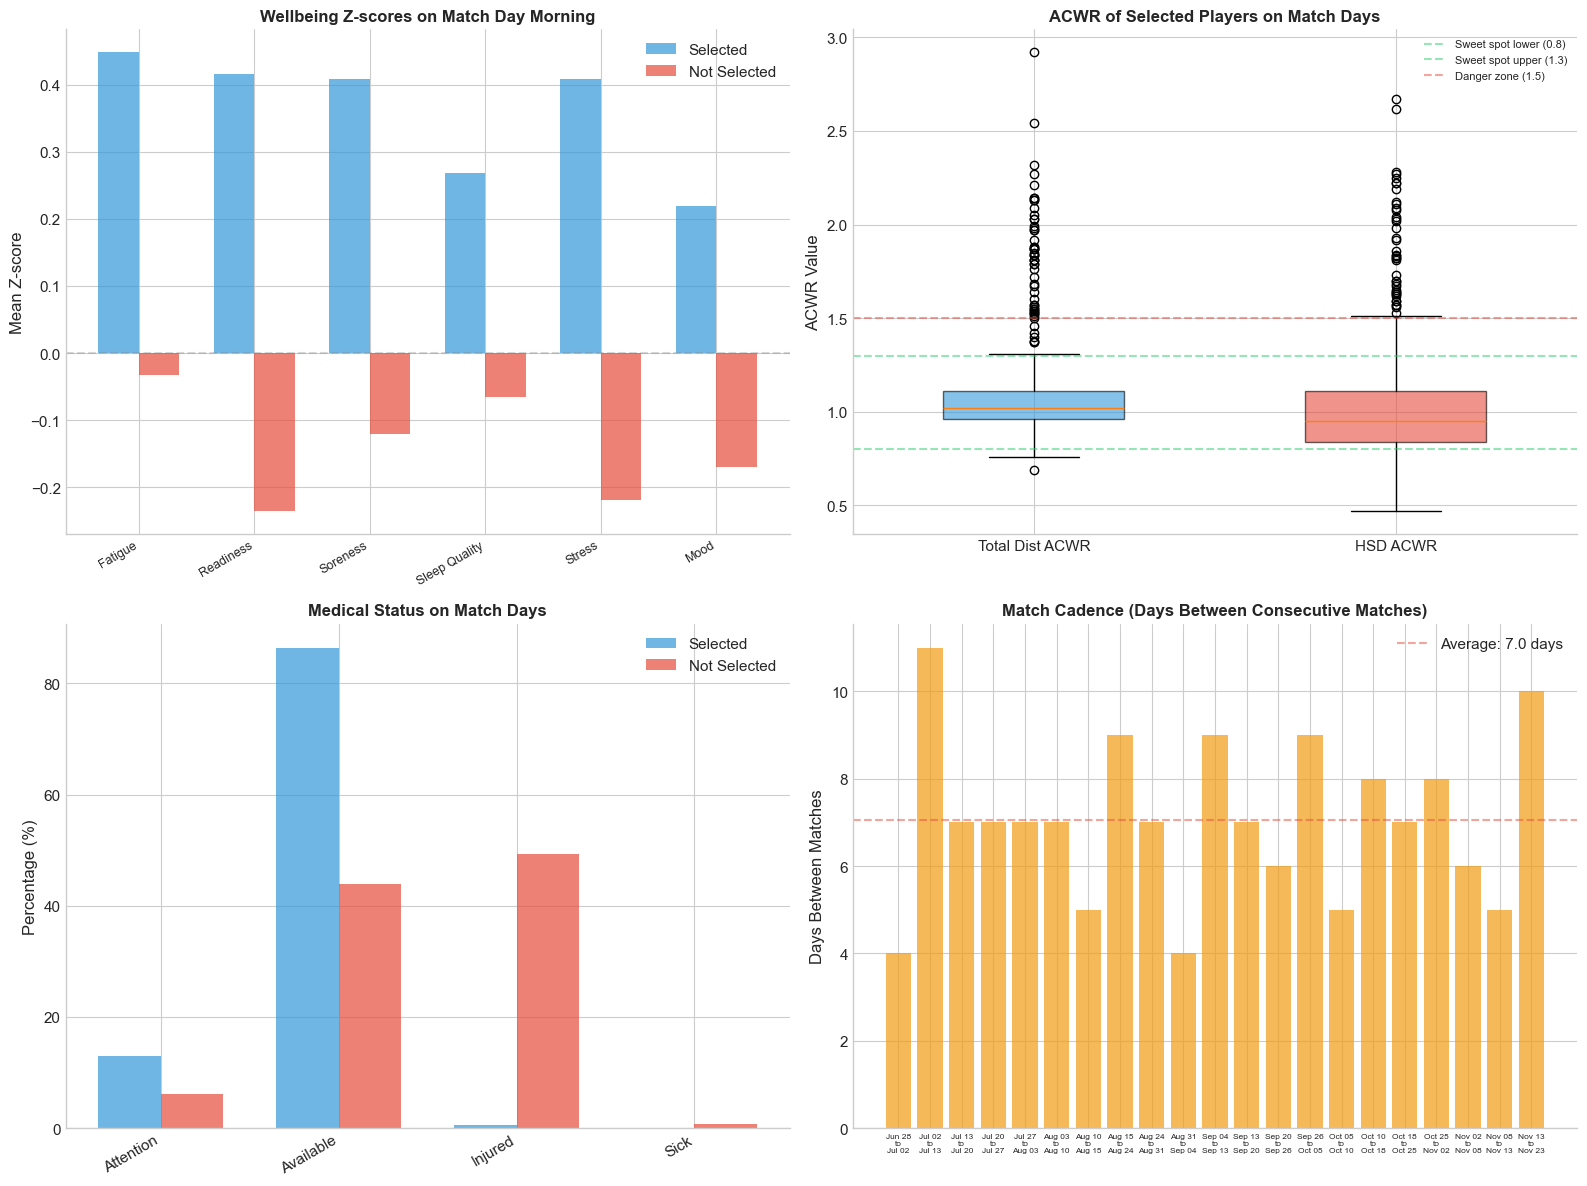

In [64]:
# Match day deep dive: wellbeing, ACWR, and status on match days
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

matchday_all = df[df['Match Day'] == 1].copy()
# Use preprocessed Selected column (1 = selected, 0 = not selected)
sel_mask = matchday_all['Selected'] == 1
notsel_mask = matchday_all['Selected'] == 0

# Top-left: Wellbeing z-scores comparison (selected vs not)
ax = axes[0, 0]
wellbeing_z = list(WELLBEING_COLORS.keys())
selected_means = matchday_all[sel_mask][wellbeing_z].mean()
nonselected_means = matchday_all[notsel_mask][wellbeing_z].mean()

x_pos = np.arange(len(wellbeing_z))
width = 0.35
ax.bar(x_pos - width/2, selected_means, width, label='Selected',
       color=SELECTION_COLORS['selected'], alpha=0.7)
ax.bar(x_pos + width/2, nonselected_means, width, label='Not Selected',
       color=SELECTION_COLORS['not_selected'], alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([w.replace(' (z)', '') for w in wellbeing_z], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean Z-score')
ax.set_title('Wellbeing Z-scores on Match Day Morning', fontsize=12, fontweight='bold')
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

# Top-right: ACWR values for selected players on match days
ax = axes[0, 1]
acwr_match_cols = ['Total Distance (ACWR) Yesterday', 'High Speed Distance (ACWR) Yesterday']
acwr_labels = ['Total Dist ACWR', 'HSD ACWR']
selected_acwr = matchday_all[sel_mask][acwr_match_cols].dropna()
bp = ax.boxplot([selected_acwr[c].values for c in acwr_match_cols], labels=acwr_labels,
                patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], [ACWR_COLORS[col] for col in acwr_match_cols]):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.axhline(y=0.8, color=COLORS['success'], linestyle='--', alpha=0.5, label='Sweet spot lower (0.8)')
ax.axhline(y=1.3, color=COLORS['success'], linestyle='--', alpha=0.5, label='Sweet spot upper (1.3)')
ax.axhline(y=1.5, color=COLORS['secondary'], linestyle='--', alpha=0.5, label='Danger zone (1.5)')
ax.set_ylabel('ACWR Value')
ax.set_title('ACWR of Selected Players on Match Days', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)

# Bottom-left: Status distribution on match days (selected vs not)
ax = axes[1, 0]
status_selected = matchday_all[sel_mask]['Status'].value_counts(normalize=True) * 100
status_nonselected = matchday_all[notsel_mask]['Status'].value_counts(normalize=True) * 100
all_statuses = sorted(set(status_selected.index) | set(status_nonselected.index))
x_pos = np.arange(len(all_statuses))
ax.bar(x_pos - width/2, [status_selected.get(s, 0) for s in all_statuses], width,
       label='Selected', color=SELECTION_COLORS['selected'], alpha=0.7)
ax.bar(x_pos + width/2, [status_nonselected.get(s, 0) for s in all_statuses], width,
       label='Not Selected', color=SELECTION_COLORS['not_selected'], alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(all_statuses, rotation=30, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Medical Status on Match Days', fontsize=12, fontweight='bold')
ax.legend()

# Bottom-right: Match day cadence - days between consecutive matches
ax = axes[1, 1]
match_gaps = [(match_dates[i+1] - match_dates[i]).days for i in range(len(match_dates)-1)]
ax.bar(range(len(match_gaps)), match_gaps, color=COLORS['warning'], alpha=0.7)
ax.set_xticks(range(len(match_gaps)))
ax.set_xticklabels([f'{match_dates[i].strftime("%b %d")}\nto\n{match_dates[i+1].strftime("%b %d")}'
                     for i in range(len(match_gaps))], fontsize=6, rotation=0)
ax.set_ylabel('Days Between Matches')
ax.set_title('Match Cadence (Days Between Consecutive Matches)', fontsize=12, fontweight='bold')
ax.axhline(y=np.mean(match_gaps), color=COLORS['secondary'], linestyle='--', alpha=0.5,
           label=f'Average: {np.mean(match_gaps):.1f} days')
ax.legend()

plt.tight_layout()
plt.show()

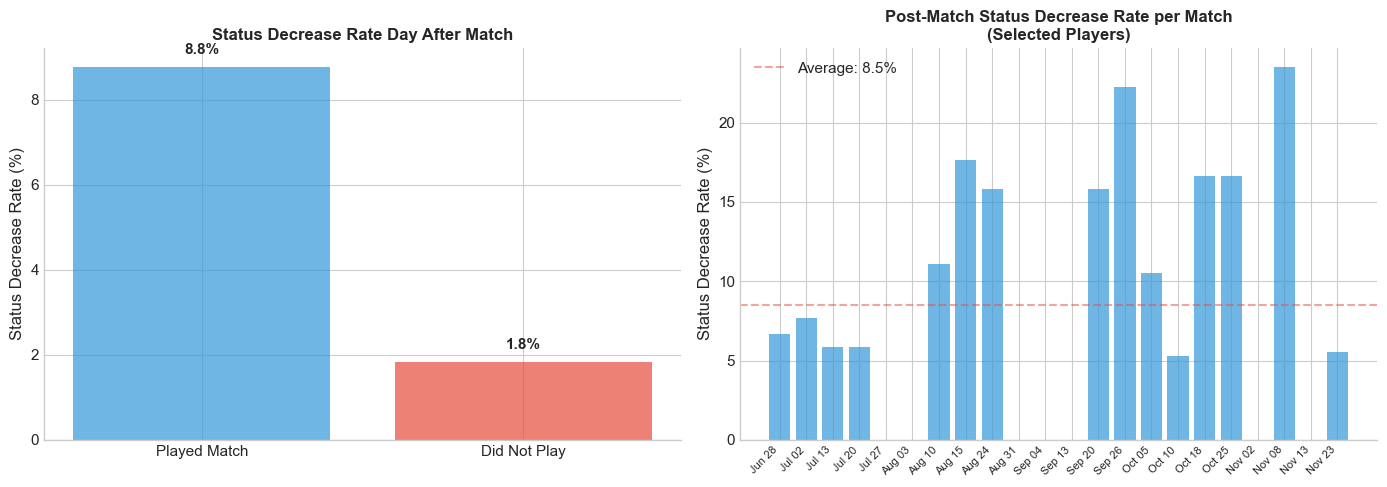


Post-match impact summary:
  Status decrease rate after playing match: 8.8%
  Status decrease rate after NOT playing: 1.8%
  Observations: 376 played, 218 did not play


In [65]:
# Post-match impact: Status Decrease rate the day AFTER a match
# For each match day, check how many players had a status decrease the next day

post_match_impact = []
for d in match_dates:
    next_day = d + pd.Timedelta(days=1)
    next_day_data = df[df['Date'] == next_day]
    if len(next_day_data) == 0:
        continue

    # Players who were selected for the match (using Selected column)
    selected_players = df[(df['Date'] == d) & (df['Selected'] == 1)]['Player ID'].unique()

    # Status decrease for selected vs non-selected players the next day
    for _, row in next_day_data.iterrows():
        played = row['Player ID'] in selected_players
        post_match_impact.append({
            'Date': d,
            'Player ID': row['Player ID'],
            'Played Match': played,
            'Status Decrease Next Day': row['Status Decrease'] if pd.notna(row['Status Decrease']) else 0
        })

post_match_df = pd.DataFrame(post_match_impact)

if len(post_match_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Status decrease rate day after match: played vs did not play
    ax = axes[0]
    played_rate = post_match_df[post_match_df['Played Match']]['Status Decrease Next Day'].mean() * 100
    notplayed_rate = post_match_df[~post_match_df['Played Match']]['Status Decrease Next Day'].mean() * 100
    bars = ax.bar(['Played Match', 'Did Not Play'], [played_rate, notplayed_rate],
                  color=[SELECTION_COLORS['selected'], SELECTION_COLORS['not_selected']], alpha=0.7)
    ax.set_ylabel('Status Decrease Rate (%)')
    ax.set_title('Status Decrease Rate Day After Match', fontsize=12, fontweight='bold')
    for bar, rate in zip(bars, [played_rate, notplayed_rate]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{rate:.1f}%',
                ha='center', fontsize=11, fontweight='bold')

    # Right: Per-match post-match status decrease rate for selected players
    ax = axes[1]
    per_match_rates = post_match_df[post_match_df['Played Match']].groupby('Date')['Status Decrease Next Day'].mean() * 100
    ax.bar(range(len(per_match_rates)), per_match_rates.values,
           color=SELECTION_COLORS['selected'], alpha=0.7)
    ax.set_xticks(range(len(per_match_rates)))
    ax.set_xticklabels([d.strftime('%b %d') for d in per_match_rates.index], rotation=45, fontsize=8, ha='right')
    ax.set_ylabel('Status Decrease Rate (%)')
    ax.set_title('Post-Match Status Decrease Rate per Match\n(Selected Players)', fontsize=12, fontweight='bold')
    ax.axhline(y=per_match_rates.mean(), color=COLORS['secondary'], linestyle='--', alpha=0.5,
               label=f'Average: {per_match_rates.mean():.1f}%')
    ax.legend()

    plt.tight_layout()
    plt.show()

    print(f"\nPost-match impact summary:")
    print(f"  Status decrease rate after playing match: {played_rate:.1f}%")
    print(f"  Status decrease rate after NOT playing: {notplayed_rate:.1f}%")
    n_played = post_match_df['Played Match'].sum()
    n_not = len(post_match_df) - n_played
    print(f"  Observations: {int(n_played)} played, {int(n_not)} did not play")

---

## 18. Treatment-Confounder Feedback

A core challenge for causal inference in this dataset: **yesterday's training affects today's fatigue,
and today's fatigue affects today's training assignment**. This creates a feedback loop between
treatment (training load) and confounders (player state), making naive observational estimates biased.

These plots visualize both directions of this feedback loop.

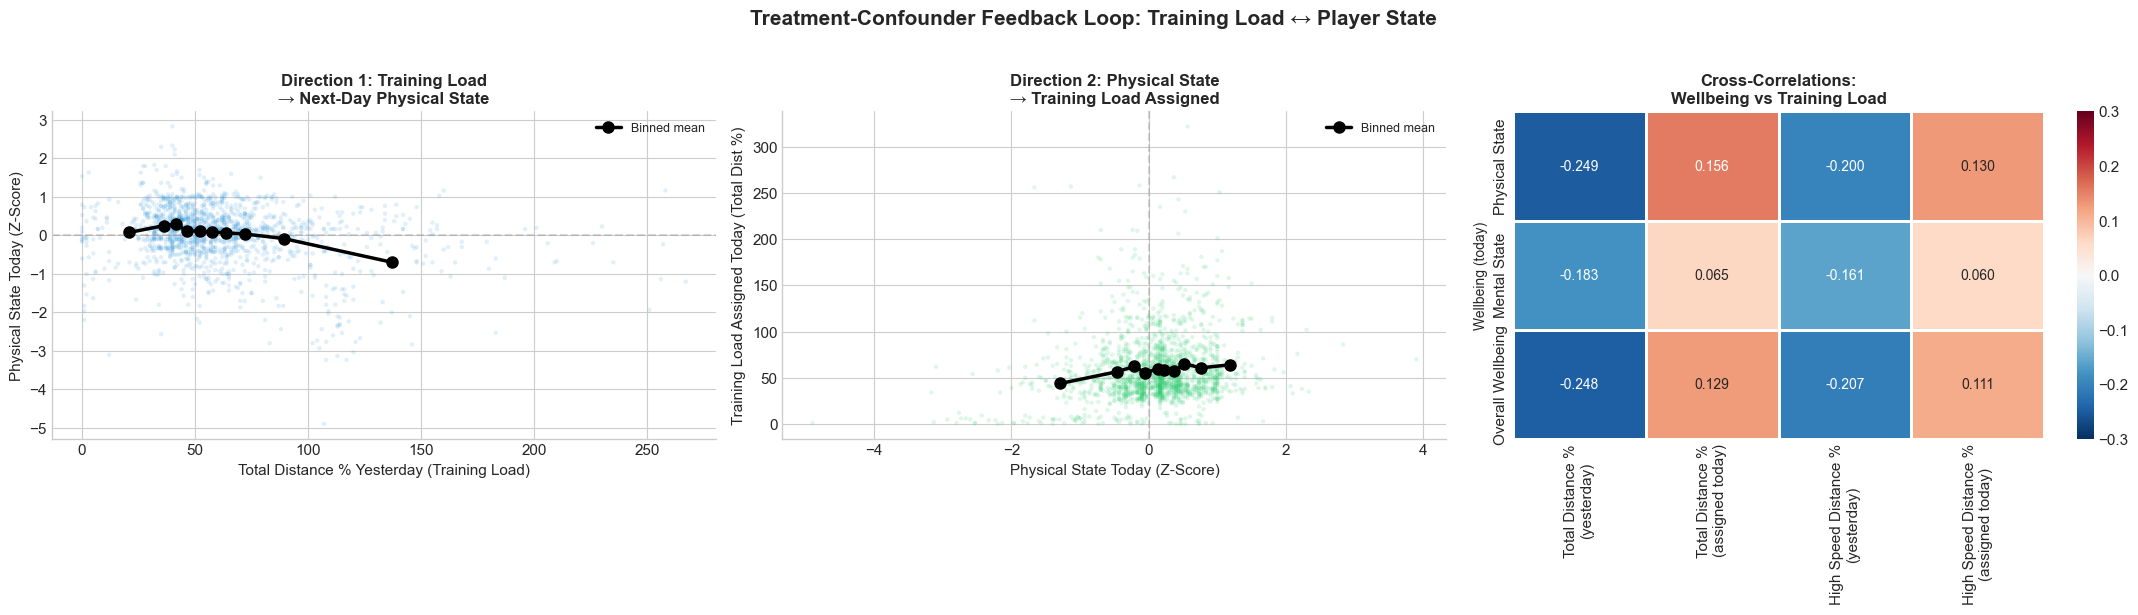


Interpretation:
  Left:   Higher yesterday's load → lower physical state (training causes fatigue)
  Middle: Higher physical state → higher load assigned (coaches give harder training to fresher players)
  Right:  Cross-correlations confirm both directions of the feedback loop
  This bidirectional relationship is why naive prediction models are biased — causal methods are needed.


In [66]:
# Treatment-Confounder Feedback Loop Visualization
# Direction 1: Yesterday's load -> Today's state (treatment -> confounder)
# Direction 2: Today's state -> Today's assigned load (confounder -> treatment)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Left: Yesterday's training load -> Today's physical state ---
ax = axes[0]
x_data = df['Total Distance % Yesterday'].dropna()
y_data = df.loc[x_data.index, 'Physical State'].dropna()
common_idx = x_data.index.intersection(y_data.index)

ax.scatter(x_data[common_idx], y_data[common_idx],
           c=GPS_COLORS['Total Distance % Yesterday'], alpha=0.15, s=10, edgecolors='none')

# Add binned means to show trend
bins = pd.qcut(x_data[common_idx], q=10, duplicates='drop')
binned = pd.DataFrame({'x': x_data[common_idx], 'y': y_data[common_idx], 'bin': bins})
bin_means = binned.groupby('bin', observed=True).agg({'x': 'mean', 'y': 'mean'}).sort_values('x')
ax.plot(bin_means['x'], bin_means['y'], 'ko-', linewidth=2.5, markersize=8, zorder=5, label='Binned mean')

ax.set_xlabel('Total Distance % Yesterday (Training Load)', fontsize=11)
ax.set_ylabel('Physical State Today (Z-Score)', fontsize=11)
ax.set_title('Direction 1: Training Load\n→ Next-Day Physical State', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.legend(fontsize=9)

# --- Middle: Today's physical state -> Today's assigned training load ---
ax = axes[1]
# Get today's assigned load from next row's "Yesterday" data (within player)
df_fb = df.sort_values(['Player ID', 'Date']).copy()
df_fb['Load_Assigned_Today'] = df_fb.groupby('Player ID')['Total Distance % Yesterday'].shift(-1)

x_state = df_fb['Physical State'].dropna()
y_load = df_fb.loc[x_state.index, 'Load_Assigned_Today'].dropna()
common_fb = x_state.index.intersection(y_load.index)

ax.scatter(x_state[common_fb], y_load[common_fb],
           c=COMPOSITE_COLORS['Physical State'], alpha=0.15, s=10, edgecolors='none')

# Binned means
bins2 = pd.qcut(x_state[common_fb], q=10, duplicates='drop')
binned2 = pd.DataFrame({'x': x_state[common_fb], 'y': y_load[common_fb], 'bin': bins2})
bin_means2 = binned2.groupby('bin', observed=True).agg({'x': 'mean', 'y': 'mean'}).sort_values('x')
ax.plot(bin_means2['x'], bin_means2['y'], 'ko-', linewidth=2.5, markersize=8, zorder=5, label='Binned mean')

ax.set_xlabel('Physical State Today (Z-Score)', fontsize=11)
ax.set_ylabel('Training Load Assigned Today (Total Dist %)', fontsize=11)
ax.set_title('Direction 2: Physical State\n→ Training Load Assigned', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax.legend(fontsize=9)

# --- Right: Lagged cross-correlation heatmap ---
ax = axes[2]
# Compute correlations: wellbeing at t vs GPS at t and t+1
wellbeing_vars = ['Physical State', 'Mental State', 'Overall Wellbeing']
gps_vars = ['Total Distance % Yesterday', 'High Speed Distance % Yesterday']

# Create shifted GPS (what load was assigned today = next row's Yesterday)
df_corr = df.sort_values(['Player ID', 'Date']).copy()
for gps_var in gps_vars:
    df_corr[f'{gps_var} (assigned today)'] = df_corr.groupby('Player ID')[gps_var].shift(-1)

# Build correlation matrix
corr_data = {}
for wb in wellbeing_vars:
    row = {}
    for gps in gps_vars:
        # Yesterday's load vs today's state
        short_gps = gps.replace(' % Yesterday', ' %').replace(' Yesterday', '')
        row[f'{short_gps}\n(yesterday)'] = df_corr[[wb, gps]].dropna().corr().iloc[0, 1]
        # Today's state vs today's assigned load
        assigned_col = f'{gps} (assigned today)'
        row[f'{short_gps}\n(assigned today)'] = df_corr[[wb, assigned_col]].dropna().corr().iloc[0, 1]
    corr_data[wb] = row

corr_df = pd.DataFrame(corr_data).T
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=1, linecolor='white', ax=ax, vmin=-0.3, vmax=0.3,
            annot_kws={'fontsize': 10})
ax.set_title('Cross-Correlations:\nWellbeing vs Training Load', fontsize=12, fontweight='bold')
ax.set_ylabel('Wellbeing (today)', fontsize=10)
ax.set_xlabel('')

plt.suptitle('Treatment-Confounder Feedback Loop: Training Load ↔ Player State',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Left:   Higher yesterday's load → lower physical state (training causes fatigue)")
print("  Middle: Higher physical state → higher load assigned (coaches give harder training to fresher players)")
print("  Right:  Cross-correlations confirm both directions of the feedback loop")
print("  This bidirectional relationship is why naive prediction models are biased — causal methods are needed.")

---

## 19. Sequential Treatment Patterns

Training is not a single exposure — it is a **sequence of 5-6 daily sessions** leading to match day.
The cumulative effect of this sequence determines match-day readiness. These plots show the typical
training prescription patterns across the microcycle and how coaches sequence different activity types.

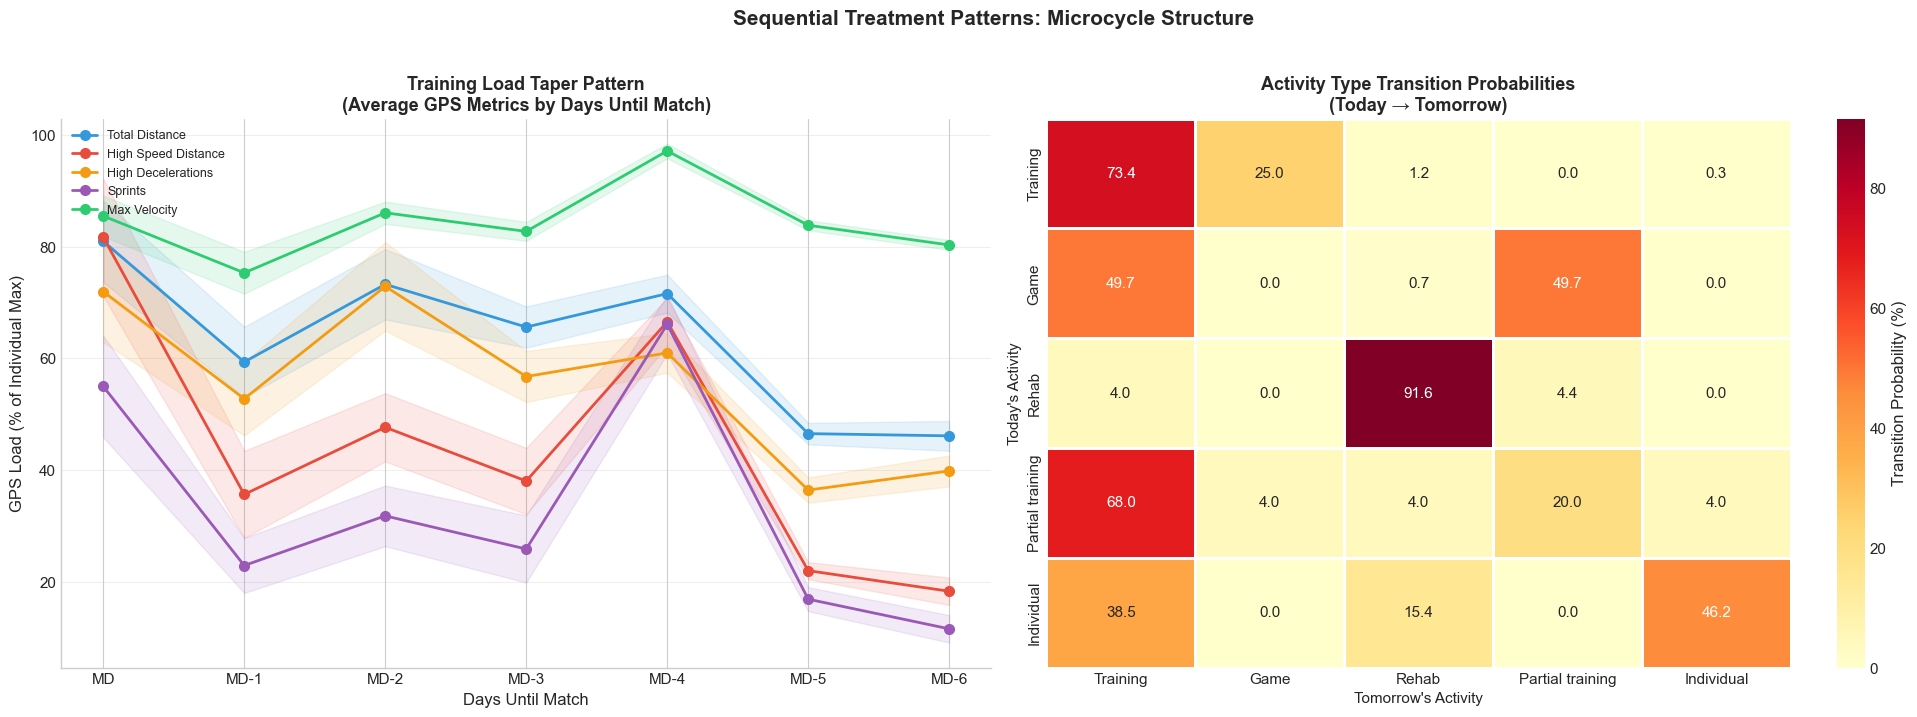


Key observations:
  Transition matrix shows coaching patterns (e.g., what follows a Game day)
  Taper pattern shows load reduction approaching match day
  These sequential patterns are why single-day treatment models may be insufficient


In [67]:
# Sequential Treatment Patterns: microcycle prescription and activity transitions

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Left: GPS load taper pattern approaching match day ---
ax = axes[0]
# Filter to typical match week (Days Until Match 0-6)
df_week = df[df['Days Until Match'].between(0, 6)].copy()

gps_metrics = list(GPS_COLORS.keys())
for gps_col in gps_metrics:
    grouped = df_week.groupby('Days Until Match')[gps_col]
    means = grouped.mean()
    sems = grouped.sem()
    short_name = gps_col.replace(' % Yesterday', '').replace(' Yesterday', '')
    color = GPS_COLORS[gps_col]

    ax.plot(means.index, means.values, 'o-', color=color, linewidth=2, markersize=7, label=short_name)
    ax.fill_between(means.index, (means - 1.96 * sems).values, (means + 1.96 * sems).values,
                    color=color, alpha=0.12)

ax.set_xlabel('Days Until Match', fontsize=12)
ax.set_ylabel('GPS Load (% of Individual Max)', fontsize=12)
ax.set_title('Training Load Taper Pattern\n(Average GPS Metrics by Days Until Match)', fontsize=13, fontweight='bold')
ax.invert_xaxis()  # Match day (0) on the right
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(7))
ax.set_xticklabels([f'MD-{i}' if i > 0 else 'MD' for i in range(6, -1, -1)])

# --- Right: Activity Type transition matrix ---
ax = axes[1]
# For each player, look at consecutive days and count transitions
df_trans = df.sort_values(['Player ID', 'Date']).copy()
df_trans['Next Activity'] = df_trans.groupby('Player ID')['Activity Type Today'].shift(-1)

# Only keep rows where both current and next activity are known
trans_df = df_trans[['Activity Type Today', 'Next Activity']].dropna()

# Focus on main activity types
main_acts = ['Training', 'Game', 'Rehab', 'Partial training', 'Individual']
trans_filtered = trans_df[
    trans_df['Activity Type Today'].isin(main_acts) &
    trans_df['Next Activity'].isin(main_acts)
]

# Create transition matrix (row = today, col = tomorrow)
trans_matrix = pd.crosstab(trans_filtered['Activity Type Today'],
                           trans_filtered['Next Activity'],
                           normalize='index') * 100

# Reorder to match main_acts
trans_matrix = trans_matrix.reindex(index=main_acts, columns=main_acts, fill_value=0)

sns.heatmap(trans_matrix, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Transition Probability (%)'})
ax.set_title('Activity Type Transition Probabilities\n(Today → Tomorrow)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tomorrow\'s Activity', fontsize=11)
ax.set_ylabel('Today\'s Activity', fontsize=11)

plt.suptitle('Sequential Treatment Patterns: Microcycle Structure',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"  Transition matrix shows coaching patterns (e.g., what follows a Game day)")
print(f"  Taper pattern shows load reduction approaching match day")
print(f"  These sequential patterns are why single-day treatment models may be insufficient")

---

## 20. Informative Censoring & Missingness

Match performance outcomes are only observed for players who are **available and selected**.
Players who are injured, sick, or not selected are "censored" — and this censoring is
**informative** because it correlates with treatment history (players with heavy recent loads
may be more likely to be injured/unavailable). Understanding these patterns is critical
for unbiased causal estimation.

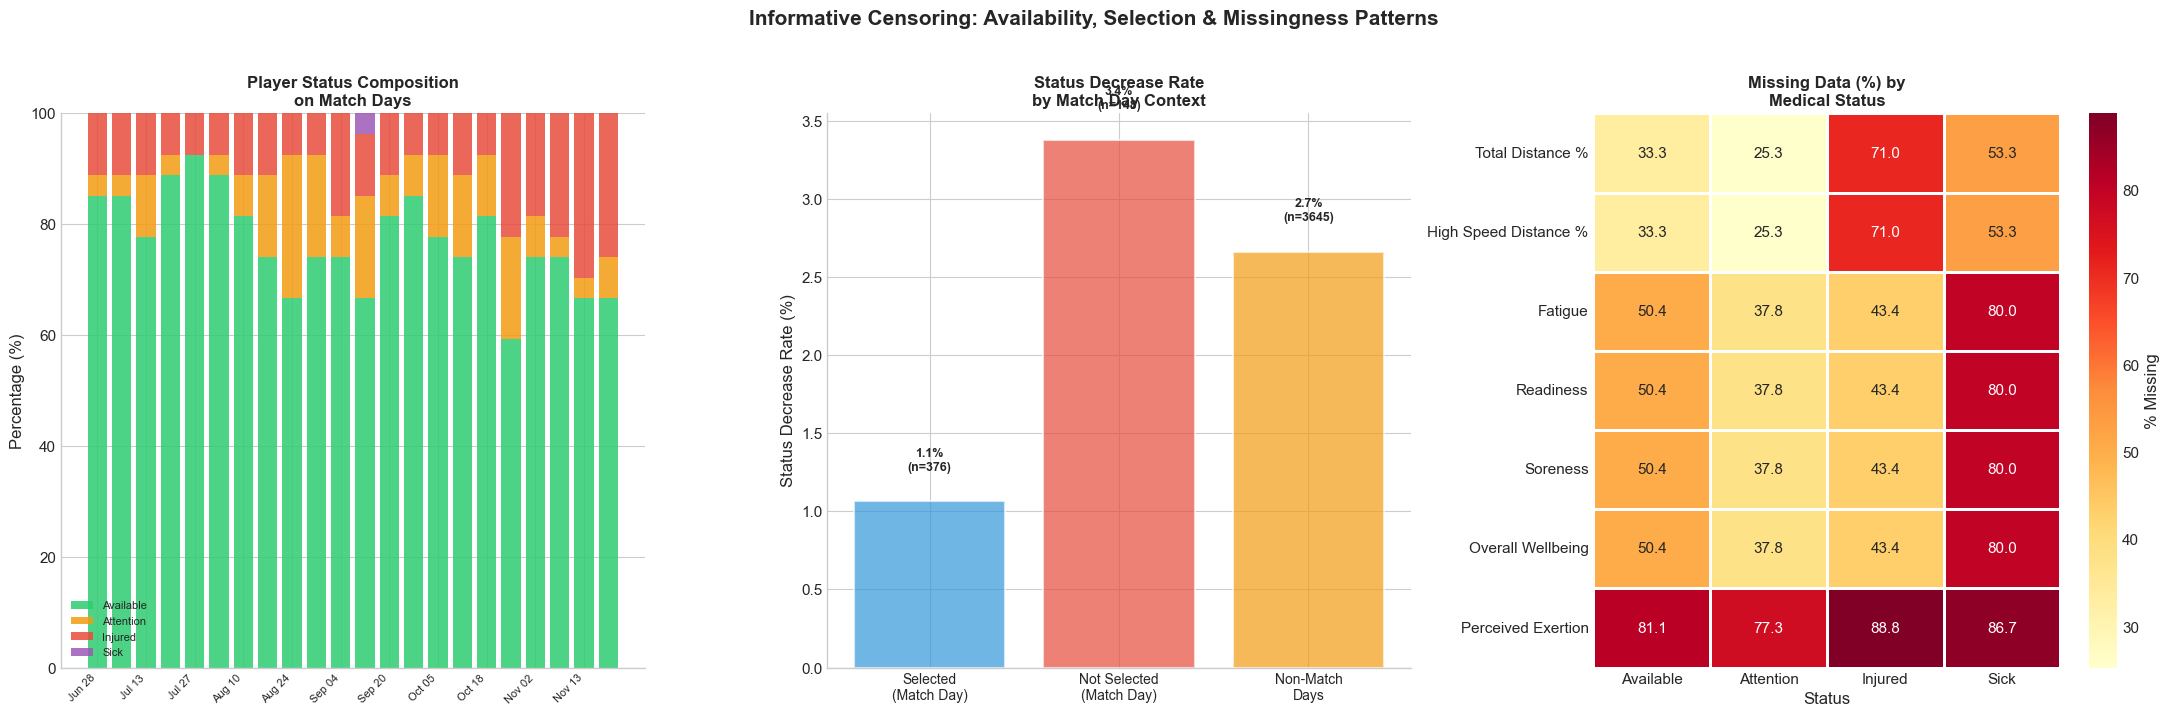


Key insights:
  Left:   Shows how player availability varies across match days (censored population)
  Middle: Status decrease rates differ by context — selection bias in who we observe
  Right:  Injured/sick players have more missing GPS data — missingness is informative
  Causal methods must account for these structural patterns to avoid biased estimates.


In [68]:
# Informative Censoring & Missingness Patterns

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- Left: Player availability composition per match day ---
ax = axes[0]
match_status_data = []
for d in match_dates:
    day_df = df[df['Date'] == d]
    status_counts = day_df['Status'].value_counts()
    for status, count in status_counts.items():
        match_status_data.append({'Date': d, 'Status': status, 'Count': count})

status_df = pd.DataFrame(match_status_data)
if len(status_df) > 0:
    status_pivot = status_df.pivot_table(index='Date', columns='Status', values='Count', fill_value=0)
    status_pivot = status_pivot.reindex(match_dates, fill_value=0)

    # Normalize to percentages
    status_pct = status_pivot.div(status_pivot.sum(axis=1), axis=0) * 100

    # Plot stacked bars with STATUS_COLORS
    bottom = np.zeros(len(match_dates))
    status_order = ['Available', 'Attention', 'Injured', 'Sick', 'Absent']
    for status in status_order:
        if status in status_pct.columns:
            vals = status_pct[status].values
            color = STATUS_COLORS.get(status, '#95a5a6')
            ax.bar(range(len(match_dates)), vals, bottom=bottom,
                   label=status, color=color, alpha=0.85)
            bottom += vals

    ax.set_xticks(range(0, len(match_dates), max(1, len(match_dates)//10)))
    ax.set_xticklabels([match_dates[i].strftime('%b %d')
                        for i in range(0, len(match_dates), max(1, len(match_dates)//10))],
                       rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Player Status Composition\non Match Days', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')
    ax.set_ylim(0, 100)

# --- Middle: Status Decrease rate by selection status on match days ---
ax = axes[1]
matchday_data = df[df['Match Day'] == 1].copy()

# Compare selected, not-selected, and non-match days
groups = {
    'Selected\n(Match Day)': matchday_data[matchday_data['Selected'] == 1]['Status Decrease'],
    'Not Selected\n(Match Day)': matchday_data[matchday_data['Selected'] == 0]['Status Decrease'],
    'Non-Match\nDays': df[df['Match Day'] == 0]['Status Decrease'],
}

rates = []
labels = []
counts = []
for label, series in groups.items():
    vals = series.dropna()
    rates.append(vals.mean() * 100)
    labels.append(label)
    counts.append(len(vals))

bar_colors = [SELECTION_COLORS['selected'], SELECTION_COLORS['not_selected'], COLORS['warning']]
bars = ax.bar(range(len(labels)), rates, color=bar_colors, alpha=0.7, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Status Decrease Rate (%)')
ax.set_title('Status Decrease Rate\nby Match Day Context', fontsize=12, fontweight='bold')

for bar, rate, n in zip(bars, rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{rate:.1f}%\n(n={n})', ha='center', fontsize=9, fontweight='bold')

# --- Right: Missing data pattern by status ---
ax = axes[2]
key_vars = ['Total Distance % Yesterday', 'High Speed Distance % Yesterday',
            'Fatigue (z)', 'Readiness (z)', 'Soreness (z)',
            'Overall Wellbeing', 'Perceived Exertion Yesterday']

# Calculate % missing by status
missing_by_status = {}
for status in ['Available', 'Attention', 'Injured', 'Sick']:
    status_df_sub = df[df['Status'] == status]
    if len(status_df_sub) > 10:
        missing_pct = status_df_sub[key_vars].isnull().mean() * 100
        missing_by_status[status] = missing_pct

if missing_by_status:
    missing_df = pd.DataFrame(missing_by_status)
    # Shorten variable names for display
    short_names = [v.replace(' % Yesterday', ' %').replace(' Yesterday', '')
                   .replace(' (z)', '') for v in key_vars]
    missing_df.index = short_names

    sns.heatmap(missing_df, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=1, linecolor='white', ax=ax,
                cbar_kws={'label': '% Missing'})
    ax.set_title('Missing Data (%) by\nMedical Status', fontsize=12, fontweight='bold')
    ax.set_xlabel('Status')
    ax.set_ylabel('')

plt.suptitle('Informative Censoring: Availability, Selection & Missingness Patterns',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nKey insights:")
print("  Left:   Shows how player availability varies across match days (censored population)")
print("  Middle: Status decrease rates differ by context — selection bias in who we observe")
print("  Right:  Injured/sick players have more missing GPS data — missingness is informative")
print("  Causal methods must account for these structural patterns to avoid biased estimates.")

---

## 21. Individual Treatment Response Heterogeneity

Players respond differently to the same training loads. Some are more resilient, others more
sensitive. These individual differences are the foundation for **personalized training prescriptions**
— the core goal of the Causal ML approach. Below we visualize between-player variability in
dose-response relationships.

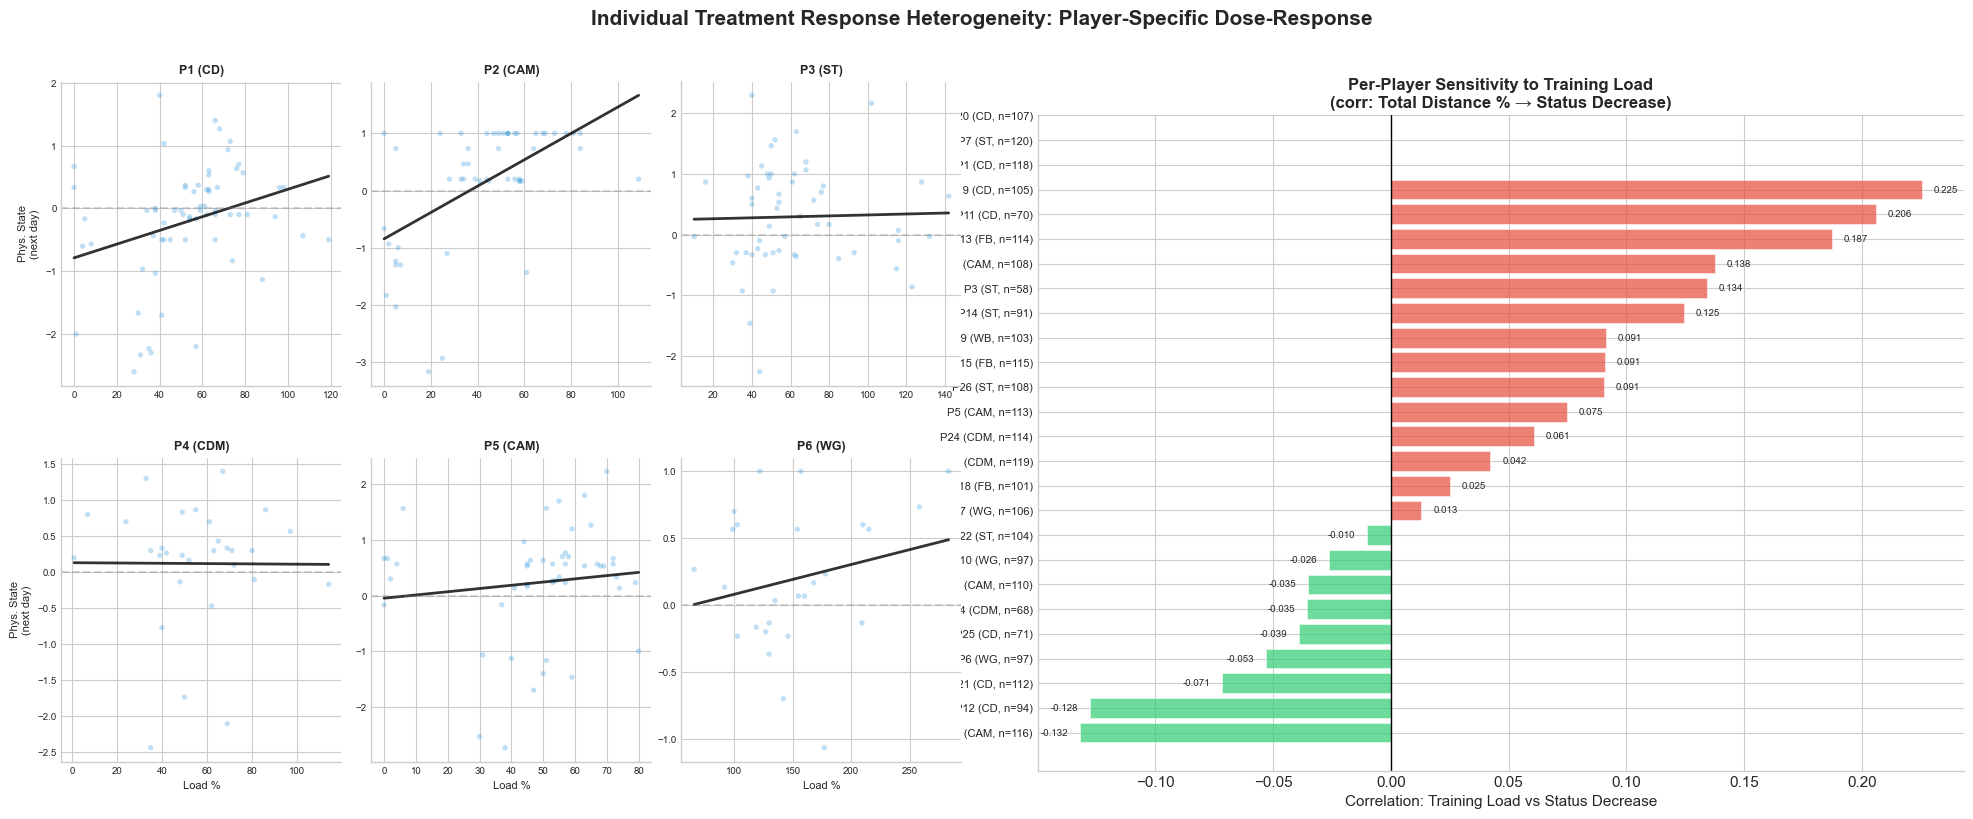


Interpretation:
  Left:  Each subplot shows one player's load-response curve (slope = sensitivity)
         Different slopes indicate heterogeneous treatment effects across players
  Right: Per-player correlations between training load and status decrease
         Positive = higher load associated with more status decreases (sensitive)
         Negative = higher load associated with fewer decreases (resilient/fit)
  This heterogeneity justifies the need for individualized treatment effect estimation.


In [69]:
# Individual Treatment Response Heterogeneity

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Left: Small multiples of dose-response curves for top players ---
# Select the 6 players with most observations
player_obs = df.groupby('Player ID').size().sort_values(ascending=False)
top_players = player_obs.head(6).index.tolist()

# Create dose-response: Total Distance % Yesterday vs next-day Physical State
df_dose = df.sort_values(['Player ID', 'Date']).copy()
df_dose['Physical State Next Day'] = df_dose.groupby('Player ID')['Physical State'].shift(-1)

# Create inset axes for small multiples (2x3 grid within left panel)
ax_left = axes[0]
ax_left.set_visible(False)  # Hide the main axis

inset_axes = []
for idx, player_id in enumerate(top_players):
    row = idx // 3
    col = idx % 3
    # Position within the left half of the figure
    left = 0.04 + col * 0.155
    bottom = 0.55 - row * 0.45 if row == 0 else 0.08
    width = 0.14
    height = 0.38
    ax_inset = fig.add_axes([left, bottom, width, height])
    inset_axes.append(ax_inset)

    player_data = df_dose[df_dose['Player ID'] == player_id].dropna(
        subset=['Total Distance % Yesterday', 'Physical State Next Day'])

    if len(player_data) > 10:
        ax_inset.scatter(player_data['Total Distance % Yesterday'],
                        player_data['Physical State Next Day'],
                        c=GPS_COLORS['Total Distance % Yesterday'], alpha=0.3, s=15, edgecolors='none')

        # Add trend line (polynomial fit degree 1)
        try:
            z = np.polyfit(player_data['Total Distance % Yesterday'],
                          player_data['Physical State Next Day'], 1)
            p = np.poly1d(z)
            x_range = np.linspace(player_data['Total Distance % Yesterday'].min(),
                                 player_data['Total Distance % Yesterday'].max(), 50)
            ax_inset.plot(x_range, p(x_range), 'k-', linewidth=2, alpha=0.8)
        except:
            pass

    pos = df[df['Player ID'] == player_id]['Position'].iloc[0] if len(df[df['Player ID'] == player_id]) > 0 else '?'
    ax_inset.set_title(f'P{int(player_id)} ({pos})', fontsize=9, fontweight='bold')
    ax_inset.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax_inset.tick_params(labelsize=7)

    if row == 1:
        ax_inset.set_xlabel('Load %', fontsize=8)
    if col == 0:
        ax_inset.set_ylabel('Phys. State\n(next day)', fontsize=8)

# --- Right: Per-player correlation heatmap ---
ax = axes[1]
# Calculate per-player correlation between training load and status decrease
player_corr = []
for player_id in sorted(df['Player ID'].unique()):
    pdata = df[df['Player ID'] == player_id][['Total Distance % Yesterday', 'Status Decrease']].dropna()
    if len(pdata) > 20:
        corr = pdata.corr().iloc[0, 1]
        pos = df[df['Player ID'] == player_id]['Position'].iloc[0]
        player_corr.append({
            'Player ID': int(player_id),
            'Position': pos,
            'Correlation': corr,
            'N': len(pdata)
        })

corr_df = pd.DataFrame(player_corr).sort_values('Correlation', ascending=True)

# Horizontal bar chart with diverging colors
colors_bar = [COLORS['secondary'] if c > 0 else COLORS['success'] for c in corr_df['Correlation']]
bars = ax.barh(range(len(corr_df)),
               corr_df['Correlation'],
               color=colors_bar, alpha=0.7, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels([f"P{row['Player ID']} ({row['Position']}, n={row['N']})"
                     for _, row in corr_df.iterrows()], fontsize=8)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Correlation: Training Load vs Status Decrease', fontsize=11)
ax.set_title('Per-Player Sensitivity to Training Load\n(corr: Total Distance % → Status Decrease)',
             fontsize=12, fontweight='bold')

# Add value labels
for bar, val in zip(bars, corr_df['Correlation']):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', ha=ha, fontsize=7)

plt.suptitle('Individual Treatment Response Heterogeneity: Player-Specific Dose-Response',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Left:  Each subplot shows one player's load-response curve (slope = sensitivity)")
print("         Different slopes indicate heterogeneous treatment effects across players")
print("  Right: Per-player correlations between training load and status decrease")
print("         Positive = higher load associated with more status decreases (sensitive)")
print("         Negative = higher load associated with fewer decreases (resilient/fit)")
print("  This heterogeneity justifies the need for individualized treatment effect estimation.")